# TheLook: propensión de compra dinámica por sesión

**Pregunta:** después de observar únicamente los primeros **3** eventos de una sesión, ¿habrá un evento `purchase` posterior?

- Grano: una fila por sesión elegible.
- Features: exclusivamente eventos con `event_number <= N` e historial con timestamp `< session_start_time`.
- Target: `purchase` con `event_number > N`.
- Regla solicitada: excluir sesiones con `purchase` dentro de los primeros N eventos.
- Alcance: auditoría, feature engineering y validación; **sin modelado ni preprocesamiento**.

El dataset público puede actualizarse. Las cifras y conclusiones se generan ejecutando las consultas, no están inventadas ni fijadas manualmente.

## 1. Configuración

N=3 es el experimento principal autorizado. La tabla se crea únicamente después de comprobar que el target contiene ambas clases. N=5 y N=10 permanecen como evidencia exploratoria.

In [20]:
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.cloud import bigquery
from IPython.display import Markdown, display

PROJECT_ID = "ia-2026-506700"
DATASET_NAME = "thelook_feature_engineering"
LOCATION = "US"
SOURCE_DATASET = "bigquery-public-data.thelook_ecommerce"
FEATURE_TABLE_ID = (
    f"{PROJECT_ID}.{DATASET_NAME}.session_conversion_n3_features"
)

N_EVENTS = 3
CREATE_FEATURE_TABLE = False  # Tabla ya creada; activar solo para reconstrucción explícita.

client = bigquery.Client(project=PROJECT_ID, location=LOCATION)

def query_df(sql, parameters=None):
    config = bigquery.QueryJobConfig(query_parameters=parameters or [])
    return client.query(sql, job_config=config).to_dataframe()

def estimate_gib(sql):
    config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
    job = client.query(sql, job_config=config)
    return job.total_bytes_processed / 1024**3

print(f"Proyecto de facturación: {PROJECT_ID}")
print(f"N configurado: {N_EVENTS}")
print(f"Tabla destino: {FEATURE_TABLE_ID}")
print(f"Persistencia habilitada: {CREATE_FEATURE_TABLE}")
print(f"Ejecución UTC: {datetime.now(timezone.utc):%Y-%m-%d %H:%M:%S}")

Proyecto de facturación: ia-2026-506700
N configurado: 3
Tabla destino: ia-2026-506700.thelook_feature_engineering.session_conversion_n3_features
Persistencia habilitada: False
Ejecución UTC: 2026-09-15 01:32:08


## 2. Auditoría de eventos

Primero se leen los esquemas reales. No se presupone ninguna columna.

In [21]:
schema_sql = f"""
SELECT table_name, ordinal_position, column_name, data_type, is_nullable
FROM `{SOURCE_DATASET}.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name IN ('events', 'users', 'orders', 'order_items', 'products')
ORDER BY table_name, ordinal_position
"""
schema_df = query_df(schema_sql)
display(schema_df)

,table_name,ordinal_position,column_name,data_type,is_nullable
0,events,1,id,INT64,YES
1,events,2,user_id,INT64,YES
2,events,3,sequence_number,INT64,YES
3,events,4,session_id,STRING,YES
4,events,5,created_at,TIMESTAMP,YES
5,events,6,ip_address,STRING,YES
6,events,7,city,STRING,YES
7,events,8,state,STRING,YES
8,events,9,postal_code,STRING,YES
9,events,10,browser,STRING,YES


In [22]:
event_distribution_sql = f"""
SELECT
  event_type,
  COUNT(*) AS total_events,
  ROUND(100 * SAFE_DIVIDE(COUNT(*), SUM(COUNT(*)) OVER()), 4) AS percentage,
  COUNT(DISTINCT session_id) AS unique_sessions
FROM `{SOURCE_DATASET}.events`
GROUP BY event_type
ORDER BY total_events DESC
"""
event_distribution = query_df(event_distribution_sql)
display(event_distribution)

observed_types = set(event_distribution['event_type'].dropna())
for expected in ['product', 'cart', 'purchase']:
    print(f"Existe '{expected}': {expected in observed_types}")
print("Tipos reales:", sorted(observed_types))
print("No existe un evento literal 'search' ni 'page_view'; no se inventarán.")

,event_type,total_events,percentage,unique_sessions
0,product,844021,34.7814,681703
1,cart,594235,24.4879,431917
2,department,593676,24.4649,431358
3,purchase,181703,7.4878,181703
4,cancel,125077,5.1543,125077
5,home,87935,3.6237,87935


Existe 'product': True
Existe 'cart': True
Existe 'purchase': True
Tipos reales: ['cancel', 'cart', 'department', 'home', 'product', 'purchase']
No existe un evento literal 'search' ni 'page_view'; no se inventarán.


In [23]:
events_quality_sql = f"""
SELECT
  COUNT(*) AS total_events,
  COUNTIF(session_id IS NULL) AS null_session_id,
  COUNTIF(user_id IS NULL) AS null_user_id,
  COUNTIF(created_at IS NULL) AS null_created_at,
  COUNTIF(sequence_number IS NULL) AS null_sequence_number,
  COUNTIF(id IS NULL) AS null_id,
  COUNT(*) - COUNT(DISTINCT id) AS duplicate_ids,
  COUNT(*) - COUNT(DISTINCT TO_JSON_STRING(STRUCT(
    user_id, sequence_number, session_id, created_at, ip_address, city, state,
    postal_code, browser, traffic_source, uri, event_type
  ))) AS semantic_duplicates_excluding_id,
  MIN(created_at) AS min_created_at,
  MAX(created_at) AS max_created_at,
  COUNTIF(created_at > CURRENT_TIMESTAMP()) AS events_after_query_time
FROM `{SOURCE_DATASET}.events`
"""
events_quality = query_df(events_quality_sql)
display(events_quality)

,total_events,null_session_id,null_user_id,null_created_at,null_sequence_number,null_id,duplicate_ids,semantic_duplicates_excluding_id,min_created_at,max_created_at,events_after_query_time
0,2426647,0,1124946,0,0,0,0,0,2019-01-02 00:13:00+00:00,2026-09-17 23:20:30.615943+00:00,1275


In [24]:
cardinality_sql = f"""
SELECT 'traffic_source' AS feature, COUNT(DISTINCT traffic_source) AS cardinality,
       COUNTIF(traffic_source IS NULL) AS null_count FROM `{SOURCE_DATASET}.events`
UNION ALL SELECT 'browser', COUNT(DISTINCT browser), COUNTIF(browser IS NULL)
FROM `{SOURCE_DATASET}.events`
UNION ALL SELECT 'uri', COUNT(DISTINCT uri), COUNTIF(uri IS NULL)
FROM `{SOURCE_DATASET}.events`
UNION ALL SELECT 'ip_address', COUNT(DISTINCT ip_address), COUNTIF(ip_address IS NULL)
FROM `{SOURCE_DATASET}.events`
UNION ALL SELECT 'city', COUNT(DISTINCT city), COUNTIF(city IS NULL)
FROM `{SOURCE_DATASET}.events`
UNION ALL SELECT 'state', COUNT(DISTINCT state), COUNTIF(state IS NULL)
FROM `{SOURCE_DATASET}.events`
UNION ALL SELECT 'postal_code', COUNT(DISTINCT postal_code), COUNTIF(postal_code IS NULL)
FROM `{SOURCE_DATASET}.events`
ORDER BY cardinality
"""
cardinality = query_df(cardinality_sql)
display(cardinality)
print("Decisión: uri se agrega como conteo de diversidad; ip_address y postal_code se excluyen como categorías.")

,feature,cardinality,null_count
0,traffic_source,5,0
1,browser,5,0
2,state,231,0
3,city,8772,0
4,postal_code,17300,0
5,uri,35530,0
6,ip_address,681642,0


Decisión: uri se agrega como conteo de diversidad; ip_address y postal_code se excluyen como categorías.


## 3. Definición del problema y orden de eventos

El orden es `(created_at, sequence_number, id)`. `created_at` conserva la cronología; `sequence_number` y finalmente el `id` único resuelven empates de forma determinista. Se audita que `sequence_number` sea único dentro de sesión y que no contradiga la cronología.

In [25]:
ordering_audit_sql = f"""
WITH ordered_by_sequence AS (
  SELECT
    session_id, created_at, sequence_number, id,
    LAG(created_at) OVER (
      PARTITION BY session_id ORDER BY sequence_number, id
    ) AS prior_created_at,
    COUNT(*) OVER (
      PARTITION BY session_id, sequence_number
    ) AS sequence_frequency
  FROM `{SOURCE_DATASET}.events`
), timestamp_ties AS (
  SELECT
    session_id, created_at, COUNT(*) AS tie_size,
    COUNT(DISTINCT sequence_number) AS distinct_sequences,
    COUNT(DISTINCT id) AS distinct_ids
  FROM `{SOURCE_DATASET}.events`
  GROUP BY session_id, created_at
  HAVING COUNT(*) > 1
)
SELECT
  (SELECT COUNT(*) FROM timestamp_ties) AS tied_session_timestamps,
  (SELECT SUM(tie_size) FROM timestamp_ties) AS events_in_timestamp_ties,
  (SELECT COUNTIF(distinct_sequences < tie_size) FROM timestamp_ties)
    AS ties_not_resolved_by_sequence,
  (SELECT COUNTIF(distinct_ids < tie_size) FROM timestamp_ties)
    AS ties_not_resolved_by_id,
  COUNTIF(sequence_frequency > 1) AS events_with_duplicate_sequence,
  COUNTIF(prior_created_at > created_at) AS chronological_inversions_by_sequence
FROM ordered_by_sequence
"""
display(query_df(ordering_audit_sql))

,tied_session_timestamps,events_in_timestamp_ties,ties_not_resolved_by_sequence,ties_not_resolved_by_id,events_with_duplicate_sequence,chronological_inversions_by_sequence
0,26272,52832,0,0,0,0


## 4. Comparación N = 3, 5, 10

Se separan tres conceptos: sesiones con longitud suficiente, exclusiones por compra temprana y sesiones finalmente elegibles. “Retención” en la tabla comparativa usa la población posterior a ambas reglas.

In [ ]:
n_comparison_sql = f"""
WITH ordered AS (
  SELECT
    session_id, event_type,
    ROW_NUMBER() OVER (
      PARTITION BY session_id ORDER BY created_at, sequence_number, id
    ) AS event_number,
    COUNT(*) OVER (PARTITION BY session_id) AS event_count
  FROM `{SOURCE_DATASET}.events`
  WHERE session_id IS NOT NULL AND created_at IS NOT NULL
), session_summary AS (
  SELECT
    session_id,
    ANY_VALUE(event_count) AS event_count,
    MIN(IF(event_type = 'purchase', event_number, NULL)) AS first_purchase_number,
    MAX(IF(event_type = 'purchase', event_number, NULL)) AS last_purchase_number
  FROM ordered
  GROUP BY session_id
), thresholds AS (
  SELECT n FROM UNNEST([3, 5, 10]) AS n
), totals AS (
  SELECT COUNT(*) AS total_sessions FROM session_summary
)
SELECT
  n,
  total_sessions,
  COUNTIF(event_count >= n) AS sessions_at_least_n,
  ROUND(100 * (1 - SAFE_DIVIDE(COUNTIF(event_count >= n), total_sessions)), 4)
    AS percentage_traffic_lost_by_length,
  COUNTIF(event_count >= n AND first_purchase_number <= n)
    AS sessions_excluded_due_to_early_purchase,
  COUNTIF(event_count >= n AND (first_purchase_number IS NULL OR first_purchase_number > n))
    AS eligible_sessions,
  COUNTIF(event_count >= n AND (first_purchase_number IS NULL OR first_purchase_number > n)
          AND last_purchase_number > n) AS positive_sessions,
  COUNTIF(event_count >= n AND (first_purchase_number IS NULL OR first_purchase_number > n)
          AND (last_purchase_number IS NULL OR last_purchase_number <= n)) AS negative_sessions,
  ROUND(100 * SAFE_DIVIDE(
    COUNTIF(event_count >= n AND (first_purchase_number IS NULL OR first_purchase_number > n)
            AND last_purchase_number > n),
    COUNTIF(event_count >= n AND (first_purchase_number IS NULL OR first_purchase_number > n))
  ), 4) AS conversion_rate,
  ROUND(100 * SAFE_DIVIDE(
    COUNTIF(event_count >= n AND (first_purchase_number IS NULL OR first_purchase_number > n)),
    total_sessions
  ), 4) AS percentage_of_total_sessions_retained
FROM session_summary CROSS JOIN thresholds CROSS JOIN totals
GROUP BY n, total_sessions
ORDER BY n
"""
n_comparison = query_df(n_comparison_sql)
display(n_comparison)

,purchase_event_number,purchase_sessions
0,5,87733
1,7,49980
2,10,18852
3,13,24704


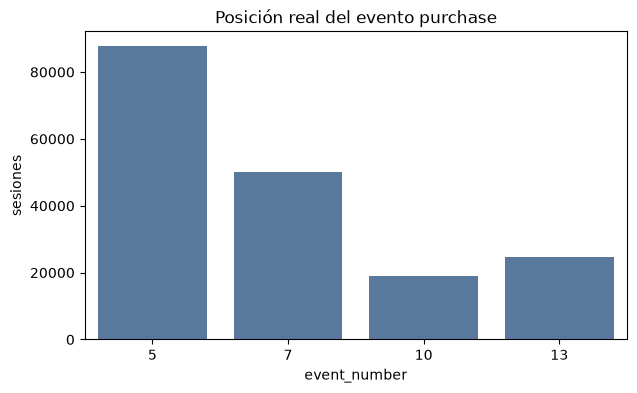

In [ ]:
purchase_position_sql = f"""
WITH ordered AS (
  SELECT
    event_type,
    ROW_NUMBER() OVER (
      PARTITION BY session_id ORDER BY created_at, sequence_number, id
    ) AS event_number
  FROM `{SOURCE_DATASET}.events`
)
SELECT event_number AS purchase_event_number, COUNT(*) AS purchase_sessions
FROM ordered
WHERE event_type = 'purchase'
GROUP BY event_number
ORDER BY event_number
"""
purchase_positions = query_df(purchase_position_sql)
display(purchase_positions)

plt.figure(figsize=(7, 4))
sns.barplot(data=purchase_positions, x='purchase_event_number', y='purchase_sessions', color='#4c78a8')
plt.title('Posición real del evento purchase')
plt.xlabel('event_number')
plt.ylabel('sesiones')
plt.show()

## 5. Construcción y validación del target

Inicialmente se evaluaron puntos de observación N=3, N=5 y N=10. Los puntos N=5 y N=10 fueron descartados porque, debido a la estructura temporal del dataset, después de excluir compras ocurridas antes o durante el momento de predicción las muestras restantes contenían exclusivamente la clase positiva. Esto impide plantear un problema de clasificación binaria válido.

N=3 conserva ambas clases y permite realizar la predicción antes de que ocurra cualquier evento `purchase`, ya que en el dataset estos comienzan a aparecer a partir de posiciones posteriores.

La regla de elegibilidad se implementa sin convertir la longitud final de la sesión en feature. El tercer evento observado basta para saber que la sesión alcanzó N=3. El futuro se consulta exclusivamente para construir `converted_after_n`.

In [ ]:
target_row = n_comparison.loc[n_comparison['n'].eq(N_EVENTS)].iloc[0]
target_summary = pd.DataFrame({
    'metric': [
        'total_sessions', 'sessions_at_least_n',
        'sessions_excluded_due_to_early_purchase', 'eligible_sessions',
        'converted_after_n', 'non_converted_after_n', 'conversion_rate',
        'positive_class_percentage', 'negative_class_percentage'
    ],
    'value': [
        target_row.total_sessions, target_row.sessions_at_least_n,
        target_row.sessions_excluded_due_to_early_purchase, target_row.eligible_sessions,
        target_row.positive_sessions, target_row.negative_sessions,
        target_row.conversion_rate,
        100 * target_row.positive_sessions / target_row.eligible_sessions,
        100 * target_row.negative_sessions / target_row.eligible_sessions,
    ]
})
display(target_summary)

target_is_viable = (
    target_row.positive_sessions > 0 and target_row.negative_sessions > 0
)
if not target_is_viable:
    display(Markdown(
        f"**BLOQUEO:** N={N_EVENTS} y la exclusión de compras tempranas producen "
        "un target de una sola clase. No se debe persistir ni modelar esta población."
    ))

,metric,value
0,total_sessions,681269.000000
1,sessions_at_least_n,430906.000000
2,sessions_excluded_due_to_early_purchase,0.000000
3,eligible_sessions,430906.000000
4,converted_after_n,181269.000000
5,non_converted_after_n,249637.000000
6,conversion_rate,42.066900
7,positive_class_percentage,42.066947
8,negative_class_percentage,57.933053


## 6. Ingeniería de características

`page_view` y `search` no existen. Se conserva `number_home_events` y `number_department_events` en vez de inventar esos tipos. Para producto, `uri` sigue exactamente `/product/{id}`; el enlace extraído debe validarse antes de utilizar precio o categoría.

In [ ]:
product_link_sql = f"""
WITH product_events AS (
  SELECT SAFE_CAST(REGEXP_EXTRACT(uri, r'^/product/([0-9]+)$') AS INT64) AS product_id
  FROM `{SOURCE_DATASET}.events`
  WHERE event_type = 'product'
)
SELECT
  COUNT(*) AS product_events,
  COUNTIF(product_id IS NOT NULL) AS parseable_product_events,
  COUNTIF(p.id IS NOT NULL) AS matched_product_events,
  COUNT(DISTINCT product_id) AS unique_product_ids
FROM product_events pe
LEFT JOIN `{SOURCE_DATASET}.products` p ON pe.product_id = p.id
"""
product_link_audit = query_df(product_link_sql)
display(product_link_audit)
assert product_link_audit.loc[0, 'product_events'] == product_link_audit.loc[0, 'matched_product_events']

,product_events,parseable_product_events,matched_product_events,unique_product_ids
0,843065,843065,843065,29120


In [ ]:
def build_feature_select(n_events):
    return f"""
WITH ordered_events AS (
  SELECT
    e.*,
    ROW_NUMBER() OVER (
      PARTITION BY session_id ORDER BY created_at, sequence_number, id
    ) AS event_number,
    LAG(created_at) OVER (
      PARTITION BY session_id ORDER BY created_at, sequence_number, id
    ) AS previous_event_at
  FROM `{SOURCE_DATASET}.events` e
  WHERE session_id IS NOT NULL AND created_at IS NOT NULL
),
session_labels AS (
  SELECT
    session_id,
    COUNTIF(event_number <= {n_events}) AS observed_events_count,
    COUNTIF(event_number <= {n_events} AND event_type = 'purchase') AS early_purchases,
    CAST(COUNTIF(event_number > {n_events} AND event_type = 'purchase') > 0 AS INT64)
      AS converted_after_n
  FROM ordered_events
  GROUP BY session_id
),
eligible_sessions AS (
  SELECT session_id, converted_after_n
  FROM session_labels
  WHERE observed_events_count = {n_events} AND early_purchases = 0
),
observed_events AS (
  SELECT
    o.*,
    SAFE_CAST(REGEXP_EXTRACT(
      IF(o.event_type = 'product', o.uri, NULL), r'^/product/([0-9]+)$'
    ) AS INT64) AS observed_product_id
  FROM ordered_events o
  JOIN eligible_sessions e USING (session_id)
  WHERE o.event_number <= {n_events}
),
observed_enriched AS (
  SELECT o.*, p.category, p.retail_price
  FROM observed_events o
  LEFT JOIN `{SOURCE_DATASET}.products` p ON o.observed_product_id = p.id
),
session_features AS (
  SELECT
    o.session_id,
    ARRAY_AGG(o.user_id IGNORE NULLS ORDER BY event_number DESC LIMIT 1)[SAFE_OFFSET(0)]
      AS user_id,
    MIN(o.created_at) AS session_start_time,
    MAX(IF(o.event_number = {n_events}, o.created_at, NULL)) AS prediction_time,
    ANY_VALUE(e.converted_after_n) AS converted_after_n,
    TIMESTAMP_DIFF(MAX(o.created_at), MIN(o.created_at), SECOND) AS seconds_first_to_n_event,
    SAFE_DIVIDE(TIMESTAMP_DIFF(MAX(o.created_at), MIN(o.created_at), SECOND), {n_events} - 1)
      AS avg_seconds_between_events,
    MAX(TIMESTAMP_DIFF(o.created_at, o.previous_event_at, SECOND)) AS max_seconds_between_events,
    EXTRACT(HOUR FROM MAX(IF(o.event_number = {n_events}, o.created_at, NULL))) AS hour_of_day,
    EXTRACT(DAYOFWEEK FROM MAX(IF(o.event_number = {n_events}, o.created_at, NULL))) AS day_of_week,
    CAST(EXTRACT(DAYOFWEEK FROM MAX(IF(o.event_number = {n_events}, o.created_at, NULL)))
         IN (1, 7) AS INT64) AS weekend_flag,
    COUNT(*) AS number_events_observed,
    COUNTIF(o.event_type = 'home') AS number_home_events,
    COUNTIF(o.event_type = 'department') AS number_department_events,
    COUNTIF(o.event_type = 'product') AS number_product_events,
    COUNTIF(o.event_type = 'cart') AS number_cart_events,
    COUNTIF(o.event_type = 'cancel') AS number_cancel_events,
    CAST(COUNTIF(o.event_type = 'product') > 0 AS INT64) AS product_seen_before_n,
    CAST(COUNTIF(o.event_type = 'cart') > 0 AS INT64) AS cart_seen_before_n,
    SAFE_DIVIDE(COUNTIF(o.event_type = 'home'), COUNT(*)) AS home_event_ratio,
    SAFE_DIVIDE(COUNTIF(o.event_type = 'department'), COUNT(*)) AS department_event_ratio,
    SAFE_DIVIDE(COUNTIF(o.event_type = 'product'), COUNT(*)) AS product_event_ratio,
    SAFE_DIVIDE(COUNTIF(o.event_type = 'cart'), COUNT(*)) AS cart_event_ratio,
    SAFE_DIVIDE(COUNTIF(o.event_type = 'cancel'), COUNT(*)) AS cancel_event_ratio,
    COUNT(DISTINCT o.observed_product_id) AS unique_products_seen,
    COUNT(DISTINCT o.category) AS unique_categories_seen,
    COUNT(DISTINCT o.uri) AS unique_uris,
    COUNT(DISTINCT o.event_type) AS unique_event_types,
    AVG(IF(o.event_type = 'product', o.retail_price, NULL)) AS mean_product_price_seen,
    MAX(IF(o.event_type = 'product', o.retail_price, NULL)) AS max_product_price_seen,
    MIN(IF(o.event_type = 'product', o.retail_price, NULL)) AS min_product_price_seen,
    MAX(IF(o.event_number = {n_events}, o.traffic_source, NULL)) AS traffic_source,
    MAX(IF(o.event_number = {n_events}, o.browser, NULL)) AS browser,
    MAX(IF(o.event_number = {n_events}, o.state, NULL)) AS state,
    MAX(IF(o.event_number = {n_events}, o.city, NULL)) AS city
  FROM observed_enriched o
  JOIN eligible_sessions e USING (session_id)
  GROUP BY o.session_id
),
identified_session_starts AS (
  SELECT
    session_id,
    ARRAY_AGG(user_id IGNORE NULLS ORDER BY created_at, sequence_number, id LIMIT 1)[SAFE_OFFSET(0)]
      AS user_id,
    MIN(created_at) AS prior_session_start_time,
    MIN(IF(user_id IS NOT NULL, created_at, NULL)) AS identity_observed_at
  FROM `{SOURCE_DATASET}.events`
  GROUP BY session_id
),
prior_session_history AS (
  SELECT
    s.session_id,
    COUNT(h.session_id) AS prior_sessions,
    MAX(h.prior_session_start_time) AS last_session_start_at
  FROM session_features s
  LEFT JOIN identified_session_starts h
    ON s.user_id = h.user_id
   AND h.prior_session_start_time < s.session_start_time
   AND h.identity_observed_at < s.session_start_time
  GROUP BY s.session_id
),
purchase_history AS (
  SELECT
    s.session_id,
    COUNTIF(h.event_type = 'purchase') AS prior_purchases,
    MAX(h.created_at) AS last_purchase_at
  FROM session_features s
  LEFT JOIN `{SOURCE_DATASET}.events` h
    ON s.user_id = h.user_id
   AND h.event_type = 'purchase'
   AND h.created_at < s.session_start_time
  GROUP BY s.session_id
),
order_facts AS (
  SELECT
    o.order_id, o.user_id, o.created_at,
    COUNT(oi.id) AS items_in_order,
    SUM(oi.sale_price) AS order_value
  FROM `{SOURCE_DATASET}.orders` o
  LEFT JOIN `{SOURCE_DATASET}.order_items` oi USING (order_id)
  GROUP BY o.order_id, o.user_id, o.created_at
),
order_history AS (
  SELECT
    s.session_id,
    COUNT(o.order_id) AS prior_orders,
    SUM(o.items_in_order) AS prior_items_purchased,
    SUM(o.order_value) AS historical_total_spend,
    AVG(o.order_value) AS historical_avg_order_value
  FROM session_features s
  LEFT JOIN order_facts o
    ON s.user_id = o.user_id AND o.created_at < s.session_start_time
  GROUP BY s.session_id
)
SELECT
  s.*,
  u.country,
  u.age AS customer_age_at_session_proxy,
  TIMESTAMP_DIFF(s.session_start_time, u.created_at, DAY) AS customer_tenure_days,
  sh.prior_sessions,
  ph.prior_purchases,
  oh.prior_orders,
  oh.prior_items_purchased,
  oh.historical_total_spend,
  oh.historical_avg_order_value,
  SAFE_DIVIDE(ph.prior_purchases, sh.prior_sessions) AS historical_conversion_rate,
  TIMESTAMP_DIFF(s.session_start_time, sh.last_session_start_at, DAY)
    AS days_since_last_session,
  TIMESTAMP_DIFF(s.session_start_time, ph.last_purchase_at, DAY)
    AS days_since_last_purchase
FROM session_features s
LEFT JOIN prior_session_history sh USING (session_id)
LEFT JOIN purchase_history ph USING (session_id)
LEFT JOIN order_history oh USING (session_id)
LEFT JOIN `{SOURCE_DATASET}.users` u
  ON s.user_id = u.id AND u.created_at <= s.prediction_time
"""

feature_select_sql = build_feature_select(N_EVENTS)
print(f"Lectura estimada: {estimate_gib(feature_select_sql):.3f} GiB")

Lectura estimada: 0.317 GiB


## 7. Historial previo del usuario

Relaciones y causalidad:

- `events.user_id -> users.id`; solo se usa el identificador observado antes o en N.
- Historial de eventos: `h.created_at < session_start_time` (estricto).
- `orders.user_id -> users.id`; `order_items.order_id -> orders.order_id` y `order_items.product_id -> products.id`.
- Historial monetario: solo órdenes con `orders.created_at < session_start_time`.
- `events` no contiene `order_id`; no se enlaza la compra final con órdenes.
- `users` no tiene fecha de nacimiento. `age` se conserva como proxy del perfil, no como edad reconstruida exactamente a la fecha.

In [ ]:
relationship_audit_sql = f"""
WITH purchases AS (
  SELECT user_id, created_at, COUNT(*) AS n
  FROM `{SOURCE_DATASET}.events`
  WHERE event_type = 'purchase' AND user_id IS NOT NULL
  GROUP BY user_id, created_at
), order_counts AS (
  SELECT user_id, created_at, COUNT(*) AS n
  FROM `{SOURCE_DATASET}.orders`
  GROUP BY user_id, created_at
)
SELECT
  SUM(IFNULL(p.n, 0)) AS identified_purchase_events,
  SUM(IFNULL(o.n, 0)) AS orders,
  SUM(LEAST(IFNULL(p.n, 0), IFNULL(o.n, 0))) AS exact_user_timestamp_matches
FROM purchases p
FULL OUTER JOIN order_counts o USING (user_id, created_at)
"""
display(query_df(relationship_audit_sql))
print("La escasez de coincidencias exactas confirma que una compra de events no debe unirse a una orden por timestamp.")

,identified_purchase_events,orders,exact_user_timestamp_matches
0,181269,125183,5


La escasez de coincidencias exactas confirma que una compra de events no debe unirse a una orden por timestamp.


## 8. Auditoría de data leakage

La columna `decision` es la regla aplicada en la consulta. `REQUIRES_TEMPORAL_FILTER` es segura únicamente gracias al filtro indicado.

In [ ]:
safe_observed = [
    'seconds_first_to_n_event', 'avg_seconds_between_events', 'max_seconds_between_events',
    'hour_of_day', 'day_of_week', 'weekend_flag', 'number_events_observed',
    'number_home_events', 'number_department_events', 'number_product_events',
    'number_cart_events', 'number_cancel_events', 'product_seen_before_n', 'cart_seen_before_n',
    'home_event_ratio', 'department_event_ratio', 'product_event_ratio', 'cart_event_ratio', 'cancel_event_ratio', 'unique_products_seen',
    'unique_categories_seen', 'unique_uris', 'unique_event_types',
    'mean_product_price_seen', 'max_product_price_seen', 'min_product_price_seen',
    'traffic_source', 'browser', 'state', 'city'
]
leakage_rows = [{
    'feature': f, 'source_table': 'events/products',
    'timestamp_used': 'event_number <= N', 'available_at_prediction_time': True,
    'leakage_risk': 'SAFE', 'decision': 'INCLUDE'
} for f in safe_observed]
for f, source, timestamp in [
    ('prior_sessions', 'events', 'events.created_at < session_start_time'),
    ('prior_purchases', 'events', 'events.created_at < session_start_time'),
    ('prior_orders', 'orders', 'orders.created_at < session_start_time'),
    ('prior_items_purchased', 'orders/order_items', 'orders.created_at < session_start_time'),
    ('historical_total_spend', 'orders/order_items', 'orders.created_at < session_start_time'),
    ('historical_avg_order_value', 'orders/order_items', 'orders.created_at < session_start_time'),
    ('historical_conversion_rate', 'events', 'events.created_at < session_start_time'),
    ('days_since_last_session', 'events', 'events.created_at < session_start_time'),
    ('days_since_last_purchase', 'events', 'purchase.created_at < session_start_time'),
]:
    leakage_rows.append({
        'feature': f, 'source_table': source, 'timestamp_used': timestamp,
        'available_at_prediction_time': True,
        'leakage_risk': 'REQUIRES_TEMPORAL_FILTER', 'decision': 'INCLUDE_WITH_STRICT_FILTER'
    })
for f, source in [
    ('future_purchase_event', 'events'), ('current_or_future_order_id', 'orders'),
    ('order_status', 'orders'), ('num_of_item_future_order', 'orders'),
    ('sale_price_future_order', 'order_items'), ('shipped_at', 'orders/order_items'),
    ('delivered_at', 'orders/order_items'), ('returned_at', 'orders/order_items'),
    ('cancelled_at', 'orders/order_items'), ('ip_address_as_category', 'events'),
    ('postal_code_as_category', 'events'), ('raw_uri_as_category', 'events')
]:
    leakage_rows.append({
        'feature': f, 'source_table': source, 'timestamp_used': 'actual/future or high-cardinality',
        'available_at_prediction_time': False,
        'leakage_risk': 'EXCLUDE', 'decision': 'EXCLUDE'
    })
leakage_audit = pd.DataFrame(leakage_rows)
display(leakage_audit)

,feature,source_table,timestamp_used,available_at_prediction_time,leakage_risk,decision
0,seconds_first_to_n_event,events/products,event_number <= N,True,SAFE,INCLUDE
1,avg_seconds_between_events,events/products,event_number <= N,True,SAFE,INCLUDE
2,max_seconds_between_events,events/products,event_number <= N,True,SAFE,INCLUDE
3,hour_of_day,events/products,event_number <= N,True,SAFE,INCLUDE
4,day_of_week,events/products,event_number <= N,True,SAFE,INCLUDE
5,weekend_flag,events/products,event_number <= N,True,SAFE,INCLUDE
6,number_events_observed,events/products,event_number <= N,True,SAFE,INCLUDE
7,number_home_events,events/products,event_number <= N,True,SAFE,INCLUDE
8,number_department_events,events/products,event_number <= N,True,SAFE,INCLUDE
9,number_product_events,events/products,event_number <= N,True,SAFE,INCLUDE


## 9. Calidad de datos

Se materializa el resultado de la consulta **solo en memoria local** para revisar unicidad, nulos, cardinalidad y extremos. No hay imputación.

In [ ]:
feature_df = query_df(feature_select_sql)
print(f"Filas: {len(feature_df):,}")
print(f"Sesiones únicas: {feature_df['session_id'].nunique():,}")
print(f"Duplicados por session_id: {feature_df.duplicated('session_id').sum():,}")
display(feature_df.head())

Filas: 430,906
Sesiones únicas: 430,906
Duplicados por session_id: 0


,session_id,user_id,session_start_time,prediction_time,converted_after_n,seconds_first_to_n_event,avg_seconds_between_events,max_seconds_between_events,hour_of_day,day_of_week,...,customer_tenure_days,prior_sessions,prior_purchases,prior_orders,prior_items_purchased,historical_total_spend,historical_avg_order_value,historical_conversion_rate,days_since_last_session,days_since_last_purchase
0,b89c9808-8b92-48a3-b956-c8f6f7aa22f2,12487,2025-04-28 09:42:00+00:00,2025-04-28 09:46:31+00:00,1,271,135.5,144,9,2,...,417,2,2,1,2,77.0,77.0,1.0,281,278
1,be8dc330-ff25-42f5-88d2-539623722188,23143,2025-08-09 00:49:21+00:00,2025-08-09 00:53:47+00:00,1,266,133.0,157,0,7,...,638,0,0,0,<NA>,NaN,NaN,NaN,<NA>,<NA>
2,d1cfab8e-10ff-40c4-8e7d-ba4a250d52a2,29957,2026-03-24 16:44:51+00:00,2026-03-24 16:47:54+00:00,1,183,91.5,146,16,3,...,45,0,0,0,<NA>,NaN,NaN,NaN,<NA>,<NA>
3,ff3c16aa-0474-40f1-8494-5c5d43eb153b,38239,2026-07-19 23:59:50+00:00,2026-07-20 00:01:53+00:00,1,123,61.5,82,0,2,...,652,0,0,0,<NA>,NaN,NaN,NaN,<NA>,<NA>
4,0693e115-c6f2-4c19-8db3-7887453cb2bc,58419,2019-07-15 00:32:54+00:00,2019-07-15 00:35:55+00:00,1,181,90.5,161,0,2,...,150,0,0,0,<NA>,NaN,NaN,NaN,<NA>,<NA>


In [ ]:
null_summary = pd.DataFrame({
    'dtype': feature_df.dtypes.astype(str),
    'nulls': feature_df.isna().sum(),
    'null_percentage': 100 * feature_df.isna().mean(),
    'cardinality': feature_df.nunique(dropna=True),
}).sort_values(['null_percentage', 'cardinality'], ascending=[False, False])
display(null_summary)

impossible_checks = pd.DataFrame({
    'check': [
        'duration_negative', 'observed_count_not_n', 'ratios_outside_0_1',
        'negative_prior_sessions', 'prediction_before_start'
    ],
    'violations': [
        feature_df['seconds_first_to_n_event'].lt(0).sum(),
        feature_df['number_events_observed'].ne(N_EVENTS).sum(),
        (feature_df['cart_event_ratio'].lt(0) | feature_df['cart_event_ratio'].gt(1)
         | feature_df['product_event_ratio'].lt(0) | feature_df['product_event_ratio'].gt(1)).sum(),
        feature_df['prior_sessions'].lt(0).sum(),
        feature_df['prediction_time'].lt(feature_df['session_start_time']).sum(),
    ]
})
display(impossible_checks)

numeric_summary = feature_df.select_dtypes(include='number').describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]
).T
display(numeric_summary)

,dtype,nulls,null_percentage,cardinality
historical_avg_order_value,float64,365877,84.908774,20967
historical_total_spend,float64,365877,84.908774,19446
prior_items_purchased,Int64,365877,84.908774,11
days_since_last_purchase,Int64,357242,82.904856,2060
days_since_last_session,Int64,329627,76.496266,2054
historical_conversion_rate,float64,329627,76.496266,33
customer_tenure_days,Int64,249920,57.998728,2747
customer_age_at_session_proxy,Int64,249920,57.998728,59
country,object,249920,57.998728,15
user_id,Int64,249637,57.933053,79986


,check,violations
0,duration_negative,0
1,observed_count_not_n,0
2,ratios_outside_0_1,0
3,negative_prior_sessions,0
4,prediction_before_start,0


,count,mean,std,min,1%,25%,50%,75%,99%,max
user_id,181269.0,49962.09129,28847.797957,1.0,1029.68,24968.0,49935.0,74876.0,98960.0,100000.0
converted_after_n,430906.0,0.420669,0.493667,0.0,0.0,0.0,0.0,1.0,1.0,1.0
seconds_first_to_n_event,430906.0,1083.39338,953.50907,0.0,37.0,194.0,900.0,1860.0,3180.0,3480.0
avg_seconds_between_events,430906.0,541.69669,476.754535,0.0,18.5,97.0,450.0,930.0,1590.0,1740.0
max_seconds_between_events,430906.0,728.190236,611.622942,0.0,26.0,137.0,660.0,1320.0,1740.0,1740.0
hour_of_day,430906.0,10.500244,6.205199,0.0,0.0,5.0,10.0,16.0,23.0,23.0
day_of_week,430906.0,3.999884,1.99113,1.0,1.0,2.0,4.0,6.0,7.0,7.0
weekend_flag,430906.0,0.282547,0.450238,0.0,0.0,0.0,0.0,1.0,1.0,1.0
number_events_observed,430906.0,3.0,0.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
number_home_events,430906.0,0.203601,0.402676,0.0,0.0,0.0,0.0,0.0,1.0,1.0


## 10. Creación de Feature Table

La tabla N=3 se crea de forma reproducible. El `SELECT` final no contiene longitud final, posición futura de compra ni datos de la compra futura. La única lectura posterior al tercer evento está confinada al target.

In [ ]:
create_table_sql = f"""
CREATE OR REPLACE TABLE `{FEATURE_TABLE_ID}`
PARTITION BY DATE(prediction_time)
CLUSTER BY converted_after_n, traffic_source, browser AS
{feature_select_sql}
"""

if not target_is_viable:
    raise RuntimeError("El target no contiene ambas clases; creación cancelada.")
if CREATE_FEATURE_TABLE:
    dataset = bigquery.Dataset(f"{PROJECT_ID}.{DATASET_NAME}")
    dataset.location = LOCATION
    client.create_dataset(dataset, exists_ok=True)
    create_job = client.query(create_table_sql)
    create_job.result()
    print(f"Tabla creada: {FEATURE_TABLE_ID}")
    print(f"Job ID: {create_job.job_id}")
else:
    print("Creación omitida: se utiliza la feature table N=3 ya validada.")

Tabla creada: ia-2026-506700.thelook_feature_engineering.session_conversion_n3_features
Job ID: b4a1b507-3661-4d50-aaa2-68fd382c8bfb


## 11. Validaciones finales

Todas las comprobaciones siguientes consultan directamente la tabla persistida, no el dataframe previo.

In [ ]:
final_table = client.get_table(FEATURE_TABLE_ID)
final_schema = pd.DataFrame([
    {'column': f.name, 'data_type': f.field_type, 'mode': f.mode}
    for f in final_table.schema
])
print(f"Columnas: {len(final_schema)}")
display(final_schema)

grain_sql = f"""
SELECT
  COUNT(*) AS total_rows,
  COUNT(DISTINCT session_id) AS unique_sessions,
  COUNT(*) - COUNT(DISTINCT session_id) AS duplicate_session_rows
FROM `{FEATURE_TABLE_ID}`
"""
grain_validation = query_df(grain_sql)
display(grain_validation)
assert grain_validation.loc[0, 'total_rows'] == grain_validation.loc[0, 'unique_sessions']
assert grain_validation.loc[0, 'duplicate_session_rows'] == 0

balance_sql = f"""
SELECT
  converted_after_n,
  COUNT(*) AS count,
  ROUND(100 * SAFE_DIVIDE(COUNT(*), SUM(COUNT(*)) OVER()), 4) AS percentage
FROM `{FEATURE_TABLE_ID}`
GROUP BY converted_after_n
ORDER BY converted_after_n
"""
persisted_balance = query_df(balance_sql)
display(persisted_balance)

expected = n_comparison.loc[n_comparison.n.eq(N_EVENTS)].iloc[0]
actual = dict(zip(persisted_balance.converted_after_n, persisted_balance['count']))
differences = {
    'negative_difference': int(actual.get(0, 0) - expected.negative_sessions),
    'positive_difference': int(actual.get(1, 0) - expected.positive_sessions),
}
print("Diferencias contra la auditoría previa:", differences)
assert differences == {'negative_difference': 0, 'positive_difference': 0}

null_parts = [
    f"SELECT '{field.name}' AS feature, '{field.field_type}' AS data_type, "
    f"COUNTIF(`{field.name}` IS NULL) AS null_count, "
    f"ROUND(100 * SAFE_DIVIDE(COUNTIF(`{field.name}` IS NULL), COUNT(*)), 4) AS null_percentage "
    f"FROM `{FEATURE_TABLE_ID}`"
    for field in final_table.schema
]
persisted_nulls = query_df("\nUNION ALL\n".join(null_parts)).sort_values(
    ['null_percentage', 'feature'], ascending=[False, True]
)
display(persisted_nulls)

categorical_features = ['traffic_source', 'browser', 'country', 'state', 'city']
cardinality_parts = [
    f"SELECT '{column}' AS feature, COUNT(DISTINCT `{column}`) AS cardinality "
    f"FROM `{FEATURE_TABLE_ID}`"
    for column in categorical_features
]
persisted_cardinality = query_df("\nUNION ALL\n".join(cardinality_parts)).sort_values('cardinality')
display(persisted_cardinality)

monthly_sql = f"""
SELECT
  FORMAT_TIMESTAMP('%Y-%m', prediction_time) AS month,
  COUNT(*) AS sessions,
  COUNTIF(converted_after_n = 1) AS positives,
  COUNTIF(converted_after_n = 0) AS negatives,
  ROUND(100 * AVG(converted_after_n), 4) AS conversion_rate
FROM `{FEATURE_TABLE_ID}`
GROUP BY month
ORDER BY month
"""
monthly_distribution = query_df(monthly_sql)
display(monthly_distribution)
display(query_df(f"SELECT * FROM `{FEATURE_TABLE_ID}` ORDER BY RAND() LIMIT 5"))

Columnas: 47


,column,data_type,mode
0,session_id,STRING,NULLABLE
1,user_id,INTEGER,NULLABLE
2,session_start_time,TIMESTAMP,NULLABLE
3,prediction_time,TIMESTAMP,NULLABLE
4,converted_after_n,INTEGER,NULLABLE
5,seconds_first_to_n_event,INTEGER,NULLABLE
6,avg_seconds_between_events,FLOAT,NULLABLE
7,max_seconds_between_events,INTEGER,NULLABLE
8,hour_of_day,INTEGER,NULLABLE
9,day_of_week,INTEGER,NULLABLE


,total_rows,unique_sessions,duplicate_session_rows
0,430906,430906,0


,converted_after_n,count,percentage
0,0,249637,57.9331
1,1,181269,42.0669


Diferencias contra la auditoría previa: {'negative_difference': 0, 'positive_difference': 0}


,feature,data_type,null_count,null_percentage
31,historical_avg_order_value,FLOAT,365877,84.9088
33,historical_total_spend,FLOAT,365877,84.9088
40,prior_items_purchased,INTEGER,365877,84.9088
27,days_since_last_purchase,INTEGER,357242,82.9049
41,days_since_last_session,INTEGER,329627,76.4963
35,historical_conversion_rate,FLOAT,329627,76.4963
25,country,STRING,249920,57.9987
39,customer_age_at_session_proxy,INTEGER,249920,57.9987
30,customer_tenure_days,INTEGER,249920,57.9987
45,user_id,INTEGER,249637,57.9331


,feature,cardinality
0,browser,5
3,traffic_source,5
1,country,15
4,state,231
2,city,8656


,month,sessions,positives,negatives,conversion_rate
0,2019-01,2709,8,2701,0.2953
1,2019-02,2597,29,2568,1.1167
2,2019-03,2840,59,2781,2.0775
3,2019-04,2730,72,2658,2.6374
4,2019-05,2912,96,2816,3.2967
...,...,...,...,...,...
88,2026-05,8844,6197,2647,70.0701
89,2026-06,8980,6351,2629,70.7238
90,2026-07,10289,7535,2754,73.2336
91,2026-08,12317,9532,2785,77.3890


,session_id,user_id,session_start_time,prediction_time,converted_after_n,seconds_first_to_n_event,avg_seconds_between_events,max_seconds_between_events,hour_of_day,day_of_week,...,customer_tenure_days,prior_sessions,prior_purchases,prior_orders,prior_items_purchased,historical_total_spend,historical_avg_order_value,historical_conversion_rate,days_since_last_session,days_since_last_purchase
0,903fb2fc-8937-418b-9d70-f7702cab3df9,<NA>,2026-05-14 02:36:00+00:00,2026-05-14 03:08:00+00:00,0,1920,960.0,1440,3,5,...,<NA>,0,0,0,<NA>,NaN,NaN,NaN,<NA>,<NA>
1,b84d05e1-bc25-4c03-9c1a-a0d0e79a5457,11352,2025-10-09 08:21:15+00:00,2025-10-09 08:26:37+00:00,1,322,161.0,178,8,5,...,492,2,2,1,2,240.5,240.5,1.0,320,317
2,7bf0649c-e600-46f7-81fd-5bfe59184533,<NA>,2023-06-13 12:11:00+00:00,2023-06-13 12:39:00+00:00,0,1680,840.0,1080,12,3,...,<NA>,0,0,0,<NA>,NaN,NaN,NaN,<NA>,<NA>
3,0d9955f1-93ac-4c29-bc22-fa245aa9b885,<NA>,2025-09-21 18:44:00+00:00,2025-09-21 19:22:00+00:00,0,2280,1140.0,1380,19,1,...,<NA>,0,0,0,<NA>,NaN,NaN,NaN,<NA>,<NA>
4,fcbb0e7e-c400-4ecf-84a5-83e24e8eeee1,<NA>,2024-01-11 08:53:00+00:00,2024-01-11 09:36:00+00:00,0,2580,1290.0,1320,9,5,...,<NA>,0,0,0,<NA>,NaN,NaN,NaN,<NA>,<NA>


In [ ]:
def random_session_ids(target_value, sample_size=10):
    sql = f"""
    SELECT session_id
    FROM `{FEATURE_TABLE_ID}`
    WHERE converted_after_n = @target_value
    ORDER BY RAND()
    LIMIT @sample_size
    """
    params = [
        bigquery.ScalarQueryParameter('target_value', 'INT64', target_value),
        bigquery.ScalarQueryParameter('sample_size', 'INT64', sample_size),
    ]
    return query_df(sql, params)['session_id'].tolist()

def inspect_sessions(session_ids):
    sql = f"""
    SELECT
      session_id,
      event_number,
      created_at,
      event_type,
      IF(event_number <= @n_events, 'FEATURE_WINDOW', 'AFTER_PREDICTION') AS temporal_phase
    FROM (
      SELECT
        e.*,
        ROW_NUMBER() OVER (
          PARTITION BY session_id ORDER BY created_at, sequence_number, id
        ) AS event_number
      FROM `{SOURCE_DATASET}.events` e
      WHERE session_id IN UNNEST(@session_ids)
    )
    ORDER BY session_id, event_number
    """
    params = [
        bigquery.ArrayQueryParameter('session_ids', 'STRING', session_ids),
        bigquery.ScalarQueryParameter('n_events', 'INT64', N_EVENTS),
    ]
    return query_df(sql, params)

positive_ids = random_session_ids(1, 10)
negative_ids = random_session_ids(0, 10)
positive_audit = inspect_sessions(positive_ids)
negative_audit = inspect_sessions(negative_ids)

print("Auditoría aleatoria: 10 sesiones positivas")
display(positive_audit)
print("Auditoría aleatoria: 10 sesiones negativas")
display(negative_audit)

def validate_temporal_sample(frame, expected_target):
    checks = frame.groupby('session_id').apply(
        lambda g: pd.Series({
            'observed_events': int((g.event_number <= N_EVENTS).sum()),
            'purchase_in_feature_window': bool(
                ((g.event_number <= N_EVENTS) & g.event_type.eq('purchase')).any()
            ),
            'purchase_after_prediction': bool(
                ((g.event_number > N_EVENTS) & g.event_type.eq('purchase')).any()
            ),
        }),
        include_groups=False,
    ).reset_index()
    checks['expected_target'] = expected_target
    checks['valid'] = (
        checks.observed_events.eq(N_EVENTS)
        & ~checks.purchase_in_feature_window
        & checks.purchase_after_prediction.eq(bool(expected_target))
    )
    return checks

positive_checks = validate_temporal_sample(positive_audit, 1)
negative_checks = validate_temporal_sample(negative_audit, 0)
display(positive_checks)
display(negative_checks)
assert len(positive_checks) == 10 and positive_checks.valid.all()
assert len(negative_checks) == 10 and negative_checks.valid.all()

Auditoría aleatoria: 10 sesiones positivas


,session_id,event_number,created_at,event_type,temporal_phase
0,07e72ff8-03a1-4cb2-b61c-ee95a756d227,1,2019-01-23 07:48:54+00:00,home,FEATURE_WINDOW
1,07e72ff8-03a1-4cb2-b61c-ee95a756d227,2,2019-01-23 07:51:30+00:00,department,FEATURE_WINDOW
2,07e72ff8-03a1-4cb2-b61c-ee95a756d227,3,2019-01-23 07:52:33+00:00,product,FEATURE_WINDOW
3,07e72ff8-03a1-4cb2-b61c-ee95a756d227,4,2019-01-23 07:52:56+00:00,cart,AFTER_PREDICTION
4,07e72ff8-03a1-4cb2-b61c-ee95a756d227,5,2019-01-23 07:53:19+00:00,purchase,AFTER_PREDICTION
5,407c3caa-ffed-4b36-8526-899ec74a78fe,1,2022-09-19 16:48:41+00:00,department,FEATURE_WINDOW
6,407c3caa-ffed-4b36-8526-899ec74a78fe,2,2022-09-19 16:51:17+00:00,product,FEATURE_WINDOW
7,407c3caa-ffed-4b36-8526-899ec74a78fe,3,2022-09-19 16:52:12+00:00,cart,FEATURE_WINDOW
8,407c3caa-ffed-4b36-8526-899ec74a78fe,4,2022-09-19 16:53:35+00:00,department,AFTER_PREDICTION
9,407c3caa-ffed-4b36-8526-899ec74a78fe,5,2022-09-19 16:54:48+00:00,product,AFTER_PREDICTION


Auditoría aleatoria: 10 sesiones negativas


,session_id,event_number,created_at,event_type,temporal_phase
0,038ffe30-d5d8-49ef-b5e0-072958b8b4e4,1,2023-02-03 06:39:00+00:00,product,FEATURE_WINDOW
1,038ffe30-d5d8-49ef-b5e0-072958b8b4e4,2,2023-02-03 06:44:00+00:00,cart,FEATURE_WINDOW
2,038ffe30-d5d8-49ef-b5e0-072958b8b4e4,3,2023-02-03 06:52:00+00:00,cancel,FEATURE_WINDOW
3,0c4892e4-0e9c-4e92-9462-7791bad834f5,1,2024-11-22 05:28:00+00:00,product,FEATURE_WINDOW
4,0c4892e4-0e9c-4e92-9462-7791bad834f5,2,2024-11-22 05:55:00+00:00,cart,FEATURE_WINDOW
5,0c4892e4-0e9c-4e92-9462-7791bad834f5,3,2024-11-22 06:10:00+00:00,cancel,FEATURE_WINDOW
6,4c942db4-65ef-40be-8177-20dbe5b65ef8,1,2024-07-20 07:40:00+00:00,department,FEATURE_WINDOW
7,4c942db4-65ef-40be-8177-20dbe5b65ef8,2,2024-07-20 07:58:00+00:00,product,FEATURE_WINDOW
8,4c942db4-65ef-40be-8177-20dbe5b65ef8,3,2024-07-20 08:15:00+00:00,cart,FEATURE_WINDOW
9,680d7eaf-3d17-4b9b-8616-bb05e4819c82,1,2021-02-07 01:38:00+00:00,department,FEATURE_WINDOW


,session_id,observed_events,purchase_in_feature_window,purchase_after_prediction,expected_target,valid
0,07e72ff8-03a1-4cb2-b61c-ee95a756d227,3,False,True,1,True
1,407c3caa-ffed-4b36-8526-899ec74a78fe,3,False,True,1,True
2,673d226e-f5c9-40af-b63b-0d6fff873f76,3,False,True,1,True
3,6bdb4a57-de61-41dd-895b-f7378ad3be93,3,False,True,1,True
4,72f9bfd7-71bb-422e-9ed9-cc38a892903d,3,False,True,1,True
5,91e0d205-940c-4fa0-94a1-16434b4d1b1e,3,False,True,1,True
6,9c48ed9d-8576-4d29-a3f8-3e55ae9813e4,3,False,True,1,True
7,a18ef1de-5a66-47bd-95e8-edac270b2938,3,False,True,1,True
8,beb974d8-2431-4c77-a30d-1e2a19fd6987,3,False,True,1,True
9,e1cdc521-1255-4d52-8f20-bc0a7e536369,3,False,True,1,True


,session_id,observed_events,purchase_in_feature_window,purchase_after_prediction,expected_target,valid
0,038ffe30-d5d8-49ef-b5e0-072958b8b4e4,3,False,False,0,True
1,0c4892e4-0e9c-4e92-9462-7791bad834f5,3,False,False,0,True
2,4c942db4-65ef-40be-8177-20dbe5b65ef8,3,False,False,0,True
3,680d7eaf-3d17-4b9b-8616-bb05e4819c82,3,False,False,0,True
4,796e83a1-f4df-4cd8-b772-eb9b55ce3bc3,3,False,False,0,True
5,90ef69b8-361c-4451-ab6c-53b48756b845,3,False,False,0,True
6,99bca281-e220-4504-afa5-ba2458fa4111,3,False,False,0,True
7,cc3829ab-460a-44ec-b6af-65393842031d,3,False,False,0,True
8,ff52c06e-4ddc-481f-a423-5e7877103ce6,3,False,False,0,True
9,ff7a5057-1ce6-43e1-ae50-711c569c1cb4,3,False,False,0,True


### 11.1. Auditoría automática de leakage de la tabla final

`converted_after_n` se mantiene separado como target. `session_id` y `user_id` son metadatos/identificadores y no se proponen como predictores. Todas las columnas restantes deben resultar `SAFE`.

In [ ]:
observed_event_features = {
    'session_start_time', 'prediction_time', 'seconds_first_to_n_event',
    'avg_seconds_between_events', 'max_seconds_between_events', 'hour_of_day',
    'day_of_week', 'weekend_flag', 'number_events_observed', 'number_home_events',
    'number_department_events', 'number_product_events', 'number_cart_events',
    'number_cancel_events',
    'product_seen_before_n', 'cart_seen_before_n', 'home_event_ratio',
    'department_event_ratio', 'product_event_ratio', 'cart_event_ratio',
    'cancel_event_ratio', 'unique_products_seen', 'unique_categories_seen',
    'unique_uris', 'unique_event_types', 'mean_product_price_seen',
    'max_product_price_seen', 'min_product_price_seen', 'traffic_source', 'browser', 'state', 'city'
}
profile_features = {'country', 'customer_age_at_session_proxy', 'customer_tenure_days'}
event_history_features = {
    'prior_sessions', 'prior_purchases', 'historical_conversion_rate',
    'days_since_last_session', 'days_since_last_purchase'
}
order_history_features = {
    'prior_orders', 'prior_items_purchased', 'historical_total_spend',
    'historical_avg_order_value'
}

audit_rows = []
for column in final_schema['column']:
    if column in observed_event_features:
        source, rule, available, decision = (
            'events/products', 'event_number <= 3', True, 'SAFE'
        )
    elif column in profile_features:
        source, rule, available, decision = (
            'users', 'users.created_at <= prediction_time; user_id observado antes de N',
            True, 'SAFE'
        )
    elif column in event_history_features:
        source, rule, available, decision = (
            'events', 'historical_event.created_at < session_start_time', True, 'SAFE'
        )
    elif column in order_history_features:
        source, rule, available, decision = (
            'orders/order_items', 'orders.created_at < session_start_time', True, 'SAFE'
        )
    elif column in {'session_id', 'user_id'}:
        source, rule, available, decision = (
            'events', 'observado hasta event_number = 3', True, 'SAFE_METADATA_NOT_MODEL_FEATURE'
        )
    elif column == 'converted_after_n':
        source, rule, available, decision = (
            'events', 'purchase con event_number > 3; solo target', False, 'TARGET_ONLY'
        )
    else:
        source, rule, available, decision = ('UNKNOWN', 'UNKNOWN', False, 'REVIEW')
    structural_risk = (
        'HIGH_SYNTHETIC_IDENTITY_PROXY'
        if column in profile_features | event_history_features | order_history_features
        else 'LOW'
    )
    audit_rows.append({
        'feature': column, 'source': source, 'temporal_rule': rule,
        'available_at_prediction_time': available, 'decision': decision,
        'structural_proxy_risk': structural_risk,
    })

final_leakage_audit = pd.DataFrame(audit_rows)
display(final_leakage_audit)
model_feature_rows = final_leakage_audit[
    ~final_leakage_audit.feature.isin(['session_id', 'user_id', 'converted_after_n'])
]
assert model_feature_rows.decision.eq('SAFE').all()
assert not feature_df.columns.isin(['total_session_events', 'purchase_event_number']).any()

excluded_for_leakage = pd.DataFrame({
    'feature': [
        'total_session_events', 'final_session_duration', 'future_purchase_event',
        'future_purchase_position', 'current_or_future_order_id',
        'future_order_amount', 'future_item_count', 'order_status',
        'shipped_at', 'delivered_at', 'returned_at', 'cancelled_at',
        'created_at_after_event_3'
    ],
    'source': [
        'events', 'events', 'events', 'events', 'orders', 'order_items', 'orders',
        'orders', 'orders', 'orders', 'orders', 'orders', 'events'
    ],
    'temporal_rule': 'No disponible al llegar al tercer evento',
    'available_at_prediction_time': False,
    'decision': 'EXCLUDE',
})
display(excluded_for_leakage)
excluded_unavailable = pd.DataFrame({
    'feature': ['std_product_price_seen'],
    'reason': ['Solo hay un producto observado por sesión en N=3; STDDEV_SAMP es 100% nula'],
    'decision': ['EXCLUDE_UNAVAILABLE'],
})
display(excluded_unavailable)
print("Confirmación: todas las features predictoras finales están clasificadas como SAFE.")

,feature,source,temporal_rule,available_at_prediction_time,decision,structural_proxy_risk
0,session_id,events,observado hasta event_number = 3,True,SAFE_METADATA_NOT_MODEL_FEATURE,LOW
1,user_id,events,observado hasta event_number = 3,True,SAFE_METADATA_NOT_MODEL_FEATURE,LOW
2,session_start_time,events/products,event_number <= 3,True,SAFE,LOW
3,prediction_time,events/products,event_number <= 3,True,SAFE,LOW
4,converted_after_n,events,purchase con event_number > 3; solo target,False,TARGET_ONLY,LOW
5,seconds_first_to_n_event,events/products,event_number <= 3,True,SAFE,LOW
6,avg_seconds_between_events,events/products,event_number <= 3,True,SAFE,LOW
7,max_seconds_between_events,events/products,event_number <= 3,True,SAFE,LOW
8,hour_of_day,events/products,event_number <= 3,True,SAFE,LOW
9,day_of_week,events/products,event_number <= 3,True,SAFE,LOW


,feature,source,temporal_rule,available_at_prediction_time,decision
0,total_session_events,events,No disponible al llegar al tercer evento,False,EXCLUDE
1,final_session_duration,events,No disponible al llegar al tercer evento,False,EXCLUDE
2,future_purchase_event,events,No disponible al llegar al tercer evento,False,EXCLUDE
3,future_purchase_position,events,No disponible al llegar al tercer evento,False,EXCLUDE
4,current_or_future_order_id,orders,No disponible al llegar al tercer evento,False,EXCLUDE
5,future_order_amount,order_items,No disponible al llegar al tercer evento,False,EXCLUDE
6,future_item_count,orders,No disponible al llegar al tercer evento,False,EXCLUDE
7,order_status,orders,No disponible al llegar al tercer evento,False,EXCLUDE
8,shipped_at,orders,No disponible al llegar al tercer evento,False,EXCLUDE
9,delivered_at,orders,No disponible al llegar al tercer evento,False,EXCLUDE


,feature,reason,decision
0,std_product_price_seen,Solo hay un producto observado por sesión en N...,EXCLUDE_UNAVAILABLE


Confirmación: todas las features predictoras finales están clasificadas como SAFE.


### 11.2. Atajo estructural del dataset sintético

La disponibilidad de identidad en el evento 3 se cruza con el target. Es información temporalmente disponible, pero una separación perfecta indicaría un proxy estructural y limitaría la generalización. No se utiliza `user_id` como predictor; las features de perfil/historial quedan marcadas para una futura ablación obligatoria.

In [ ]:
identity_proxy_sql = f"""
SELECT
  user_id IS NULL AS anonymous_at_prediction,
  COUNT(*) AS sessions,
  COUNTIF(converted_after_n = 1) AS positives,
  COUNTIF(converted_after_n = 0) AS negatives,
  ROUND(100 * AVG(converted_after_n), 4) AS conversion_rate
FROM `{FEATURE_TABLE_ID}`
GROUP BY anonymous_at_prediction
ORDER BY anonymous_at_prediction
"""
identity_proxy_audit = query_df(identity_proxy_sql)
display(identity_proxy_audit)

identified = identity_proxy_audit.loc[~identity_proxy_audit.anonymous_at_prediction].iloc[0]
anonymous = identity_proxy_audit.loc[identity_proxy_audit.anonymous_at_prediction].iloc[0]
identity_is_perfect_proxy = (
    identified.negatives == 0 and anonymous.positives == 0
)
print(f"Identidad disponible separa perfectamente el target: {identity_is_perfect_proxy}")
assert identity_is_perfect_proxy

,anonymous_at_prediction,sessions,positives,negatives,conversion_rate
0,False,181269,181269,0,100.0
1,True,249637,0,249637,0.0


Identidad disponible separa perfectamente el target: True


## 12. Conclusiones

- N=3 es el experimento principal; N=5 y N=10 permanecen como evidencia del target degenerado.
- Los eventos `purchase` aparecen solo en las posiciones 5, 7, 10 y 13. Es una limitación estructural del dataset sintético y nunca se utiliza como feature.
- La tabla se construye con una fila por sesión que alcanzó el tercer evento.
- Las features de la sesión actual usan exclusivamente `event_number <= 3`.
- El historial usa comparaciones estrictas `< session_start_time`.
- La compra posterior se utiliza exclusivamente para `converted_after_n`.
- No se entrenan modelos ni se realiza imputación, encoding, scaling, SMOTE o partición train/test.
- `std_product_price_seen` se excluye porque resulta 100% nula con un solo producto observado por sesión.
- La presencia de `user_id` al evento 3 separa perfectamente las clases. Es un atajo sintético, no fuga temporal; `user_id` no es predictor y las features de usuario requieren ablación futura.

## 13. Auditoría y diseño premodelado consolidado

Esta sección integra la auditoría que antes estaba en un notebook auxiliar. No modifica BigQuery, no entrena modelos y construye `df_model` y los splits únicamente en memoria.

### 13.1. Carga de la Feature Table

In [ ]:
import math
import numpy as np
from pandas.api.types import is_numeric_dtype
from sklearn.metrics import mutual_info_score, roc_auc_score

TARGET = "converted_after_n"
METADATA_COLUMNS = ["session_id", "user_id", "session_start_time", "prediction_time"]
RANDOM_STATE = 42

table_metadata = client.get_table(FEATURE_TABLE_ID)
snapshot_cutoff = table_metadata.modified.astimezone(timezone.utc)
load_job = client.query(f"SELECT * FROM `{FEATURE_TABLE_ID}`")
df = load_job.to_dataframe()
df["prediction_time"] = pd.to_datetime(df["prediction_time"], utc=True)
df["session_start_time"] = pd.to_datetime(df["session_start_time"], utc=True)

print("shape:", df.shape)
display(df.dtypes.rename("dtype").to_frame())
display(df[TARGET].value_counts().sort_index().rename("count").to_frame().assign(
    percentage=lambda x: 100 * x["count"] / len(df)
))
print("prediction_time:", df["prediction_time"].min(), "->", df["prediction_time"].max())
print("snapshot_cutoff (metadata BigQuery):", snapshot_cutoff)
print("Metadata excluida como predictor:", METADATA_COLUMNS)

shape: (430906, 47)


,dtype
session_id,object
user_id,Int64
session_start_time,"datetime64[us, UTC]"
prediction_time,"datetime64[us, UTC]"
converted_after_n,Int64
seconds_first_to_n_event,Int64
avg_seconds_between_events,float64
max_seconds_between_events,Int64
hour_of_day,Int64
day_of_week,Int64


,count,percentage
converted_after_n,,
0,249637,57.933053
1,181269,42.066947


prediction_time: 2019-01-02 01:00:00+00:00 -> 2026-09-11 00:26:59.093657+00:00
snapshot_cutoff (metadata BigQuery): 2026-09-11 21:08:38.787000+00:00
Metadata excluida como predictor: ['session_id', 'user_id', 'session_start_time', 'prediction_time']


### 13.2. Auditoría del atajo estructural de identidad

La clasificación combina la diferencia de disponibilidad entre clases con conocimiento de procedencia. Las variables de perfil e historial se marcan como riesgo alto aunque un `COUNT` convierta la ausencia de identidad en cero y, por tanto, no tenga nulos.

In [ ]:
USER_DERIVED = {
    "country", "customer_age_at_session_proxy", "customer_tenure_days",
    "prior_sessions", "prior_purchases", "prior_orders",
    "prior_items_purchased", "historical_total_spend",
    "historical_avg_order_value", "historical_conversion_rate",
    "days_since_last_session", "days_since_last_purchase",
}

proxy_rows = []
for feature in [c for c in df.columns if c != TARGET]:
    null_0 = 100 * df.loc[df[TARGET].eq(0), feature].isna().mean()
    null_1 = 100 * df.loc[df[TARGET].eq(1), feature].isna().mean()
    difference = abs(null_0 - null_1)
    if feature == "user_id" or difference >= 99:
        risk = "PERFECT_PROXY"
    elif feature in USER_DERIVED or difference >= 50:
        risk = "HIGH"
    elif difference >= 20:
        risk = "MEDIUM"
    else:
        risk = "LOW"
    proxy_rows.append({
        "feature": feature,
        "null_rate_target_0": null_0,
        "null_rate_target_1": null_1,
        "null_rate_difference": difference,
        "cardinality": df[feature].nunique(dropna=True),
        "data_type": str(df[feature].dtype),
        "structural_proxy_risk": risk,
    })

structural_proxy_audit = pd.DataFrame(proxy_rows).sort_values(
    ["structural_proxy_risk", "null_rate_difference"], ascending=[True, False]
)
display(structural_proxy_audit)
print("La separación perfecta de user_id ya fue demostrada en la sección 11.2; esta tabla identifica las variables que heredan el proxy.")

,feature,null_rate_target_0,null_rate_target_1,null_rate_difference,cardinality,data_type,structural_proxy_risk
43,historical_conversion_rate,100.0,44.127788,55.872212,33,float64,HIGH
44,days_since_last_session,100.0,44.127788,55.872212,2054,Int64,HIGH
45,days_since_last_purchase,100.0,59.362053,40.637947,2060,Int64,HIGH
40,prior_items_purchased,100.0,64.125692,35.874308,11,Int64,HIGH
41,historical_total_spend,100.0,64.125692,35.874308,19446,float64,HIGH
42,historical_avg_order_value,100.0,64.125692,35.874308,20967,float64,HIGH
37,prior_sessions,0.0,0.000000,0.000000,13,Int64,HIGH
38,prior_purchases,0.0,0.000000,0.000000,12,Int64,HIGH
39,prior_orders,0.0,0.000000,0.000000,4,Int64,HIGH
0,session_id,0.0,0.000000,0.000000,430906,object,LOW


La separación perfecta de user_id ya fue demostrada en la sección 11.2; esta tabla identifica las variables que heredan el proxy.


### 13.3. Poder predictivo univariado

No se ajusta ningún modelo. Para numéricas se calcula diferencia de medias, AUC sobre filas no nulas y mutual information sobre bins cuantiles (incluyendo `MISSING` como categoría). Para categóricas se calculan mutual information, Cramér's V y tasas por categoría.

In [ ]:
AUDIT_PREDICTORS = [c for c in df.columns if c not in METADATA_COLUMNS + [TARGET]]

def binned_numeric(series, max_bins=20):
    result = pd.Series("MISSING", index=series.index, dtype="object")
    valid = series.notna()
    unique = series[valid].nunique()
    if unique <= 1:
        result.loc[valid] = series.loc[valid].astype(str)
    else:
        bins = pd.qcut(series.loc[valid], q=min(max_bins, unique), duplicates="drop")
        result.loc[valid] = bins.astype(str).to_numpy()
    return result

def cramers_v(feature, target):
    table = pd.crosstab(feature.fillna("MISSING").astype(str), target)
    observed = table.to_numpy(dtype=float)
    n = observed.sum()
    if n == 0 or min(observed.shape) <= 1:
        return np.nan
    expected = np.outer(observed.sum(axis=1), observed.sum(axis=0)) / n
    chi2 = np.divide(
        (observed - expected) ** 2, expected,
        out=np.zeros_like(expected), where=expected > 0
    ).sum()
    phi2 = chi2 / n
    r, k = observed.shape
    phi2_corrected = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    r_corrected = r - ((r - 1) ** 2) / max(n - 1, 1)
    k_corrected = k - ((k - 1) ** 2) / max(n - 1, 1)
    denominator = min(k_corrected - 1, r_corrected - 1)
    return math.sqrt(phi2_corrected / denominator) if denominator > 0 else np.nan

target_entropy = mutual_info_score(df[TARGET], df[TARGET])
univariate_rows = []
categorical_rate_tables = {}

for feature in AUDIT_PREDICTORS:
    series = df[feature]
    if is_numeric_dtype(series):
        mean_0 = series[df[TARGET].eq(0)].mean()
        mean_1 = series[df[TARGET].eq(1)].mean()
        valid = series.notna()
        auc = np.nan
        if series[valid].nunique() > 1 and df.loc[valid, TARGET].nunique() == 2:
            raw_auc = roc_auc_score(df.loc[valid, TARGET], series.loc[valid])
            auc = max(raw_auc, 1 - raw_auc)
        encoded = binned_numeric(series)
        mi = mutual_info_score(encoded, df[TARGET])
        cramer = np.nan
        kind = "NUMERIC"
    else:
        mean_0 = mean_1 = auc = np.nan
        encoded = series.fillna("MISSING").astype(str)
        mi = mutual_info_score(encoded, df[TARGET])
        cramer = cramers_v(series, df[TARGET])
        kind = "CATEGORICAL"
        rates = (
            pd.DataFrame({"category": encoded, TARGET: df[TARGET]})
            .groupby("category", as_index=False)
            .agg(sessions=(TARGET, "size"), conversion_rate=(TARGET, "mean"))
            .sort_values("sessions", ascending=False)
        )
        categorical_rate_tables[feature] = rates

    normalized_mi = mi / target_entropy if target_entropy else np.nan
    suspicious = (
        (pd.notna(auc) and auc >= 0.98)
        or (pd.notna(cramer) and cramer >= 0.95)
        or normalized_mi >= 0.90
    )
    univariate_rows.append({
        "feature": feature, "type": kind,
        "mean_target_0": mean_0, "mean_target_1": mean_1,
        "mean_difference": mean_1 - mean_0,
        "univariate_auc_strength": auc,
        "mutual_information": mi,
        "normalized_mutual_information": normalized_mi,
        "cramers_v": cramer,
        "flag": "SUSPICIOUS_SHORTCUT" if suspicious else "REVIEWED",
    })

univariate_audit = pd.DataFrame(univariate_rows).sort_values(
    ["flag", "normalized_mutual_information"], ascending=[True, False]
)
display(univariate_audit)
suspicious_shortcuts = univariate_audit.loc[
    univariate_audit.flag.eq("SUSPICIOUS_SHORTCUT")
].copy()
display(suspicious_shortcuts)
suspicious_names = set(suspicious_shortcuts.feature)
structural_proxy_audit.loc[
    structural_proxy_audit.feature.isin(suspicious_names)
    & structural_proxy_audit.structural_proxy_risk.ne("PERFECT_PROXY"),
    "structural_proxy_risk"
] = "HIGH"
print("Riesgo estructural actualizado con evidencia univariada:")
display(structural_proxy_audit.loc[
    structural_proxy_audit.structural_proxy_risk.isin(["HIGH", "PERFECT_PROXY"])
].sort_values(["structural_proxy_risk", "feature"]))

for feature, rates in categorical_rate_tables.items():
    print(f"Tasas por categoría: {feature} (20 con mayor volumen)")
    display(rates.head(20))

,feature,type,mean_target_0,mean_target_1,mean_difference,univariate_auc_strength,mutual_information,normalized_mutual_information,cramers_v,flag
40,days_since_last_session,NUMERIC,<NA>,165.051008,<NA>,NaN,0.256614,0.377092,NaN,REVIEWED
39,historical_conversion_rate,NUMERIC,NaN,0.630574,NaN,NaN,0.256614,0.377092,NaN,REVIEWED
41,days_since_last_purchase,NUMERIC,<NA>,301.681445,<NA>,NaN,0.173224,0.254551,NaN,REVIEWED
36,prior_items_purchased,NUMERIC,<NA>,2.096203,<NA>,NaN,0.149721,0.220014,NaN,REVIEWED
38,historical_avg_order_value,NUMERIC,NaN,84.825477,NaN,NaN,0.149721,0.220014,NaN,REVIEWED
37,historical_total_spend,NUMERIC,NaN,122.974611,NaN,NaN,0.149721,0.220014,NaN,REVIEWED
33,prior_sessions,NUMERIC,0.0,1.200702,1.200702,0.779361,0.127069,0.186727,NaN,REVIEWED
34,prior_purchases,NUMERIC,0.0,0.823809,0.823809,0.703190,0.080320,0.118029,NaN,REVIEWED
3,hour_of_day,NUMERIC,9.721115,11.573231,1.852116,0.577828,0.064584,0.094906,NaN,REVIEWED
29,city,CATEGORICAL,NaN,NaN,NaN,NaN,0.024649,0.036222,0.153743,REVIEWED


,feature,type,mean_target_0,mean_target_1,mean_difference,univariate_auc_strength,mutual_information,normalized_mutual_information,cramers_v,flag
30,country,CATEGORICAL,NaN,NaN,NaN,NaN,0.675396,0.992489,0.998637,SUSPICIOUS_SHORTCUT
31,customer_age_at_session_proxy,NUMERIC,<NA>,40.936575,<NA>,NaN,0.675396,0.992489,NaN,SUSPICIOUS_SHORTCUT
32,customer_tenure_days,NUMERIC,<NA>,685.884041,<NA>,NaN,0.675396,0.992489,NaN,SUSPICIOUS_SHORTCUT
2,max_seconds_between_events,NUMERIC,1170.154665,119.533081,-1050.621584,0.992860,0.624334,0.917454,NaN,SUSPICIOUS_SHORTCUT
1,avg_seconds_between_events,NUMERIC,870.035932,89.519962,-780.51597,0.990347,0.608458,0.894125,NaN,SUSPICIOUS_SHORTCUT
0,seconds_first_to_n_event,NUMERIC,1740.071864,179.039924,-1561.03194,0.990347,0.608458,0.894125,NaN,SUSPICIOUS_SHORTCUT


Riesgo estructural actualizado con evidencia univariada:


,feature,null_rate_target_0,null_rate_target_1,null_rate_difference,cardinality,data_type,structural_proxy_risk
5,avg_seconds_between_events,0.0,0.000000,0.000000,412,float64,HIGH
45,days_since_last_purchase,100.0,59.362053,40.637947,2060,Int64,HIGH
44,days_since_last_session,100.0,44.127788,55.872212,2054,Int64,HIGH
42,historical_avg_order_value,100.0,64.125692,35.874308,20967,float64,HIGH
43,historical_conversion_rate,100.0,44.127788,55.872212,33,float64,HIGH
41,historical_total_spend,100.0,64.125692,35.874308,19446,float64,HIGH
6,max_seconds_between_events,0.0,0.000000,0.000000,207,Int64,HIGH
40,prior_items_purchased,100.0,64.125692,35.874308,11,Int64,HIGH
39,prior_orders,0.0,0.000000,0.000000,4,Int64,HIGH
38,prior_purchases,0.0,0.000000,0.000000,12,Int64,HIGH


Tasas por categoría: traffic_source (20 con mayor volumen)


...

,category,sessions,conversion_rate
67,Guangdong,22563,0.409121
52,England,17664,0.418988
28,California,16275,0.423287
192,Shanghai,10645,0.424237
204,Texas,10452,0.42145
201,São Paulo,9389,0.428374
229,Zhejiang,9060,0.426932
20,Beijing,8914,0.428203
79,Hebei,8446,0.419725
100,Jiangsu,8038,0.421747


Tasas por categoría: city (20 con mayor volumen)


,category,sessions,conversion_rate
7006,Shanghai,10443,0.422771
650,Beijing,8944,0.414244
6973,Seoul,6172,0.4279
7029,Shenzhen,5655,0.422812
8620,null,4073,0.407071
2054,Dongguan,4051,0.427796
1504,Chengdu,3602,0.407274
5287,New York,3505,0.417689
7627,Tokyo,3504,0.410103
8467,Wuhan,3457,0.433324


Tasas por categoría: country (20 con mayor volumen)


,category,sessions,conversion_rate
10,MISSING,249920,0.001132
4,China,61080,1.0
15,United States,41587,1.0
3,Brasil,26137,1.0
12,South Korea,9722,1.0
7,France,8601,1.0
14,United Kingdom,8306,1.0
13,Spain,7410,1.0
8,Germany,7357,1.0
9,Japan,4399,1.0


### 13.4. Constantes y features sin información

In [ ]:
constant_rows = []
for feature in AUDIT_PREDICTORS:
    cardinality = df[feature].nunique(dropna=True)
    top_share = df[feature].value_counts(dropna=False, normalize=True).iloc[0]
    if cardinality <= 1:
        status = "CONSTANT"
        decision = "EXCLUDE"
    elif top_share >= 0.99:
        status = "NEAR_CONSTANT"
        decision = "REVIEW"
    else:
        status = "VARIABLE"
        decision = "KEEP_CANDIDATE"
    constant_rows.append({
        "feature": feature, "cardinality": cardinality,
        "largest_value_share": 100 * top_share,
        "reason": status, "decision": decision,
    })
constant_audit = pd.DataFrame(constant_rows).sort_values(
    ["decision", "largest_value_share"], ascending=[True, False]
)
display(constant_audit)
constant_features = constant_audit.loc[constant_audit.cardinality.le(1), "feature"].tolist()
print("Constantes excluidas:", constant_features)
assert "number_events_observed" in constant_features

,feature,cardinality,largest_value_share,reason,decision
6,number_events_observed,1,100.000000,CONSTANT,EXCLUDE
9,number_product_events,1,100.000000,CONSTANT,EXCLUDE
12,product_seen_before_n,1,100.000000,CONSTANT,EXCLUDE
16,product_event_ratio,1,100.000000,CONSTANT,EXCLUDE
19,unique_products_seen,1,100.000000,CONSTANT,EXCLUDE
20,unique_categories_seen,1,100.000000,CONSTANT,EXCLUDE
21,unique_uris,1,100.000000,CONSTANT,EXCLUDE
22,unique_event_types,1,100.000000,CONSTANT,EXCLUDE
35,prior_orders,4,84.908774,VARIABLE,KEEP_CANDIDATE
36,prior_items_purchased,11,84.908774,VARIABLE,KEEP_CANDIDATE


Constantes excluidas: ['number_events_observed', 'number_product_events', 'product_seen_before_n', 'product_event_ratio', 'unique_products_seen', 'unique_categories_seen', 'unique_uris', 'unique_event_types']


### 13.5. Redundancia entre features

In [ ]:
def equal_with_nulls(a, b, tolerance=1e-12):
    both_null = a.isna() & b.isna()
    both_value = a.notna() & b.notna()
    equal_values = np.isclose(a[both_value].astype(float), b[both_value].astype(float), atol=tolerance)
    return bool((both_null | both_value).all() and equal_values.all())

redundancy_rows = []
for other in ["min_product_price_seen", "max_product_price_seen"]:
    identical = equal_with_nulls(df["mean_product_price_seen"], df[other])
    redundancy_rows.append({
        "feature_a": "mean_product_price_seen", "feature_b": other,
        "relationship": "identical row-by-row" if identical else "not identical",
        "decision": f"EXCLUDE {other}" if identical else "KEEP BOTH",
    })

for count, ratio in [
    ("number_home_events", "home_event_ratio"),
    ("number_department_events", "department_event_ratio"),
    ("number_product_events", "product_event_ratio"),
    ("number_cart_events", "cart_event_ratio"),
    ("number_cancel_events", "cancel_event_ratio"),
]:
    exact = np.allclose(df[ratio], df[count] / 3)
    redundancy_rows.append({
        "feature_a": count, "feature_b": ratio,
        "relationship": "ratio = count / 3" if exact else "not exact",
        "decision": f"KEEP {count}; EXCLUDE {ratio}" if exact else "REVIEW",
    })

checks = [
    ("number_home_events", "number_cart_events",
     (df.number_cart_events == 1 - df.number_home_events).all(),
     "cart count = 1 - home count",
     "KEEP number_home_events; EXCLUDE number_cart_events"),
    ("seconds_first_to_n_event", "avg_seconds_between_events",
     np.allclose(df.avg_seconds_between_events, df.seconds_first_to_n_event / 2),
     "average = total / 2", "KEEP seconds_first_to_n_event; EXCLUDE avg_seconds_between_events"),
    ("number_cart_events", "cart_seen_before_n",
     (df.cart_seen_before_n == df.number_cart_events.gt(0).astype(int)).all(),
     "flag = count > 0", "KEEP number_cart_events; EXCLUDE cart_seen_before_n"),
    ("day_of_week", "weekend_flag",
     (df.weekend_flag == df.day_of_week.isin([1, 7]).astype(int)).all(),
     "weekend = day_of_week in {1,7}", "KEEP day_of_week; EXCLUDE weekend_flag"),
    ("event counts", "number_department_events",
     ((df.number_home_events + df.number_department_events + df.number_product_events
       + df.number_cart_events + df.number_cancel_events) == 3).all(),
     "all observed event counts sum to 3",
     "EXCLUDE constant product count and department as reference"),
]
for a, b, exact, relationship, decision in checks:
    redundancy_rows.append({
        "feature_a": a, "feature_b": b,
        "relationship": relationship if exact else "not exact",
        "decision": decision if exact else "REVIEW",
    })

redundancy_audit = pd.DataFrame(redundancy_rows)
display(redundancy_audit)
assert redundancy_audit.relationship.ne("not exact").all()

,feature_a,feature_b,relationship,decision
0,mean_product_price_seen,min_product_price_seen,identical row-by-row,EXCLUDE min_product_price_seen
1,mean_product_price_seen,max_product_price_seen,identical row-by-row,EXCLUDE max_product_price_seen
2,number_home_events,home_event_ratio,ratio = count / 3,KEEP number_home_events; EXCLUDE home_event_ratio
3,number_department_events,department_event_ratio,ratio = count / 3,KEEP number_department_events; EXCLUDE departm...
4,number_product_events,product_event_ratio,ratio = count / 3,KEEP number_product_events; EXCLUDE product_ev...
5,number_cart_events,cart_event_ratio,ratio = count / 3,KEEP number_cart_events; EXCLUDE cart_event_ratio
6,number_cancel_events,cancel_event_ratio,ratio = count / 3,KEEP number_cancel_events; EXCLUDE cancel_even...
7,number_home_events,number_cart_events,cart count = 1 - home count,KEEP number_home_events; EXCLUDE number_cart_e...
8,seconds_first_to_n_event,avg_seconds_between_events,average = total / 2,KEEP seconds_first_to_n_event; EXCLUDE avg_sec...
9,number_cart_events,cart_seen_before_n,flag = count > 0,KEEP number_cart_events; EXCLUDE cart_seen_bef...


### 13.6. Timestamps

`session_start_time` y `prediction_time` se conservan exclusivamente como metadata, auditoría y orden del split. No forman parte de ningún feature set. Las variables temporales derivadas sí pueden competir como predictores.

### 13.7. Anomalías posteriores al snapshot

In [ ]:
affected_sql = f"""
SELECT
  e.session_id,
  ANY_VALUE(f.converted_after_n) AS converted_after_n,
  COUNT(*) AS events_after_snapshot
FROM `{SOURCE_DATASET}.events` e
JOIN `{FEATURE_TABLE_ID}` f USING (session_id)
WHERE e.created_at > @snapshot_cutoff
GROUP BY e.session_id
"""
affected_sessions = query_df(affected_sql, [
    bigquery.ScalarQueryParameter("snapshot_cutoff", "TIMESTAMP", snapshot_cutoff)
])
affected_ids = set(affected_sessions.session_id)
temporal_anomaly_summary = pd.DataFrame([{
    "snapshot_cutoff": snapshot_cutoff,
    "events_affected": int(affected_sessions.events_after_snapshot.sum()),
    "sessions_affected": len(affected_sessions),
    "dataset_percentage": 100 * len(affected_sessions) / len(df),
    "positive_sessions": int(affected_sessions.converted_after_n.sum()),
    "negative_sessions": int((affected_sessions.converted_after_n == 0).sum()),
}])
display(temporal_anomaly_summary)
display(affected_sessions.converted_after_n.value_counts().sort_index().rename("sessions").to_frame())

df_model = df.loc[~df.session_id.isin(affected_ids)].copy()
print("df_model shape:", df_model.shape)
assert len(df) - len(df_model) == len(affected_sessions)
assert not df_model.session_id.isin(affected_ids).any()

,snapshot_cutoff,events_affected,sessions_affected,dataset_percentage,positive_sessions,negative_sessions
0,2026-09-11 21:08:38.787000+00:00,1321,1321,0.306563,1321,0


,sessions
converted_after_n,
1,1321


df_model shape: (429585, 47)


### 13.8. Tres feature sets para ablación

In [ ]:
FEATURE_SET_A = [
    "hour_of_day", "day_of_week",
    "number_home_events", "number_cancel_events",
    "mean_product_price_seen",
]

FEATURE_SET_B = FEATURE_SET_A + [
    "traffic_source", "browser", "state",
]

STRUCTURAL_ABLATION_FEATURES = [
    "country", "customer_age_at_session_proxy", "customer_tenure_days",
    "prior_sessions", "prior_purchases", "prior_orders",
    "prior_items_purchased", "historical_total_spend",
    "historical_avg_order_value", "historical_conversion_rate",
    "days_since_last_session", "days_since_last_purchase",
]
FEATURE_SET_C = FEATURE_SET_B + STRUCTURAL_ABLATION_FEATURES
FEATURE_SET_C_LABEL = "ABLATION_ONLY"

print("FEATURE_SET_A =", FEATURE_SET_A)
print("FEATURE_SET_B =", FEATURE_SET_B)
print("FEATURE_SET_C =", FEATURE_SET_C)
print("FEATURE_SET_C_LABEL =", FEATURE_SET_C_LABEL)
assert not set(METADATA_COLUMNS) & set(FEATURE_SET_A + FEATURE_SET_B + FEATURE_SET_C)
assert "country" not in FEATURE_SET_B and "city" not in FEATURE_SET_B

FEATURE_SET_A = ['hour_of_day', 'day_of_week', 'number_home_events', 'number_cancel_events', 'mean_product_price_seen']
FEATURE_SET_B = ['hour_of_day', 'day_of_week', 'number_home_events', 'number_cancel_events', 'mean_product_price_seen', 'traffic_source', 'browser', 'state']
FEATURE_SET_C = ['hour_of_day', 'day_of_week', 'number_home_events', 'number_cancel_events', 'mean_product_price_seen', 'traffic_source', 'browser', 'state', 'country', 'customer_age_at_session_proxy', 'customer_tenure_days', 'prior_sessions', 'prior_purchases', 'prior_orders', 'prior_items_purchased', 'historical_total_spend', 'historical_avg_order_value', 'historical_conversion_rate', 'days_since_last_session', 'days_since_last_purchase']
FEATURE_SET_C_LABEL = ABLATION_ONLY


### 13.9. Auditoría de event_sequence_3

La secuencia se reconstruye exclusivamente para diagnóstico y no se agrega a los feature sets.

In [ ]:
sequence_sql = f"""
WITH ordered AS (
  SELECT
    e.session_id, e.event_type,
    ROW_NUMBER() OVER (
      PARTITION BY e.session_id ORDER BY e.created_at, e.sequence_number, e.id
    ) AS event_number
  FROM `{SOURCE_DATASET}.events` e
  JOIN `{FEATURE_TABLE_ID}` f USING (session_id)
), first_three AS (
  SELECT
    session_id,
    MAX(IF(event_number = 1, event_type, NULL)) AS event_1_type,
    MAX(IF(event_number = 2, event_type, NULL)) AS event_2_type,
    MAX(IF(event_number = 3, event_type, NULL)) AS event_3_type
  FROM ordered
  WHERE event_number <= 3
  GROUP BY session_id
)
SELECT
  CONCAT(event_1_type, ' > ', event_2_type, ' > ', event_3_type) AS event_sequence_3,
  COUNT(*) AS sessions,
  COUNTIF(f.converted_after_n = 1) AS positives,
  COUNTIF(f.converted_after_n = 0) AS negatives,
  ROUND(100 * AVG(f.converted_after_n), 4) AS conversion_rate
FROM first_three s
JOIN `{FEATURE_TABLE_ID}` f USING (session_id)
GROUP BY event_sequence_3
ORDER BY sessions DESC
"""
sequence_audit = query_df(sequence_sql)
print("Secuencias diferentes:", len(sequence_audit))
print("20 secuencias más frecuentes")
display(sequence_audit.head(20))
print("Secuencias con conversion_rate = 0%")
display(sequence_audit.loc[sequence_audit.conversion_rate.eq(0)])
print("Secuencias con conversion_rate = 100%")
display(sequence_audit.loc[sequence_audit.conversion_rate.eq(100)])

Secuencias diferentes: 3
20 secuencias más frecuentes


,event_sequence_3,sessions,positives,negatives,conversion_rate
0,department > product > cart,218659,93536,125123,42.7771
1,product > cart > cancel,124514,0,124514,0.0000
2,home > department > product,87733,87733,0,100.0000


Secuencias con conversion_rate = 0%


,event_sequence_3,sessions,positives,negatives,conversion_rate
1,product > cart > cancel,124514,0,124514,0.0


Secuencias con conversion_rate = 100%


,event_sequence_3,sessions,positives,negatives,conversion_rate
2,home > department > product,87733,87733,0,100.0


### 13.10. Split temporal provisional 70% / 15% / 15%

In [ ]:
ordered_model = df_model.sort_values(["prediction_time", "session_id"]).copy()
n_model = len(ordered_model)
train_boundary_position = max(0, math.ceil(0.70 * n_model) - 1)
validation_boundary_position = max(0, math.ceil(0.85 * n_model) - 1)
train_end = ordered_model.iloc[train_boundary_position].prediction_time
validation_end = ordered_model.iloc[validation_boundary_position].prediction_time

ordered_model["split"] = np.select(
    [
        ordered_model.prediction_time.le(train_end),
        ordered_model.prediction_time.le(validation_end),
    ],
    ["train", "validation"],
    default="test",
)
split_order = ["train", "validation", "test"]
split_summary = (
    ordered_model.groupby("split", as_index=False)
    .agg(
        n_sessions=("session_id", "size"),
        start_date=("prediction_time", "min"),
        end_date=("prediction_time", "max"),
        positives=(TARGET, "sum"),
    )
)
split_summary["negatives"] = split_summary.n_sessions - split_summary.positives
split_summary["conversion_rate"] = 100 * split_summary.positives / split_summary.n_sessions
split_summary["split"] = pd.Categorical(split_summary.split, split_order, ordered=True)
split_summary = split_summary.sort_values("split")
display(split_summary)
print("Los timestamps iguales se mantienen en el mismo split; los porcentajes pueden variar levemente.")

,split,n_sessions,start_date,end_date,positives,negatives,conversion_rate
1,train,300710,2019-01-02 01:00:00+00:00,2025-05-19 11:00:00+00:00,93576,207134,31.118353
2,validation,64438,2025-05-19 11:00:44+00:00,2026-03-02 19:07:51+00:00,38946,25492,60.439492
0,test,64437,2026-03-02 19:09:05+00:00,2026-09-11 00:25:04.879814+00:00,47426,17011,73.600571


Los timestamps iguales se mantienen en el mismo split; los porcentajes pueden variar levemente.


### 13.11. Auditoría de overlap de usuarios

In [ ]:
identified = ordered_model.loc[ordered_model.user_id.notna(), ["session_id", "user_id", "split"]].copy()
users_by_split = {
    split: set(identified.loc[identified.split.eq(split), "user_id"].astype(int))
    for split in split_order
}
train_validation = users_by_split["train"] & users_by_split["validation"]
train_test = users_by_split["train"] & users_by_split["test"]
validation_test = users_by_split["validation"] & users_by_split["test"]
all_three = users_by_split["train"] & users_by_split["validation"] & users_by_split["test"]
cross_boundary_users = train_validation | train_test | validation_test
affected_overlap_sessions = identified.user_id.astype(int).isin(cross_boundary_users)

user_overlap_summary = pd.DataFrame([
    {"metric": "unique_users_train", "value": len(users_by_split["train"])},
    {"metric": "unique_users_validation", "value": len(users_by_split["validation"])},
    {"metric": "unique_users_test", "value": len(users_by_split["test"])},
    {"metric": "users_train_and_validation", "value": len(train_validation)},
    {"metric": "users_train_and_test", "value": len(train_test)},
    {"metric": "users_validation_and_test", "value": len(validation_test)},
    {"metric": "users_in_all_three", "value": len(all_three)},
    {"metric": "unique_cross_boundary_users", "value": len(cross_boundary_users)},
    {"metric": "sessions_affected", "value": int(affected_overlap_sessions.sum())},
    {"metric": "dataset_percentage_affected", "value": 100 * affected_overlap_sessions.sum() / len(ordered_model)},
])
display(user_overlap_summary)

overlap_percentage = 100 * affected_overlap_sessions.sum() / len(ordered_model)
if overlap_percentage < 5:
    overlap_decision = (
        "PROPOSE_REMOVE: eliminar usuarios que cruzan fronteras, después de aprobación, "
        "para conservar separación temporal y por usuario."
    )
else:
    overlap_decision = (
        "PURGE_AUTHORIZED: overlap >= 5%; la purga explícitamente autorizada se ejecuta en la sección siguiente."
    )
display(Markdown(f"**Decisión:** {overlap_decision}"))

,metric,value
0,unique_users_train,46687.000000
1,unique_users_validation,23081.000000
2,unique_users_test,26169.000000
3,users_train_and_validation,7434.000000
4,users_train_and_test,5278.000000
5,users_validation_and_test,4559.000000
6,users_in_all_three,1221.000000
7,unique_cross_boundary_users,14829.000000
8,sessions_affected,57186.000000
9,dataset_percentage_affected,13.311917


**Decisión:** PURGE_AUTHORIZED: overlap >= 5%; la purga explícitamente autorizada se ejecuta en la sección siguiente.

### 13.12. Distribución temporal y concept drift descriptivo

,split,sessions,conversion_rate
0,test,64437,73.600571
1,train,300710,31.118353
2,validation,64438,60.439492


Distribución porcentual: traffic_source


split,test,train,validation
traffic_source,,,
Adwords,30.186073,30.040238,29.813154
Email,44.736720,45.056367,45.200037
Facebook,9.877865,9.935819,9.893231
Organic,5.087139,5.000499,5.004811
YouTube,10.112203,9.967078,10.088767


Distribución porcentual: browser


split,test,train,validation
browser,,,
Chrome,50.255288,50.006318,50.181570
Firefox,19.869019,19.974061,20.267544
IE,4.900911,5.000831,4.990844
Other,5.063861,5.002494,4.905491
Safari,19.910921,20.016295,19.654552


Distribución porcentual: hour_of_day


split,test,train,validation
hour_of_day,,,
0,3.421947,2.350437,3.063410
1,4.323603,4.849523,4.689779
2,4.343778,4.939310,4.522176
3,4.469482,4.972897,4.692883
4,4.354641,4.888431,4.559421
5,4.356193,4.840877,4.489587
6,4.404302,4.895414,4.624600
7,4.422925,4.922350,4.547006
8,4.379471,4.936317,4.463205


seconds_first_to_n_event         max_seconds_between_events         \
                               mean  median                       mean median   
split                                                                           
test                     591.062868   214.0                 396.841721  147.0   
train                   1254.912045  1260.0                 843.478375  900.0   
validation               793.808653   250.0                 533.989556  163.0   

           number_home_events        number_cart_events         \
                         mean median               mean median   
split                                                            
test                 0.366032    0.0           0.633968    1.0   
train                0.150481    0.0           0.849519    1.0   
validation           0.293243    0.0           0.706757    1.0   

           number_cancel_events        mean_product_price_seen             
                           mean median                    mean     median  
split                                                                      
test                   0.130701    0.0               59.169080  39.990002  
train                  0.343351    0.0               59.528057  39.990002  
validation             0.199308    0.0               59.179661  39.990002

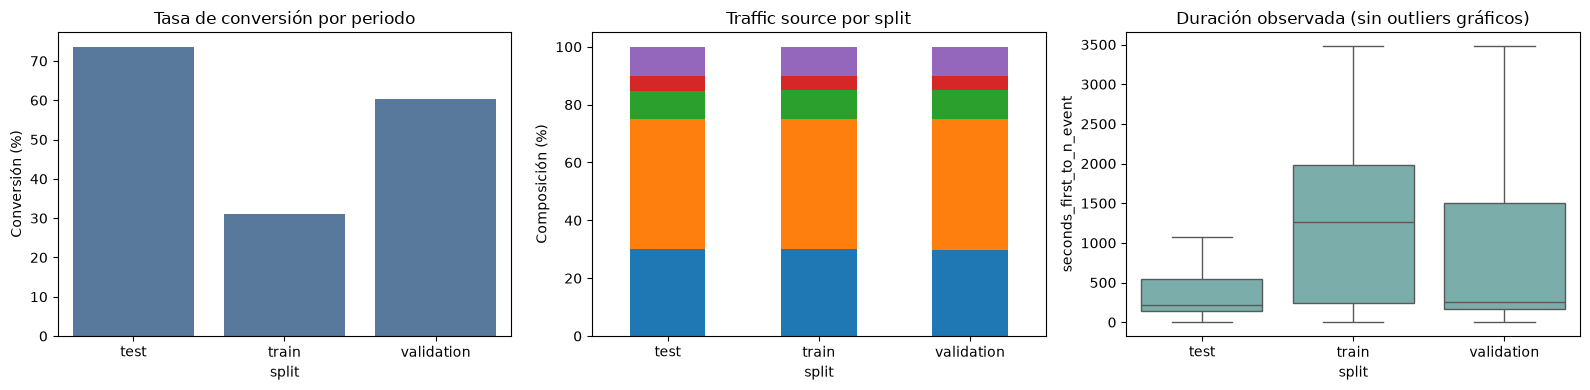

In [ ]:
target_by_split = (
    ordered_model.groupby("split", as_index=False)
    .agg(sessions=(TARGET, "size"), conversion_rate=(TARGET, "mean"))
)
target_by_split["conversion_rate"] *= 100
display(target_by_split)

distribution_tables = {}
for feature in ["traffic_source", "browser", "hour_of_day"]:
    distribution = pd.crosstab(
        ordered_model[feature].fillna("MISSING"), ordered_model["split"], normalize="columns"
    ).mul(100)
    distribution_tables[feature] = distribution
    print(f"Distribución porcentual: {feature}")
    display(distribution)

drift_numeric = [
    "seconds_first_to_n_event", "max_seconds_between_events",
    "number_home_events", "number_cart_events", "number_cancel_events",
    "mean_product_price_seen",
]
numeric_drift_summary = ordered_model.groupby("split")[drift_numeric].agg(["mean", "median"])
display(numeric_drift_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(data=target_by_split, x="split", y="conversion_rate", ax=axes[0], color="#4c78a8")
axes[0].set_title("Tasa de conversión por periodo")
axes[0].set_ylabel("Conversión (%)")

traffic_plot = distribution_tables["traffic_source"].T
traffic_plot.plot(kind="bar", stacked=True, ax=axes[1], legend=False)
axes[1].set_title("Traffic source por split")
axes[1].set_ylabel("Composición (%)")
axes[1].tick_params(axis="x", rotation=0)

sample_for_plot = ordered_model.groupby("split", group_keys=False).sample(
    n=min(10000, ordered_model.groupby("split").size().min()), random_state=RANDOM_STATE
)
sns.boxplot(
    data=sample_for_plot, x="split", y="seconds_first_to_n_event",
    showfliers=False, ax=axes[2], color="#72b7b2"
)
axes[2].set_title("Duración observada (sin outliers gráficos)")
fig.tight_layout()
plt.show()

### 13.13. Resultado final de la etapa

In [ ]:
excluded_rows = []
def exclude_many(features, reason, category):
    for feature in features:
        excluded_rows.append({"feature": feature, "reason": reason, "category": category})

exclude_many(["session_id", "user_id"], "Identificador; no predictor", "IDENTIFIER")
exclude_many(["session_start_time", "prediction_time"], "Solo metadata y split", "RAW_TIMESTAMP")
exclude_many(constant_features, "Cardinalidad <= 1", "CONSTANT")
exclude_many([
    "min_product_price_seen", "max_product_price_seen",
    "home_event_ratio", "department_event_ratio", "product_event_ratio",
    "cart_event_ratio", "cancel_event_ratio", "avg_seconds_between_events",
    "cart_seen_before_n", "weekend_flag", "number_department_events",
    "number_cart_events",
], "Información determinista ya representada por otra feature conservada", "REDUNDANT")
exclude_many(["city"], "Cardinalidad alta para el set contextual principal", "HIGH_CARDINALITY")
exclude_many(["seconds_first_to_n_event", "max_seconds_between_events"],
             "AUC univariado > 0.99; atajo del generador temporal sintético",
             "STRUCTURAL_PROXY")
exclude_many(STRUCTURAL_ABLATION_FEATURES,
             "Ligada a disponibilidad de identidad; solo ablación", "STRUCTURAL_PROXY")

excluded_features = (
    pd.DataFrame(excluded_rows).drop_duplicates("feature")
    .sort_values(["category", "feature"]).reset_index(drop=True)
)
display(excluded_features)
print("FEATURE_SET_A:", FEATURE_SET_A)
print("FEATURE_SET_B:", FEATURE_SET_B)
print("FEATURE_SET_C (ABLATION_ONLY):", FEATURE_SET_C)
display(split_summary)
display(user_overlap_summary)
display(sequence_audit)
display(temporal_anomaly_summary)

display(Markdown(
    "**Recomendación:** Feature Set B debe ser el candidato principal porque combina "
    "comportamiento temprano con contexto disponible para anónimos e identificados. "
    "Las duraciones observadas se excluyen pese a ser temporales válidas porque su "
    "AUC > 0.99 revela otro atajo del generador sintético. "
    "Feature Set A es el baseline legítimo de comportamiento. Feature Set C es "
    "exclusivamente una ablación del proxy estructural y no puede seleccionarse por "
    "una mejora de desempeño causada por identidad."
))

if overlap_percentage >= 5:
    display(Markdown(
        "**CONDICIÓN DE PURGA ACTIVADA:** el overlap supera 5%. La autorización ya fue recibida; "
        "la siguiente sección elimina todas las sesiones de usuarios que cruzan fronteras."
    ))
else:
    display(Markdown(
        "El overlap es menor a 5%. Se propone retirar usuarios cruzados, pendiente de aprobación."
    ))

,feature,reason,category
0,number_events_observed,Cardinalidad <= 1,CONSTANT
1,number_product_events,Cardinalidad <= 1,CONSTANT
2,product_event_ratio,Cardinalidad <= 1,CONSTANT
3,product_seen_before_n,Cardinalidad <= 1,CONSTANT
4,unique_categories_seen,Cardinalidad <= 1,CONSTANT
5,unique_event_types,Cardinalidad <= 1,CONSTANT
6,unique_products_seen,Cardinalidad <= 1,CONSTANT
7,unique_uris,Cardinalidad <= 1,CONSTANT
8,city,Cardinalidad alta para el set contextual princ...,HIGH_CARDINALITY
9,session_id,Identificador; no predictor,IDENTIFIER


FEATURE_SET_A: ['hour_of_day', 'day_of_week', 'number_home_events', 'number_cancel_events', 'mean_product_price_seen']
FEATURE_SET_B: ['hour_of_day', 'day_of_week', 'number_home_events', 'number_cancel_events', 'mean_product_price_seen', 'traffic_source', 'browser', 'state']
FEATURE_SET_C (ABLATION_ONLY): ['hour_of_day', 'day_of_week', 'number_home_events', 'number_cancel_events', 'mean_product_price_seen', 'traffic_source', 'browser', 'state', 'country', 'customer_age_at_session_proxy', 'customer_tenure_days', 'prior_sessions', 'prior_purchases', 'prior_orders', 'prior_items_purchased', 'historical_total_spend', 'historical_avg_order_value', 'historical_conversion_rate', 'days_since_last_session', 'days_since_last_purchase']


,split,n_sessions,start_date,end_date,positives,negatives,conversion_rate
1,train,300710,2019-01-02 01:00:00+00:00,2025-05-19 11:00:00+00:00,93576,207134,31.118353
2,validation,64438,2025-05-19 11:00:44+00:00,2026-03-02 19:07:51+00:00,38946,25492,60.439492
0,test,64437,2026-03-02 19:09:05+00:00,2026-09-11 00:25:04.879814+00:00,47426,17011,73.600571


,metric,value
0,unique_users_train,46687.000000
1,unique_users_validation,23081.000000
2,unique_users_test,26169.000000
3,users_train_and_validation,7434.000000
4,users_train_and_test,5278.000000
5,users_validation_and_test,4559.000000
6,users_in_all_three,1221.000000
7,unique_cross_boundary_users,14829.000000
8,sessions_affected,57186.000000
9,dataset_percentage_affected,13.311917


,event_sequence_3,sessions,positives,negatives,conversion_rate
0,department > product > cart,218659,93536,125123,42.7771
1,product > cart > cancel,124514,0,124514,0.0000
2,home > department > product,87733,87733,0,100.0000


,snapshot_cutoff,events_affected,sessions_affected,dataset_percentage,positive_sessions,negative_sessions
0,2026-09-11 21:08:38.787000+00:00,1321,1321,0.306563,1321,0


**Recomendación:** Feature Set B debe ser el candidato principal porque combina comportamiento temprano con contexto disponible para anónimos e identificados. Las duraciones observadas se excluyen pese a ser temporales válidas porque su AUC > 0.99 revela otro atajo del generador sintético. Feature Set A es el baseline legítimo de comportamiento. Feature Set C es exclusivamente una ablación del proxy estructural y no puede seleccionarse por una mejora de desempeño causada por identidad.

**CONDICIÓN DE PURGA ACTIVADA:** el overlap supera 5%. La autorización ya fue recibida; la siguiente sección elimina todas las sesiones de usuarios que cruzan fronteras.

### 13.14. Split temporal purgado autorizado

Se eliminan **todas** las sesiones de cada `user_id` presente en más de un split. Las sesiones anónimas se conservan y cada `session_id` anónimo permanece como entidad independiente. No se modifica la feature table.

In [ ]:
purge_mask = (
    ordered_model["user_id"].notna()
    & ordered_model["user_id"].astype("Int64").isin(cross_boundary_users)
)
removed_sessions = ordered_model.loc[purge_mask].copy()
purged_model = ordered_model.loc[~purge_mask].copy()

train_purged = purged_model.loc[purged_model.split.eq("train")].copy()
validation_purged = purged_model.loc[purged_model.split.eq("validation")].copy()
test_purged = purged_model.loc[purged_model.split.eq("test")].copy()
purged_splits = {
    "train": train_purged,
    "validation": validation_purged,
    "test": test_purged,
}

purged_rows = []
for split, frame in purged_splits.items():
    identified_sessions = int(frame.user_id.notna().sum())
    anonymous_sessions = int(frame.user_id.isna().sum())
    purged_rows.append({
        "split": split,
        "sessions": len(frame),
        "dataset_percentage": 100 * len(frame) / len(purged_model),
        "positive": int(frame[TARGET].sum()),
        "negative": int((frame[TARGET] == 0).sum()),
        "conversion_rate": 100 * frame[TARGET].mean(),
        "identified_sessions": identified_sessions,
        "identified_unique_users": frame.user_id.nunique(dropna=True),
        "anonymous_sessions": anonymous_sessions,
        "anonymous_percentage": 100 * anonymous_sessions / len(frame),
        "start_date": frame.prediction_time.min(),
        "end_date": frame.prediction_time.max(),
    })

purged_split_summary = pd.DataFrame(purged_rows)
purged_split_summary["split"] = pd.Categorical(
    purged_split_summary.split, ["train", "validation", "test"], ordered=True
)
purged_split_summary = purged_split_summary.sort_values("split")
display(purged_split_summary)

assert df_model.user_id.isna().sum() == purged_model.user_id.isna().sum()
assert len(df_model) - len(purged_model) == len(removed_sessions)

,split,sessions,dataset_percentage,positive,negative,conversion_rate,identified_sessions,identified_unique_users,anonymous_sessions,anonymous_percentage,start_date,end_date
0,train,276495,74.246977,69361,207134,25.085806,69361,35196,207134,74.914194,2019-01-02 01:00:00+00:00,2025-05-19 11:00:00+00:00
1,validation,45929,12.333277,20437,25492,44.496941,20437,12309,25492,55.503059,2025-05-19 11:18:00+00:00,2026-03-02 19:07:17+00:00
2,test,49975,13.419746,32964,17011,65.960980,32964,17553,17011,34.039020,2026-03-02 19:18:00+00:00,2026-09-11 00:25:04.879814+00:00


### 13.15. Validación de separación por usuario

In [ ]:
purged_user_sets = {
    split: set(frame.user_id.dropna().astype(int))
    for split, frame in purged_splits.items()
}
post_purge_overlap = pd.DataFrame([
    {"comparison": "train ∩ validation", "overlap_users": len(purged_user_sets["train"] & purged_user_sets["validation"])},
    {"comparison": "train ∩ test", "overlap_users": len(purged_user_sets["train"] & purged_user_sets["test"])},
    {"comparison": "validation ∩ test", "overlap_users": len(purged_user_sets["validation"] & purged_user_sets["test"])},
])
display(post_purge_overlap)
assert purged_user_sets["train"].isdisjoint(purged_user_sets["validation"])
assert purged_user_sets["train"].isdisjoint(purged_user_sets["test"])
assert purged_user_sets["validation"].isdisjoint(purged_user_sets["test"])
print("Overlap de user_id después de la purga: 0")

,comparison,overlap_users
0,train ∩ validation,0
1,train ∩ test,0
2,validation ∩ test,0


Overlap de user_id después de la purga: 0


### 13.16. Comparación antes y después de la purga

In [ ]:
before_indexed = split_summary.set_index("split")
after_indexed = purged_split_summary.set_index("split")
comparison_rows = []
for split in ["train", "validation", "test"]:
    comparison_rows.extend([
        {"split": split, "metric": "sessions", "before_purge": before_indexed.loc[split, "n_sessions"], "after_purge": after_indexed.loc[split, "sessions"]},
        {"split": split, "metric": "conversion_rate", "before_purge": before_indexed.loc[split, "conversion_rate"], "after_purge": after_indexed.loc[split, "conversion_rate"]},
        {"split": split, "metric": "positive", "before_purge": before_indexed.loc[split, "positives"], "after_purge": after_indexed.loc[split, "positive"]},
        {"split": split, "metric": "negative", "before_purge": before_indexed.loc[split, "negatives"], "after_purge": after_indexed.loc[split, "negative"]},
    ])
before_after_purge = pd.DataFrame(comparison_rows)
display(before_after_purge)

removal_summary = pd.DataFrame([{
    "sessions_before": len(ordered_model),
    "sessions_after": len(purged_model),
    "sessions_removed": len(removed_sessions),
    "percentage_removed": 100 * len(removed_sessions) / len(ordered_model),
    "positives_removed": int(removed_sessions[TARGET].sum()),
    "negatives_removed": int((removed_sessions[TARGET] == 0).sum()),
    "positive_percentage_among_removed": 100 * removed_sessions[TARGET].mean(),
}])
display(removal_summary)
display(removed_sessions[TARGET].value_counts().sort_index().rename("sessions_removed").to_frame())

,split,metric,before_purge,after_purge
0,train,sessions,300710.000000,276495.000000
1,train,conversion_rate,31.118353,25.085806
2,train,positive,93576.000000,69361.000000
3,train,negative,207134.000000,207134.000000
4,validation,sessions,64438.000000,45929.000000
5,validation,conversion_rate,60.439492,44.496941
6,validation,positive,38946.000000,20437.000000
7,validation,negative,25492.000000,25492.000000
8,test,sessions,64437.000000,49975.000000
9,test,conversion_rate,73.600571,65.960980


,sessions_before,sessions_after,sessions_removed,percentage_removed,positives_removed,negatives_removed,positive_percentage_among_removed
0,429585,372399,57186,13.311917,57186,0,100.0


,sessions_removed
converted_after_n,
1,57186


### 13.17. Drift del target después de la purga

In [ ]:
purged_rates = after_indexed["conversion_rate"]
validation_minus_train = purged_rates.loc["validation"] - purged_rates.loc["train"]
test_minus_train = purged_rates.loc["test"] - purged_rates.loc["train"]
max_gap = max(abs(validation_minus_train), abs(test_minus_train))
if max_gap < 2:
    drift_level = "LOW"
elif max_gap < 5:
    drift_level = "MODERATE"
elif max_gap < 10:
    drift_level = "HIGH"
else:
    drift_level = "VERY_HIGH"

purged_drift = pd.DataFrame([{
    "train_conversion_rate": purged_rates.loc["train"],
    "validation_conversion_rate": purged_rates.loc["validation"],
    "test_conversion_rate": purged_rates.loc["test"],
    "validation_minus_train_pp": validation_minus_train,
    "test_minus_train_pp": test_minus_train,
    "drift_level": drift_level,
}])
display(purged_drift)
display(Markdown(
    f"El drift se clasifica como **{drift_level}**. Esto implica que prevalencia, "
    "calibración, umbrales y métricas no serán intercambiables entre periodos. "
    "Test debe permanecer cerrado hasta congelar decisiones con train/validation."
))

,train_conversion_rate,validation_conversion_rate,test_conversion_rate,validation_minus_train_pp,test_minus_train_pp,drift_level
0,25.085806,44.496941,65.96098,19.411135,40.875174,VERY_HIGH


El drift se clasifica como **VERY_HIGH**. Esto implica que prevalencia, calibración, umbrales y métricas no serán intercambiables entre periodos. Test debe permanecer cerrado hasta congelar decisiones con train/validation.

### 13.18. Decisión metodológica posterior a la purga

In [ ]:
display(Markdown(f"""
**Resultado de la purga**

- El overlap de usuarios es cero en los tres pares de splits.
- Se conservaron todas las sesiones anónimas.
- `FEATURE_SET_B` sigue siendo el candidato principal: excluye identificadores, perfil, historial, ciudad de alta cardinalidad y los shortcuts temporales con AUC > 0.99.
- `FEATURE_SET_C` continúa como `ABLATION_ONLY`.
- El split purgado es el candidato recomendado para cumplir simultáneamente separación temporal y por usuario, pero elimina {len(removed_sessions):,} sesiones de forma selectiva y mantiene drift **{drift_level}**. El modelado final deberá reportar esta limitación y no usar test para decisiones.

No se entrenó ningún modelo.
"""))


**Resultado de la purga**

- El overlap de usuarios es cero en los tres pares de splits.
- Se conservaron todas las sesiones anónimas.
- `FEATURE_SET_B` sigue siendo el candidato principal: excluye identificadores, perfil, historial, ciudad de alta cardinalidad y los shortcuts temporales con AUC > 0.99.
- `FEATURE_SET_C` continúa como `ABLATION_ONLY`.
- El split purgado es el candidato recomendado para cumplir simultáneamente separación temporal y por usuario, pero elimina 57,186 sesiones de forma selectiva y mantiene drift **VERY_HIGH**. El modelado final deberá reportar esta limitación y no usar test para decisiones.

No se entrenó ningún modelo.


## 14. Resultados de Modelos Baseline

Se entrenan tres clasificadores base con `FEATURE_SET_B`, usando exclusivamente `train_purged` para ajustar tanto el preprocesamiento como el estimador. `validation_purged` se utiliza únicamente para evaluación con threshold fijo de 0.50. No se realiza optimización de hiperparámetros ni de threshold.

> **TEST SELLADO**
>
> El conjunto TEST permanece sellado durante selección de modelo, hiperparámetros y threshold. No se crean `X_test`/`y_test`, no se ajusta preprocessing con test y no se calculan métricas sobre test.

In [ ]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from pandas.api.types import is_numeric_dtype
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, brier_score_loss,
)
from sklearn.calibration import calibration_curve

RANDOM_STATE = 42
TARGET = 'converted_after_n'
MAIN_FEATURE_SET = list(FEATURE_SET_B)

print('FEATURE_SET_B exacto:')
print(MAIN_FEATURE_SET)
assert MAIN_FEATURE_SET == list(FEATURE_SET_A) + ['traffic_source', 'browser', 'state']
assert TARGET not in MAIN_FEATURE_SET
assert 'session_id' not in MAIN_FEATURE_SET
assert 'user_id' not in MAIN_FEATURE_SET
assert MAIN_FEATURE_SET != list(FEATURE_SET_C)

X_train = train_purged[MAIN_FEATURE_SET].copy()
y_train = train_purged[TARGET].astype('int8').copy()
X_val = validation_purged[MAIN_FEATURE_SET].copy()
y_val = validation_purged[TARGET].astype('int8').copy()

numeric_features = [c for c in MAIN_FEATURE_SET if is_numeric_dtype(X_train[c])]
categorical_features = [c for c in MAIN_FEATURE_SET if c not in numeric_features]
print('numeric_features:', numeric_features)
print('categorical_features:', categorical_features)

category_cardinalities = (
    X_train[categorical_features].nunique(dropna=False)
    .sort_values(ascending=False).rename('train_cardinality').to_frame()
)
display(category_cardinalities)

train_users = set(train_purged.user_id.dropna().astype(int))
validation_users = set(validation_purged.user_id.dropna().astype(int))
assert train_users.isdisjoint(validation_users)
assert pd.to_datetime(train_purged.prediction_time, utc=True).max() < pd.to_datetime(validation_purged.prediction_time, utc=True).min()
assert TARGET not in X_train.columns and TARGET not in X_val.columns
assert 'session_id' not in X_train.columns and 'user_id' not in X_train.columns
assert len(X_train) == len(y_train) and len(X_val) == len(y_val)

def make_preprocessor(feature_frame, scale_numeric=False, dense_output=False):
    numeric = [c for c in feature_frame.columns if is_numeric_dtype(feature_frame[c])]
    categorical = [c for c in feature_frame.columns if c not in numeric]
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))
    return ColumnTransformer(
        transformers=[
            ('numeric', Pipeline(numeric_steps), numeric),
            ('categorical', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=not dense_output, dtype=np.float32)),
            ]), categorical),
        ],
        remainder='drop',
        sparse_threshold=0.0 if dense_output else 0.3,
        verbose_feature_names_out=True,
    )

validation_prevalence = float(y_val.mean())
print(f'Validation prevalence / PR-AUC no-skill: {validation_prevalence:.6f}')
print('Controles de sanidad superados; no se creó X_test ni y_test.')

FEATURE_SET_B exacto:
['hour_of_day', 'day_of_week', 'number_home_events', 'number_cancel_events', 'mean_product_price_seen', 'traffic_source', 'browser', 'state']
numeric_features: ['hour_of_day', 'day_of_week', 'number_home_events', 'number_cancel_events', 'mean_product_price_seen']
categorical_features: ['traffic_source', 'browser', 'state']


,train_cardinality
state,231
traffic_source,5
browser,5


Validation prevalence / PR-AUC no-skill: 0.444969
Controles de sanidad superados; no se creó X_test ni y_test.


### 14.1. Entrenamiento y métricas en validation

`xgboost` se utiliza únicamente si ya está disponible. En caso contrario se aplica el fallback autorizado `HistGradientBoostingClassifier`, con codificación one-hot densa compatible.

In [ ]:
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

logistic_pipeline = Pipeline([
    ('preprocessing', make_preprocessor(X_train, scale_numeric=True, dense_output=False)),
    ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
random_forest_pipeline = Pipeline([
    ('preprocessing', make_preprocessor(X_train, scale_numeric=False, dense_output=False)),
    ('model', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
])

if XGBOOST_AVAILABLE:
    third_model_name = 'XGBoost'
    third_pipeline = Pipeline([
        ('preprocessing', make_preprocessor(X_train, scale_numeric=False, dense_output=False)),
        ('model', XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
            random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])
else:
    third_model_name = 'HistGradientBoosting'
    third_pipeline = Pipeline([
        ('preprocessing', make_preprocessor(X_train, scale_numeric=False, dense_output=True)),
        ('model', HistGradientBoostingClassifier(
            max_iter=200, learning_rate=0.08, max_leaf_nodes=31,
            l2_regularization=1.0, random_state=RANDOM_STATE,
        )),
    ])
    print('xgboost no está disponible; se usa HistGradientBoostingClassifier sin instalar paquetes.')

baseline_models = {
    'Logistic Regression': logistic_pipeline,
    'Random Forest': random_forest_pipeline,
    third_model_name: third_pipeline,
}
validation_probabilities = {}
validation_predictions = {}
confusion_matrices_validation = {}
model_fit_sources = {}
metric_rows = []

for model_name, pipeline in baseline_models.items():
    started = time.perf_counter()
    pipeline.fit(X_train, y_train)
    model_fit_sources[model_name] = 'train_purged'
    probability = pipeline.predict_proba(X_val)[:, 1]
    prediction = (probability >= 0.50).astype('int8')
    validation_probabilities[model_name] = probability
    validation_predictions[model_name] = prediction
    confusion_matrices_validation[model_name] = confusion_matrix(y_val, prediction)
    pr_auc = average_precision_score(y_val, probability)
    metric_rows.append({
        'model': model_name,
        'accuracy': accuracy_score(y_val, prediction),
        'precision': precision_score(y_val, prediction, zero_division=0),
        'recall': recall_score(y_val, prediction, zero_division=0),
        'f1': f1_score(y_val, prediction, zero_division=0),
        'roc_auc': roc_auc_score(y_val, probability),
        'pr_auc': pr_auc,
        'pr_auc_baseline': validation_prevalence,
        'pr_auc_gain': pr_auc - validation_prevalence,
        'pr_auc_lift': pr_auc / validation_prevalence,
        'brier_score': brier_score_loss(y_val, probability),
        'fit_seconds': time.perf_counter() - started,
    })

assert set(model_fit_sources.values()) == {'train_purged'}
assert set(baseline_models) == {'Logistic Regression', 'Random Forest', third_model_name}
assert list(FEATURE_SET_C) != MAIN_FEATURE_SET
model_results_validation = (
    pd.DataFrame(metric_rows).sort_values('pr_auc', ascending=False).reset_index(drop=True)
)
display(model_results_validation.style.format({c: '{:.6f}' for c in model_results_validation.columns if c != 'model'}))
for model_name, matrix in confusion_matrices_validation.items():
    display(pd.DataFrame(matrix, index=['actual_0', 'actual_1'], columns=['pred_0', 'pred_1']).rename_axis(model_name))

xgboost no está disponible; se usa HistGradientBoostingClassifier sin instalar paquetes.


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,pr_auc_baseline,pr_auc_gain,pr_auc_lift,brier_score,fit_seconds
0,HistGradientBoosting,0.810294,0.995352,0.576357,0.730005,0.898065,0.895881,0.444969,0.450911,2.013354,0.127968,13.127049
1,Random Forest,0.808073,0.949212,0.600822,0.735864,0.897112,0.893388,0.444969,0.448418,2.007751,0.135646,78.753373
2,Logistic Regression,0.770711,0.998490,0.485443,0.653278,0.891539,0.887997,0.444969,0.443027,1.995636,0.141216,1.074394


,pred_0,pred_1
Logistic Regression,,
actual_0,25477,15
actual_1,10516,9921


,pred_0,pred_1
Random Forest,,
actual_0,24835,657
actual_1,8158,12279


,pred_0,pred_1
HistGradientBoosting,,
actual_0,25437,55
actual_1,8658,11779


### 14.2. ROC, Precision–Recall y matrices de confusión

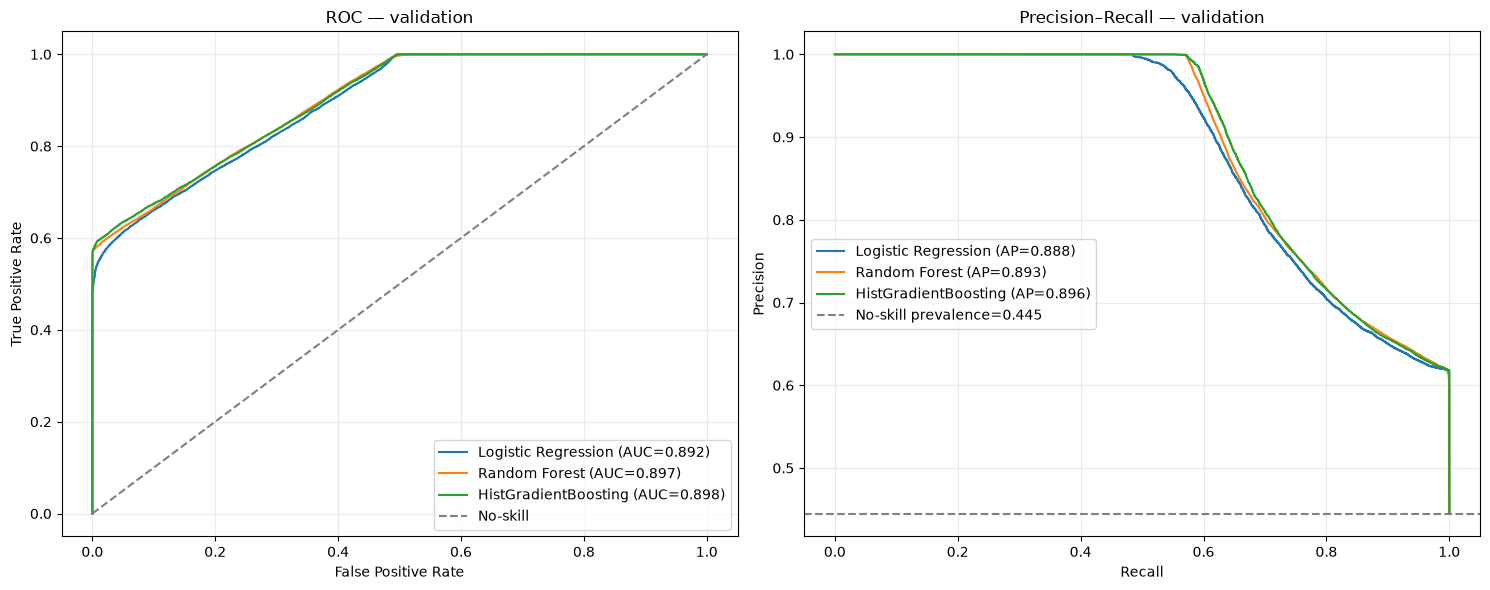

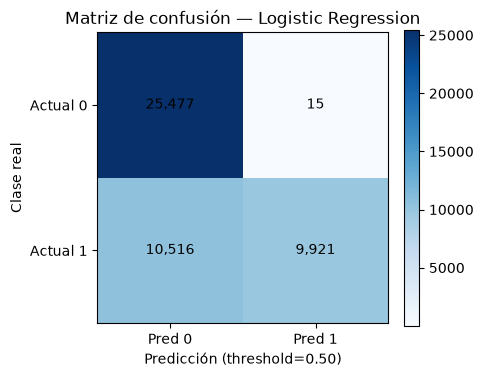

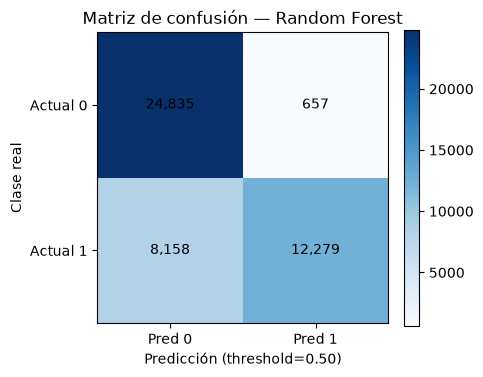

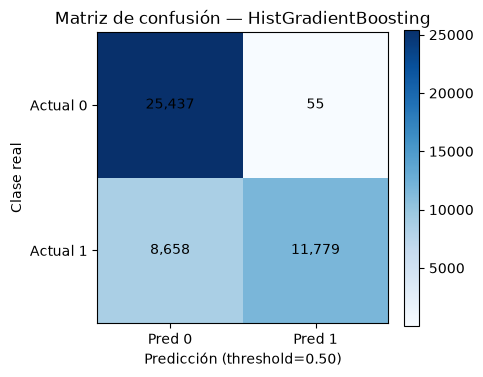

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for model_name, probability in validation_probabilities.items():
    fpr, tpr, _ = roc_curve(y_val, probability)
    precision_curve, recall_curve, _ = precision_recall_curve(y_val, probability)
    row = model_results_validation.set_index('model').loc[model_name]
    axes[0].plot(fpr, tpr, label=f"{model_name} (AUC={row.roc_auc:.3f})")
    axes[1].plot(recall_curve, precision_curve, label=f"{model_name} (AP={row.pr_auc:.3f})")
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='No-skill')
axes[0].set(title='ROC — validation', xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[1].axhline(validation_prevalence, linestyle='--', color='gray', label=f'No-skill prevalence={validation_prevalence:.3f}')
axes[1].set(title='Precision–Recall — validation', xlabel='Recall', ylabel='Precision')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

for model_name, matrix in confusion_matrices_validation.items():
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    image = ax.imshow(matrix, cmap='Blues')
    for (row_idx, col_idx), value in np.ndenumerate(matrix):
        ax.text(col_idx, row_idx, f'{value:,}', ha='center', va='center')
    ax.set_xticks([0, 1], labels=['Pred 0', 'Pred 1'])
    ax.set_yticks([0, 1], labels=['Actual 0', 'Actual 1'])
    ax.set_title(f'Matriz de confusión — {model_name}')
    ax.set_xlabel('Predicción (threshold=0.50)')
    ax.set_ylabel('Clase real')
    fig.colorbar(image, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()

### 14.3. Distribución de probabilidades y calibración exploratoria

La calibración se evalúa sin recalibrar. El cambio de prevalencia de train a validation puede desplazar sustancialmente las probabilidades y el Brier Score.

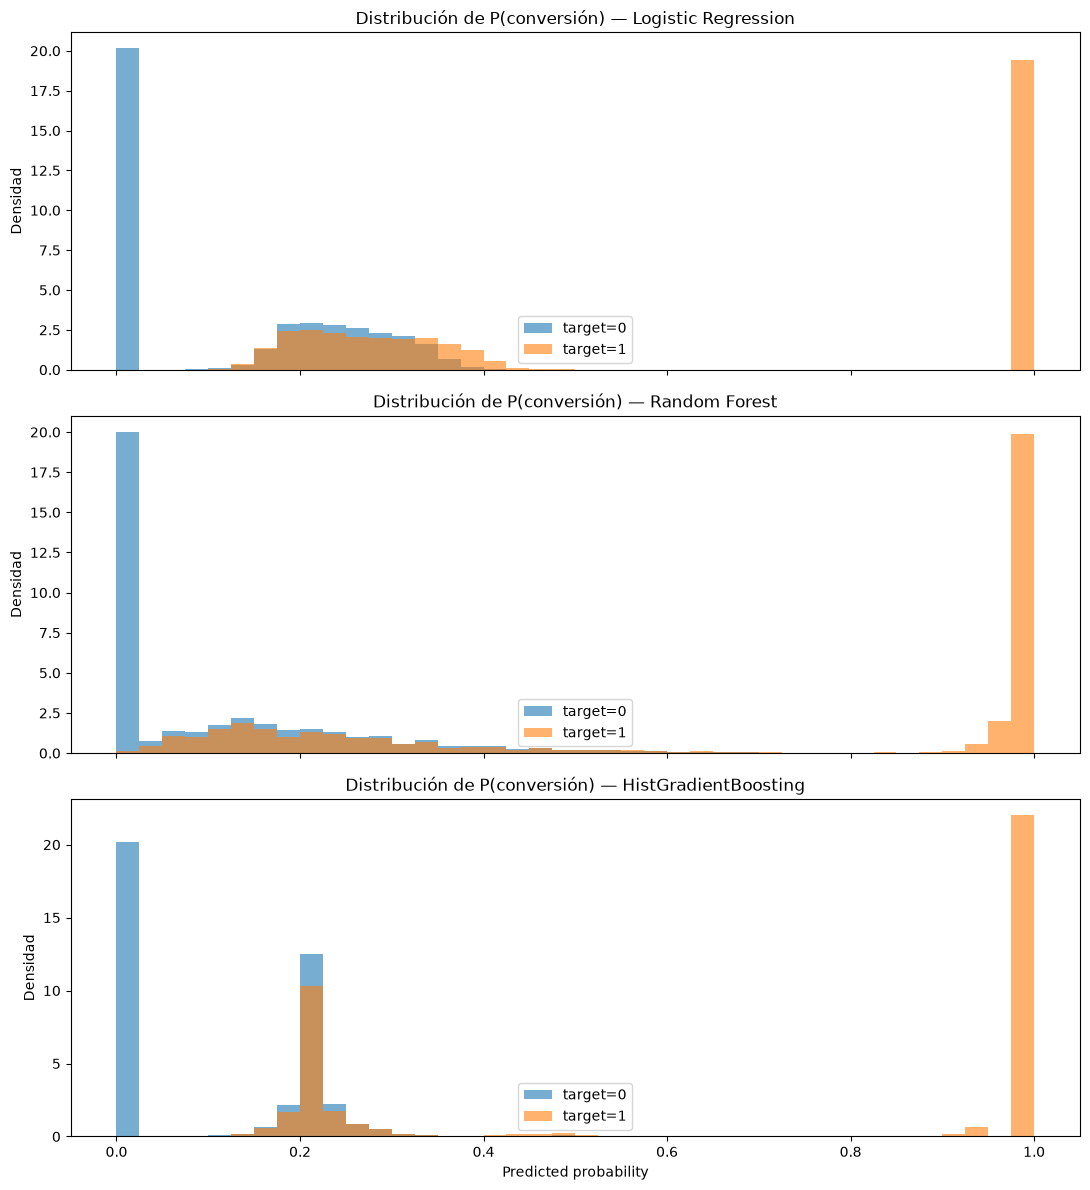

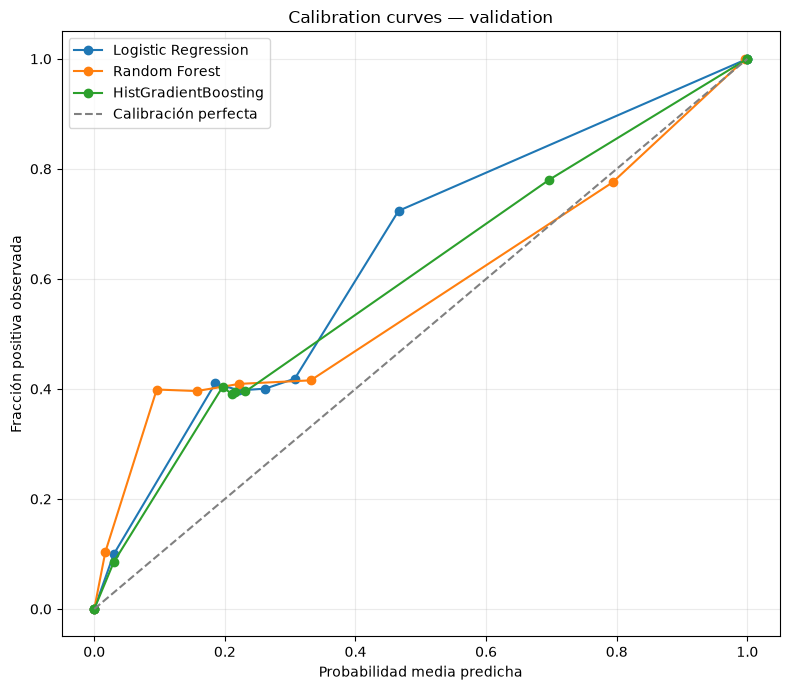

,model,brier_score,mean_predicted_probability,validation_prevalence
0,HistGradientBoosting,0.127968,0.358087,0.444969
1,Random Forest,0.135646,0.357312,0.444969
2,Logistic Regression,0.141216,0.347171,0.444969


In [ ]:
fig, axes = plt.subplots(len(validation_probabilities), 1, figsize=(11, 4 * len(validation_probabilities)), sharex=True)
axes = np.atleast_1d(axes)
bins = np.linspace(0, 1, 41)
for ax, (model_name, probability) in zip(axes, validation_probabilities.items()):
    ax.hist(probability[y_val.to_numpy() == 0], bins=bins, alpha=0.60, density=True, label='target=0')
    ax.hist(probability[y_val.to_numpy() == 1], bins=bins, alpha=0.60, density=True, label='target=1')
    ax.set(title=f'Distribución de P(conversión) — {model_name}', ylabel='Densidad')
    ax.legend()
axes[-1].set_xlabel('Predicted probability')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
calibration_rows = []
for model_name, probability in validation_probabilities.items():
    fraction_positive, mean_predicted = calibration_curve(y_val, probability, n_bins=10, strategy='quantile')
    ax.plot(mean_predicted, fraction_positive, marker='o', label=model_name)
    calibration_rows.append({
        'model': model_name,
        'brier_score': brier_score_loss(y_val, probability),
        'mean_predicted_probability': float(np.mean(probability)),
        'validation_prevalence': validation_prevalence,
    })
ax.plot([0, 1], [0, 1], '--', color='gray', label='Calibración perfecta')
ax.set(title='Calibration curves — validation', xlabel='Probabilidad media predicha', ylabel='Fracción positiva observada')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
calibration_results_validation = pd.DataFrame(calibration_rows).sort_values('brier_score').reset_index(drop=True)
display(calibration_results_validation.style.format({c: '{:.6f}' for c in calibration_results_validation.columns if c != 'model'}))

### 14.4. Ablación A/B/C con Logistic Regression

`FEATURE_SET_C` permanece estrictamente etiquetado como **ABLATION_ONLY**. Esta comparación diagnostica el efecto de proxies estructurales; no autoriza su uso en el modelo final.

In [ ]:
ablation_feature_sets = {
    'FEATURE_SET_A': list(FEATURE_SET_A),
    'FEATURE_SET_B': list(FEATURE_SET_B),
    'FEATURE_SET_C (ABLATION_ONLY)': list(FEATURE_SET_C),
}
assert ablation_feature_sets['FEATURE_SET_C (ABLATION_ONLY)'] != MAIN_FEATURE_SET
ablation_rows = []
ablation_pipelines = {}
for set_name, features in ablation_feature_sets.items():
    assert TARGET not in features and 'session_id' not in features and 'user_id' not in features
    X_train_ablation = train_purged[features].copy()
    X_val_ablation = validation_purged[features].copy()
    pipeline = Pipeline([
        ('preprocessing', make_preprocessor(X_train_ablation, scale_numeric=True, dense_output=False)),
        ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])
    pipeline.fit(X_train_ablation, y_train)
    probability = pipeline.predict_proba(X_val_ablation)[:, 1]
    prediction = (probability >= 0.50).astype('int8')
    pr_auc = average_precision_score(y_val, probability)
    ablation_rows.append({
        'feature_set': set_name,
        'roc_auc': roc_auc_score(y_val, probability),
        'pr_auc': pr_auc,
        'pr_auc_lift': pr_auc / validation_prevalence,
        'precision': precision_score(y_val, prediction, zero_division=0),
        'recall': recall_score(y_val, prediction, zero_division=0),
        'f1': f1_score(y_val, prediction, zero_division=0),
    })
    ablation_pipelines[set_name] = pipeline

ablation_results_validation = pd.DataFrame(ablation_rows).sort_values('pr_auc', ascending=False).reset_index(drop=True)
display(ablation_results_validation.style.format({c: '{:.6f}' for c in ablation_results_validation.columns if c != 'feature_set'}))
c_result = ablation_results_validation.set_index('feature_set').loc['FEATURE_SET_C (ABLATION_ONLY)']
if c_result.roc_auc >= 0.98 or c_result.pr_auc >= 0.98:
    display(Markdown('**Evidencia fuerte de shortcut estructural:** FEATURE_SET_C se aproxima a clasificación perfecta. Permanece `ABLATION_ONLY`.'))

,feature_set,roc_auc,pr_auc,pr_auc_lift,precision,recall,f1
0,FEATURE_SET_C (ABLATION_ONLY),0.999979,0.999983,2.247307,1.000000,0.999804,0.999902
1,FEATURE_SET_A,0.893966,0.892021,2.004680,1.000000,0.484856,0.653068
2,FEATURE_SET_B,0.891539,0.887997,1.995636,0.998490,0.485443,0.653278


**Evidencia fuerte de shortcut estructural:** FEATURE_SET_C se aproxima a clasificación perfecta. Permanece `ABLATION_ONLY`.

### 14.5. Interpretabilidad asociativa

Los coeficientes e importancias describen asociaciones aprendidas por los modelos; **no implican causalidad**.

In [ ]:
def transformed_importance_frame(pipeline, values, value_name):
    names = pipeline.named_steps['preprocessing'].get_feature_names_out()
    assert len(names) == len(values)
    return pd.DataFrame({'feature': names, value_name: values})

logistic_coefficients = transformed_importance_frame(
    logistic_pipeline, logistic_pipeline.named_steps['model'].coef_.ravel(), 'coefficient'
)
top_positive_logistic = logistic_coefficients.nlargest(15, 'coefficient').reset_index(drop=True)
top_negative_logistic = logistic_coefficients.nsmallest(15, 'coefficient').reset_index(drop=True)
display(Markdown('**Logistic Regression — Top 15 asociaciones positivas**'))
display(top_positive_logistic)
display(Markdown('**Logistic Regression — Top 15 asociaciones negativas**'))
display(top_negative_logistic)

tree_importances = {}
for model_name in ['Random Forest', third_model_name]:
    pipeline = baseline_models[model_name]
    estimator = pipeline.named_steps['model']
    if hasattr(estimator, 'feature_importances_'):
        importance = transformed_importance_frame(pipeline, estimator.feature_importances_, 'importance')
        importance = importance.nlargest(20, 'importance').reset_index(drop=True)
        tree_importances[model_name] = importance
        display(Markdown(f'**{model_name} — Top 20 importancias (no causales)**'))
        display(importance)
    else:
        display(Markdown(f'**{model_name}:** el estimador no expone `feature_importances_`; no se fabrica una importancia sustituta en esta etapa baseline.'))

**Logistic Regression — Top 15 asociaciones positivas**

,feature,coefficient
0,numeric__number_home_events,4.445958
1,categorical__state_Sachsen,1.051612
2,categorical__state_Wyoming,0.927551
3,categorical__state_Shizuoka,0.651473
4,categorical__state_Mecklenburg-Vorpommern,0.588406
5,categorical__state_Navarra,0.507848
6,categorical__state_Remote territory,0.506584
7,categorical__state_Northern Territory,0.475485
8,categorical__state_Melilla,0.457852
9,categorical__state_Región de Murcia,0.453900


**Logistic Regression — Top 15 asociaciones negativas**

,feature,coefficient
0,numeric__number_cancel_events,-5.567079
1,categorical__state_Aragón,-0.764718
2,categorical__state_Islas Baleares,-0.755876
3,categorical__state_Lubuskie,-0.738761
4,categorical__state_Northern Ireland,-0.689385
5,categorical__state_Schleswig-Holstein,-0.683285
6,categorical__state_Alabama,-0.627708
7,categorical__state_Saarland,-0.625478
8,categorical__state_Brussels,-0.564010
9,categorical__traffic_source_Organic,-0.534142


**Random Forest — Top 20 importancias (no causales)**

,feature,importance
0,numeric__number_home_events,0.338733
1,numeric__hour_of_day,0.181281
2,numeric__mean_product_price_seen,0.157083
3,numeric__number_cancel_events,0.116790
4,numeric__day_of_week,0.044619
5,categorical__browser_Chrome,0.007531
6,categorical__traffic_source_Email,0.007447
7,categorical__traffic_source_Adwords,0.006950
8,categorical__browser_Safari,0.006234
9,categorical__browser_Firefox,0.006173


**HistGradientBoosting:** el estimador no expone `feature_importances_`; no se fabrica una importancia sustituta en esta etapa baseline.

### 14.6. Síntesis de resultados baseline

In [ ]:
best_pr = model_results_validation.loc[model_results_validation.pr_auc.idxmax()]
best_f1 = model_results_validation.loc[model_results_validation.f1.idxmax()]
best_recall = model_results_validation.loc[model_results_validation.recall.idxmax()]
best_calibrated = calibration_results_validation.loc[calibration_results_validation.brier_score.idxmin()]
lift_lines = '\n'.join(
    f"- {row.model}: lift={row.pr_auc_lift:.3f}x; ganancia absoluta={row.pr_auc_gain:.4f}"
    for row in model_results_validation.itertuples()
)
c_ablation = ablation_results_validation.set_index('feature_set').loc['FEATURE_SET_C (ABLATION_ONLY)']
shortcut_note = (
    'Sí. FEATURE_SET_C alcanza resultados casi perfectos, consistente con los proxies estructurales ya auditados. Dentro de FEATURE_SET_B, `number_home_events` y `number_cancel_events` dominan coeficientes/importancias y explican la precisión extrema observada; deben tratarse como señales estructurales fuertes, aunque fueron autorizadas dentro del set principal.'
    if c_ablation.roc_auc >= 0.98 or c_ablation.pr_auc >= 0.98
    else 'FEATURE_SET_C mejora el desempeño, pero no alcanza clasificación casi perfecta bajo este preprocessing.'
)
display(Markdown(f"""
**Lectura comparativa en validation (threshold=0.50)**

- Mayor PR-AUC: **{best_pr.model}** ({best_pr.pr_auc:.4f}).
- Mejor F1: **{best_f1.model}** ({best_f1.f1:.4f}).
- Mayor recall: **{best_recall.model}** ({best_recall.recall:.4f}).
- Menor Brier Score, como señal exploratoria de mejor calibración: **{best_calibrated.model}** ({best_calibrated.brier_score:.4f}). La curva de calibración debe revisarse junto con este resumen.

**Mejora sobre el baseline no-skill (prevalencia={validation_prevalence:.4f})**

{lift_lines}

**Shortcuts residuales:** {shortcut_note}

**Recomendación para optimización:** llevar **HistGradientBoosting** como candidato principal y conservar **Random Forest** como comparador. HistGradientBoosting combina el mayor PR-AUC y el menor Brier Score; Random Forest conserva el mejor F1 y recall al threshold fijo. La decisión considera el conjunto de métricas y no declara un ganador automático por una sola de ellas.

El drift temporal continúa siendo `VERY_HIGH`, por lo que las probabilidades no deben asumirse transportables ni perfectamente calibradas. TEST continúa sellado.

No se aplicaron GridSearchCV, RandomizedSearchCV, SMOTE, class weights, optimización de threshold, combinación train/validation ni persistencia de modelos.
"""))


**Lectura comparativa en validation (threshold=0.50)**

- Mayor PR-AUC: **HistGradientBoosting** (0.8959).
- Mejor F1: **Random Forest** (0.7359).
- Mayor recall: **Random Forest** (0.6008).
- Menor Brier Score, como señal exploratoria de mejor calibración: **HistGradientBoosting** (0.1280). La curva de calibración debe revisarse junto con este resumen.

**Mejora sobre el baseline no-skill (prevalencia=0.4450)**

- HistGradientBoosting: lift=2.013x; ganancia absoluta=0.4509
- Random Forest: lift=2.008x; ganancia absoluta=0.4484
- Logistic Regression: lift=1.996x; ganancia absoluta=0.4430

**Shortcuts residuales:** Sí. FEATURE_SET_C alcanza resultados casi perfectos, consistente con los proxies estructurales ya auditados. Dentro de FEATURE_SET_B, `number_home_events` y `number_cancel_events` dominan coeficientes/importancias y explican la precisión extrema observada; deben tratarse como señales estructurales fuertes, aunque fueron autorizadas dentro del set principal.

**Recomendación para optimización:** llevar **HistGradientBoosting** como candidato principal y conservar **Random Forest** como comparador. HistGradientBoosting combina el mayor PR-AUC y el menor Brier Score; Random Forest conserva el mejor F1 y recall al threshold fijo. La decisión considera el conjunto de métricas y no declara un ganador automático por una sola de ellas.

El drift temporal continúa siendo `VERY_HIGH`, por lo que las probabilidades no deben asumirse transportables ni perfectamente calibradas. TEST continúa sellado.

No se aplicaron GridSearchCV, RandomizedSearchCV, SMOTE, class weights, optimización de threshold, combinación train/validation ni persistencia de modelos.


## 15. Cierre de la fase de Machine Learning

La evaluación se realiza mediante compuertas. En esta primera compuerta se cuantifica el gap train–validation y se repiten únicamente con `train_purged` las auditorías que utilizaron el target. **TEST continúa sellado.**

### 15.1. Overfitting: train frente a validation

La clasificación usa diferencias absolutas orientadas a sobreajuste (`train − validation`, truncadas en cero). Se considera **LOW** cuando PR-AUC y ROC-AUC no caen más de 0.03 y F1 no cae más de 0.05; **HIGH** cuando PR-AUC o ROC-AUC caen al menos 0.10, o F1 al menos 0.15; los casos intermedios son **MODERATE**. Los umbrales representan deterioros pequeños, materialmente visibles y severos, respectivamente. Dado el cambio de prevalencia, el gap de PR-AUC se interpreta junto con ROC-AUC, F1 y Brier, no aisladamente.

In [ ]:
def binary_metric_row(model_name, split_name, y_true, probability, threshold=0.50):
    prediction = (np.asarray(probability) >= threshold).astype('int8')
    return {
        'model': model_name, 'split': split_name,
        'accuracy': accuracy_score(y_true, prediction),
        'precision': precision_score(y_true, prediction, zero_division=0),
        'recall': recall_score(y_true, prediction, zero_division=0),
        'f1': f1_score(y_true, prediction, zero_division=0),
        'roc_auc': roc_auc_score(y_true, probability),
        'pr_auc': average_precision_score(y_true, probability),
        'brier': brier_score_loss(y_true, probability),
    }

overfitting_metric_rows = []
for model_name, pipeline in baseline_models.items():
    train_probability = pipeline.predict_proba(X_train)[:, 1]
    overfitting_metric_rows.append(binary_metric_row(model_name, 'train', y_train, train_probability))
    overfitting_metric_rows.append(binary_metric_row(model_name, 'validation', y_val, validation_probabilities[model_name]))

train_validation_metrics = pd.DataFrame(overfitting_metric_rows)
display(train_validation_metrics.style.format({c: '{:.6f}' for c in train_validation_metrics.columns if c not in ['model', 'split']}))

overfitting_rows = []
for model_name in baseline_models:
    indexed = train_validation_metrics.loc[train_validation_metrics.model.eq(model_name)].set_index('split')
    pr_gap = float(indexed.loc['train', 'pr_auc'] - indexed.loc['validation', 'pr_auc'])
    roc_gap = float(indexed.loc['train', 'roc_auc'] - indexed.loc['validation', 'roc_auc'])
    f1_gap = float(indexed.loc['train', 'f1'] - indexed.loc['validation', 'f1'])
    adverse_pr, adverse_roc, adverse_f1 = max(pr_gap, 0), max(roc_gap, 0), max(f1_gap, 0)
    if adverse_pr >= 0.10 or adverse_roc >= 0.10 or adverse_f1 >= 0.15:
        level = 'HIGH'
    elif adverse_pr <= 0.03 and adverse_roc <= 0.03 and adverse_f1 <= 0.05:
        level = 'LOW'
    else:
        level = 'MODERATE'
    overfitting_rows.append({
        'model': model_name,
        'train_pr_auc': indexed.loc['train', 'pr_auc'], 'validation_pr_auc': indexed.loc['validation', 'pr_auc'], 'pr_auc_gap': pr_gap,
        'train_roc_auc': indexed.loc['train', 'roc_auc'], 'validation_roc_auc': indexed.loc['validation', 'roc_auc'], 'roc_auc_gap': roc_gap,
        'train_f1': indexed.loc['train', 'f1'], 'validation_f1': indexed.loc['validation', 'f1'], 'f1_gap': f1_gap,
        'overfitting_level': level,
    })
overfitting_summary = pd.DataFrame(overfitting_rows).sort_values(['overfitting_level', 'pr_auc_gap'], ascending=[True, False]).reset_index(drop=True)
display(overfitting_summary.style.format({c: '{:.6f}' for c in overfitting_summary.columns if c not in ['model', 'overfitting_level']}))

,model,split,accuracy,precision,recall,f1,roc_auc,pr_auc,brier
0,Logistic Regression,train,0.870280,0.998008,0.483860,0.651740,0.892373,0.809837,0.094016
1,Logistic Regression,validation,0.770711,0.998490,0.485443,0.653278,0.891539,0.887997,0.141216
2,Random Forest,train,0.999461,0.999711,0.998140,0.998925,0.999999,0.999996,0.012491
3,Random Forest,validation,0.808073,0.949212,0.600822,0.735864,0.897112,0.893388,0.135646
4,HistGradientBoosting,train,0.892761,0.991193,0.577644,0.729913,0.921680,0.853286,0.081250
5,HistGradientBoosting,validation,0.810294,0.995352,0.576357,0.730005,0.898065,0.895881,0.127968


,model,train_pr_auc,validation_pr_auc,pr_auc_gap,train_roc_auc,validation_roc_auc,roc_auc_gap,train_f1,validation_f1,f1_gap,overfitting_level
0,Random Forest,0.999996,0.893388,0.106608,0.999999,0.897112,0.102887,0.998925,0.735864,0.263061,HIGH
1,HistGradientBoosting,0.853286,0.895881,-0.042595,0.921680,0.898065,0.023615,0.729913,0.730005,-0.000093,LOW
2,Logistic Regression,0.809837,0.887997,-0.078160,0.892373,0.891539,0.000834,0.651740,0.653278,-0.001538,LOW


### 15.2. Reauditoría dependiente del target usando solo train

Se recalculan AUC univariado, información mutua, Cramér's V, diferencias por clase, disponibilidad por target y separación de las secuencias estructurales exclusivamente sobre `train_purged`. Las decisiones independientes del target —constantes, cardinalidad, duplicados, tipos y relaciones algebraicas— no se repiten.

In [ ]:
TRAIN_AUDIT_FEATURES = sorted(set(
    FEATURE_SET_B + STRUCTURAL_ABLATION_FEATURES +
    ['seconds_first_to_n_event', 'avg_seconds_between_events', 'max_seconds_between_events']
))
train_target_entropy = mutual_info_score(train_purged[TARGET], train_purged[TARGET])
train_only_rows = []
for feature in TRAIN_AUDIT_FEATURES:
    series = train_purged[feature]
    target = train_purged[TARGET]
    null_0 = float(series[target.eq(0)].isna().mean())
    null_1 = float(series[target.eq(1)].isna().mean())
    if is_numeric_dtype(series):
        valid = series.notna()
        auc = np.nan
        if series[valid].nunique() > 1 and target[valid].nunique() == 2:
            raw_auc = roc_auc_score(target[valid], series[valid])
            auc = max(raw_auc, 1 - raw_auc)
        encoded = binned_numeric(series)
        cramer = np.nan
        mean_0 = series[target.eq(0)].mean()
        mean_1 = series[target.eq(1)].mean()
    else:
        auc = mean_0 = mean_1 = np.nan
        encoded = series.fillna('MISSING').astype(str)
        cramer = cramers_v(series, target)
    mi = mutual_info_score(encoded, target)
    train_only_rows.append({
        'feature': feature, 'univariate_auc_strength': auc,
        'mutual_information': mi,
        'normalized_mutual_information': mi / train_target_entropy,
        'cramers_v': cramer, 'mean_target_0': mean_0, 'mean_target_1': mean_1,
        'null_rate_target_0': null_0, 'null_rate_target_1': null_1,
        'null_rate_difference': abs(null_0 - null_1),
    })
train_only_target_audit = pd.DataFrame(train_only_rows).set_index('feature')
display(train_only_target_audit.reset_index().sort_values('normalized_mutual_information', ascending=False))

sequence_train = np.select(
    [train_purged.number_home_events.eq(1), train_purged.number_cancel_events.eq(1)],
    ['home > department > product', 'product > cart > cancel'],
    default='department > product > cart',
)
train_sequence_evidence = (
    pd.DataFrame({'event_sequence_3': sequence_train, TARGET: y_train.to_numpy()})
    .groupby('event_sequence_3', as_index=False)
    .agg(sessions=(TARGET, 'size'), positives=(TARGET, 'sum'), conversion_rate=(TARGET, 'mean'))
    .sort_values('sessions', ascending=False)
)
display(train_sequence_evidence)

decision_rows = []
def evidence_text(feature):
    row = train_only_target_audit.loc[feature]
    return (f"AUC={row.univariate_auc_strength:.4f}; NMI={row.normalized_mutual_information:.4f}; "
            f"Cramer's V={row.cramers_v:.4f}; null-gap={row.null_rate_difference:.4f}; "
            f"mean(0)={row.mean_target_0:.4f}; mean(1)={row.mean_target_1:.4f}")

for feature in FEATURE_SET_B:
    decision_rows.append({
        'feature': feature, 'original_decision': 'KEEP_FEATURE_SET_B',
        'train_only_evidence': evidence_text(feature), 'decision_confirmed': True,
    })
for feature in STRUCTURAL_ABLATION_FEATURES:
    decision_rows.append({
        'feature': feature, 'original_decision': 'EXCLUDE_MAIN_STRUCTURAL_PROXY; ABLATION_ONLY',
        'train_only_evidence': evidence_text(feature) + '; identidad/perfil/historial fuera del alcance causal-temporal del modelo principal',
        'decision_confirmed': True,
    })
for feature in ['seconds_first_to_n_event', 'avg_seconds_between_events', 'max_seconds_between_events']:
    row = train_only_target_audit.loc[feature]
    confirmed = bool(row.univariate_auc_strength >= 0.98 or row.normalized_mutual_information >= 0.90)
    decision_rows.append({
        'feature': feature, 'original_decision': 'EXCLUDE_SYNTHETIC_SHORTCUT',
        'train_only_evidence': evidence_text(feature), 'decision_confirmed': confirmed,
    })
identified_rates = train_purged.assign(identified=train_purged.user_id.notna()).groupby(TARGET).identified.mean()
decision_rows.append({
    'feature': 'user_id', 'original_decision': 'EXCLUDE_IDENTIFIER_PERFECT_PROXY',
    'train_only_evidence': f"identified-rate target0={identified_rates.loc[0]:.4f}; target1={identified_rates.loc[1]:.4f}",
    'decision_confirmed': bool(identified_rates.loc[0] == 0 and identified_rates.loc[1] == 1),
})
sequence_extremes_confirmed = bool(
    train_sequence_evidence.conversion_rate.eq(0).any() and train_sequence_evidence.conversion_rate.eq(1).any()
)
decision_rows.append({
    'feature': 'event_sequence_3', 'original_decision': 'EXCLUDE_STRUCTURAL_SEQUENCE; DIAGNOSTIC_ONLY',
    'train_only_evidence': '; '.join(
        f"{r.event_sequence_3}: rate={r.conversion_rate:.4f} (n={r.sessions})" for r in train_sequence_evidence.itertuples()
    ), 'decision_confirmed': sequence_extremes_confirmed,
})
train_only_feature_decisions = pd.DataFrame(decision_rows)
display(train_only_feature_decisions)
changed_decisions = train_only_feature_decisions.loc[~train_only_feature_decisions.decision_confirmed]
if not changed_decisions.empty:
    display(Markdown('## DETENCIÓN METODOLÓGICA: una o más decisiones cambiaron con evidencia train-only.'))
    display(changed_decisions)
assert changed_decisions.empty, 'La auditoría train-only no confirmó todas las decisiones; detener antes de abrir las siguientes etapas.'
display(Markdown('**Compuerta superada:** todas las decisiones dependientes del target se confirman usando exclusivamente `train_purged`. TEST permanece sellado.'))

,feature,univariate_auc_strength,mutual_information,normalized_mutual_information,cramers_v,mean_target_0,mean_target_1,null_rate_target_0,null_rate_target_1,null_rate_difference
2,country,NaN,0.563027,0.999559,0.999917,NaN,NaN,1.0,0.000087,0.999913
4,customer_tenure_days,NaN,0.563027,0.999559,NaN,<NA>,708.723221,1.0,0.000087,0.999913
3,customer_age_at_session_proxy,NaN,0.563027,0.999559,NaN,<NA>,40.939226,1.0,0.000087,0.999913
12,max_seconds_between_events,0.992845,0.513420,0.911489,NaN,1170.485193,119.684578,0.0,0.000000,0.000000
0,avg_seconds_between_events,0.990336,0.476747,0.846382,NaN,870.453619,89.613911,0.0,0.000000,0.000000
20,seconds_first_to_n_event,0.990336,0.476747,0.846382,NaN,1740.907239,179.227823,0.0,0.000000,0.000000
7,days_since_last_session,NaN,0.200107,0.355255,NaN,<NA>,158.268792,1.0,0.507447,0.492553
9,historical_conversion_rate,NaN,0.200107,0.355255,NaN,NaN,0.554479,1.0,0.507447,0.492553
6,days_since_last_purchase,NaN,0.120994,0.214804,NaN,<NA>,325.289000,1.0,0.682819,0.317181
8,historical_avg_order_value,NaN,0.098443,0.174768,NaN,NaN,86.168553,1.0,0.737302,0.262698


,event_sequence_3,sessions,positives,conversion_rate
0,department > product > cart,139758,35873,0.256679
2,product > cart > cancel,103249,0,0.000000
1,home > department > product,33488,33488,1.000000


,feature,original_decision,train_only_evidence,decision_confirmed
0,hour_of_day,KEEP_FEATURE_SET_B,AUC=0.5746; NMI=0.1052; Cramer's V=nan; null-g...,True
1,day_of_week,KEEP_FEATURE_SET_B,AUC=0.5006; NMI=0.0000; Cramer's V=nan; null-g...,True
2,number_home_events,KEEP_FEATURE_SET_B,AUC=0.7414; NMI=0.0000; Cramer's V=nan; null-g...,True
3,number_cancel_events,KEEP_FEATURE_SET_B,AUC=0.7492; NMI=0.0000; Cramer's V=nan; null-g...,True
4,mean_product_price_seen,KEEP_FEATURE_SET_B,AUC=0.5000; NMI=0.0000; Cramer's V=nan; null-g...,True
5,traffic_source,KEEP_FEATURE_SET_B,AUC=nan; NMI=0.0000; Cramer's V=0.0033; null-g...,True
6,browser,KEEP_FEATURE_SET_B,AUC=nan; NMI=0.0000; Cramer's V=0.0000; null-g...,True
7,state,KEEP_FEATURE_SET_B,AUC=nan; NMI=0.0019; Cramer's V=0.0360; null-g...,True
8,country,EXCLUDE_MAIN_STRUCTURAL_PROXY; ABLATION_ONLY,AUC=nan; NMI=0.9996; Cramer's V=0.9999; null-g...,True
9,customer_age_at_session_proxy,EXCLUDE_MAIN_STRUCTURAL_PROXY; ABLATION_ONLY,AUC=nan; NMI=0.9996; Cramer's V=nan; null-gap=...,True


**Compuerta superada:** todas las decisiones dependientes del target se confirman usando exclusivamente `train_purged`. TEST permanece sellado.

### 15.3. Ablación de shortcuts estructurales

`number_cancel_events` se trata como **shortcut estructural / señal de negocio potencialmente trivial**, no como data leakage: ocurre antes del momento de predicción, pero en el dataset sintético separa por completo una trayectoria negativa. Se evalúa junto con `number_home_events` para decidir el feature set final por generalización y significado de negocio. TEST permanece sellado.

In [ ]:
FEATURE_SET_B_BASE = list(FEATURE_SET_B)
FEATURE_SET_B_NO_CANCEL = [f for f in FEATURE_SET_B if f != 'number_cancel_events']
FEATURE_SET_B_STRICT = [f for f in FEATURE_SET_B if f not in {'number_cancel_events', 'number_home_events'}]
shortcut_ablation_sets = {
    'FEATURE_SET_B_BASE': FEATURE_SET_B_BASE,
    'FEATURE_SET_B_NO_CANCEL': FEATURE_SET_B_NO_CANCEL,
    'FEATURE_SET_B_STRICT': FEATURE_SET_B_STRICT,
}
for name, features in shortcut_ablation_sets.items():
    print(name, '=', features)
    assert TARGET not in features and 'user_id' not in features and 'session_id' not in features

shortcut_ablation_rows = []
shortcut_ablation_models = {}
for set_name, features in shortcut_ablation_sets.items():
    X_train_variant = train_purged[features].copy()
    X_val_variant = validation_purged[features].copy()
    variant_pipeline = Pipeline([
        ('preprocessing', make_preprocessor(X_train_variant, scale_numeric=False, dense_output=True)),
        ('model', HistGradientBoostingClassifier(
            max_iter=200, learning_rate=0.08, max_leaf_nodes=31,
            l2_regularization=1.0, random_state=RANDOM_STATE,
        )),
    ])
    variant_pipeline.fit(X_train_variant, y_train)
    probability = variant_pipeline.predict_proba(X_val_variant)[:, 1]
    prediction = (probability >= 0.50).astype('int8')
    pr_auc = average_precision_score(y_val, probability)
    shortcut_ablation_rows.append({
        'feature_set': set_name, 'roc_auc': roc_auc_score(y_val, probability),
        'pr_auc': pr_auc, 'pr_auc_lift': pr_auc / validation_prevalence,
        'precision': precision_score(y_val, prediction, zero_division=0),
        'recall': recall_score(y_val, prediction, zero_division=0),
        'f1': f1_score(y_val, prediction, zero_division=0),
        'brier': brier_score_loss(y_val, probability),
    })
    shortcut_ablation_models[set_name] = variant_pipeline
shortcut_ablation_results = pd.DataFrame(shortcut_ablation_rows)
display(shortcut_ablation_results.style.format({c: '{:.6f}' for c in shortcut_ablation_results.columns if c != 'feature_set'}))

ablation_indexed = shortcut_ablation_results.set_index('feature_set')
shortcut_dependency = pd.DataFrame([
    {
        'removal': 'remove number_cancel_events',
        'pr_auc_change': ablation_indexed.loc['FEATURE_SET_B_NO_CANCEL', 'pr_auc'] - ablation_indexed.loc['FEATURE_SET_B_BASE', 'pr_auc'],
        'roc_auc_change': ablation_indexed.loc['FEATURE_SET_B_NO_CANCEL', 'roc_auc'] - ablation_indexed.loc['FEATURE_SET_B_BASE', 'roc_auc'],
        'f1_change': ablation_indexed.loc['FEATURE_SET_B_NO_CANCEL', 'f1'] - ablation_indexed.loc['FEATURE_SET_B_BASE', 'f1'],
    },
    {
        'removal': 'additionally remove number_home_events',
        'pr_auc_change': ablation_indexed.loc['FEATURE_SET_B_STRICT', 'pr_auc'] - ablation_indexed.loc['FEATURE_SET_B_NO_CANCEL', 'pr_auc'],
        'roc_auc_change': ablation_indexed.loc['FEATURE_SET_B_STRICT', 'roc_auc'] - ablation_indexed.loc['FEATURE_SET_B_NO_CANCEL', 'roc_auc'],
        'f1_change': ablation_indexed.loc['FEATURE_SET_B_STRICT', 'f1'] - ablation_indexed.loc['FEATURE_SET_B_NO_CANCEL', 'f1'],
    },
])
display(shortcut_dependency.style.format({c: '{:+.6f}' for c in shortcut_dependency.columns if c != 'removal'}))

FEATURE_SET_B_BASE = ['hour_of_day', 'day_of_week', 'number_home_events', 'number_cancel_events', 'mean_product_price_seen', 'traffic_source', 'browser', 'state']
FEATURE_SET_B_NO_CANCEL = ['hour_of_day', 'day_of_week', 'number_home_events', 'mean_product_price_seen', 'traffic_source', 'browser', 'state']
FEATURE_SET_B_STRICT = ['hour_of_day', 'day_of_week', 'mean_product_price_seen', 'traffic_source', 'browser', 'state']


,feature_set,roc_auc,pr_auc,pr_auc_lift,precision,recall,f1,brier
0,FEATURE_SET_B_BASE,0.898065,0.895881,2.013354,0.995352,0.576357,0.730005,0.127968
1,FEATURE_SET_B_NO_CANCEL,0.796622,0.838944,1.885398,0.997867,0.572344,0.727448,0.153532
2,FEATURE_SET_B_STRICT,0.601988,0.626900,1.408861,0.989288,0.167197,0.286049,0.251068


,removal,pr_auc_change,roc_auc_change,f1_change
0,remove number_cancel_events,-0.056937,-0.101443,-0.002557
1,additionally remove number_home_events,-0.212044,-0.194634,-0.441399


### 15.4. Selección del feature set y optimización moderada

Se selecciona **FEATURE_SET_B_STRICT** como variante metodológicamente más defendible: elimina las dos variables que codifican trayectorias sintéticas deterministas. Aunque el descenso de desempeño confirma que eran señales dominantes, STRICT conserva señal predictiva por encima del baseline. La búsqueda prueba 12 configuraciones explícitas —no el producto cartesiano de 243— y mantiene TEST sellado.

In [ ]:
FINAL_FEATURE_SET_CANDIDATE = list(FEATURE_SET_B_STRICT)
assert 'number_cancel_events' not in FINAL_FEATURE_SET_CANDIDATE
assert 'number_home_events' not in FINAL_FEATURE_SET_CANDIDATE
assert not {'user_id', 'session_id', TARGET} & set(FINAL_FEATURE_SET_CANDIDATE)

X_train_optimization = train_purged[FINAL_FEATURE_SET_CANDIDATE].copy()
X_val_optimization = validation_purged[FINAL_FEATURE_SET_CANDIDATE].copy()
optimization_preprocessor = make_preprocessor(X_train_optimization, scale_numeric=False, dense_output=True)
X_train_optimization_processed = optimization_preprocessor.fit_transform(X_train_optimization)
X_val_optimization_processed = optimization_preprocessor.transform(X_val_optimization)
assert X_train_optimization_processed.shape[0] == len(train_purged)
assert X_val_optimization_processed.shape[0] == len(validation_purged)

candidate_parameters = [
    {'learning_rate': 0.08, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'l2_regularization': 1.0},
    {'learning_rate': 0.03, 'max_iter': 300, 'max_leaf_nodes': 15, 'min_samples_leaf': 20, 'l2_regularization': 1.0},
    {'learning_rate': 0.03, 'max_iter': 300, 'max_leaf_nodes': 31, 'min_samples_leaf': 50, 'l2_regularization': 1.0},
    {'learning_rate': 0.03, 'max_iter': 200, 'max_leaf_nodes': 63, 'min_samples_leaf': 100, 'l2_regularization': 0.1},
    {'learning_rate': 0.03, 'max_iter': 100, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'l2_regularization': 0.0},
    {'learning_rate': 0.05, 'max_iter': 200, 'max_leaf_nodes': 15, 'min_samples_leaf': 20, 'l2_regularization': 0.1},
    {'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'l2_regularization': 1.0},
    {'learning_rate': 0.05, 'max_iter': 200, 'max_leaf_nodes': 63, 'min_samples_leaf': 50, 'l2_regularization': 1.0},
    {'learning_rate': 0.05, 'max_iter': 100, 'max_leaf_nodes': 31, 'min_samples_leaf': 100, 'l2_regularization': 0.0},
    {'learning_rate': 0.10, 'max_iter': 100, 'max_leaf_nodes': 15, 'min_samples_leaf': 20, 'l2_regularization': 0.1},
    {'learning_rate': 0.10, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 50, 'l2_regularization': 1.0},
    {'learning_rate': 0.10, 'max_iter': 100, 'max_leaf_nodes': 63, 'min_samples_leaf': 100, 'l2_regularization': 1.0},
]
print('Combinaciones evaluadas:', len(candidate_parameters))
display(pd.DataFrame(candidate_parameters).rename_axis('candidate_id'))

optimization_rows = []
optimization_estimators = {}
for candidate_id, parameters in enumerate(candidate_parameters):
    started = time.perf_counter()
    estimator = HistGradientBoostingClassifier(random_state=RANDOM_STATE, **parameters)
    estimator.fit(X_train_optimization_processed, y_train)
    train_probability = estimator.predict_proba(X_train_optimization_processed)[:, 1]
    validation_probability = estimator.predict_proba(X_val_optimization_processed)[:, 1]
    validation_prediction = (validation_probability >= 0.50).astype('int8')
    train_pr_auc = average_precision_score(y_train, train_probability)
    validation_pr_auc = average_precision_score(y_val, validation_probability)
    optimization_rows.append({
        'candidate_id': candidate_id, 'parameters': str(parameters),
        'train_pr_auc': train_pr_auc, 'validation_pr_auc': validation_pr_auc,
        'pr_auc_gap': train_pr_auc - validation_pr_auc,
        'validation_roc_auc': roc_auc_score(y_val, validation_probability),
        'validation_f1': f1_score(y_val, validation_prediction, zero_division=0),
        'validation_brier': brier_score_loss(y_val, validation_probability),
        'fit_seconds': time.perf_counter() - started,
    })
    optimization_estimators[candidate_id] = estimator
candidate_search_results = (
    pd.DataFrame(optimization_rows)
    .sort_values(['validation_pr_auc', 'validation_brier'], ascending=[False, True])
    .reset_index(drop=True)
)
display(candidate_search_results.style.format({
    c: '{:.6f}' for c in candidate_search_results.columns if c not in ['candidate_id', 'parameters']
}))

Combinaciones evaluadas: 12


,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization
candidate_id,,,,,
0,0.08,200,31,20,1.0
1,0.03,300,15,20,1.0
2,0.03,300,31,50,1.0
3,0.03,200,63,100,0.1
4,0.03,100,31,20,0.0
5,0.05,200,15,20,0.1
6,0.05,300,31,20,1.0
7,0.05,200,63,50,1.0
8,0.05,100,31,100,0.0


,candidate_id,parameters,train_pr_auc,validation_pr_auc,pr_auc_gap,validation_roc_auc,validation_f1,validation_brier,fit_seconds
0,3,"{'learning_rate': 0.03, 'max_iter': 200, 'max_leaf_nodes': 63, 'min_samples_leaf': 100, 'l2_regularization': 0.1}",0.510975,0.629910,-0.118935,0.604324,0.291201,0.251224,14.224259
1,11,"{'learning_rate': 0.1, 'max_iter': 100, 'max_leaf_nodes': 63, 'min_samples_leaf': 100, 'l2_regularization': 1.0}",0.513452,0.629876,-0.116424,0.604551,0.292381,0.251321,5.854258
2,7,"{'learning_rate': 0.05, 'max_iter': 200, 'max_leaf_nodes': 63, 'min_samples_leaf': 50, 'l2_regularization': 1.0}",0.513127,0.629184,-0.116057,0.603304,0.290028,0.251183,9.309851
3,6,"{'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'l2_regularization': 1.0}",0.503536,0.629179,-0.125643,0.603988,0.286766,0.251049,7.486070
4,10,"{'learning_rate': 0.1, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 50, 'l2_regularization': 1.0}",0.500201,0.628843,-0.128643,0.604279,0.287136,0.251111,4.204353
5,2,"{'learning_rate': 0.03, 'max_iter': 300, 'max_leaf_nodes': 31, 'min_samples_leaf': 50, 'l2_regularization': 1.0}",0.499789,0.628676,-0.128886,0.603171,0.286288,0.251075,11.075281
6,8,"{'learning_rate': 0.05, 'max_iter': 100, 'max_leaf_nodes': 31, 'min_samples_leaf': 100, 'l2_regularization': 0.0}",0.492699,0.627798,-0.135100,0.601244,0.285535,0.251019,5.304199
7,0,"{'learning_rate': 0.08, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'l2_regularization': 1.0}",0.499708,0.626900,-0.127192,0.601988,0.286049,0.251068,5.060490
8,1,"{'learning_rate': 0.03, 'max_iter': 300, 'max_leaf_nodes': 15, 'min_samples_leaf': 20, 'l2_regularization': 1.0}",0.488842,0.626899,-0.138057,0.602879,0.284852,0.250969,9.555361
9,9,"{'learning_rate': 0.1, 'max_iter': 100, 'max_leaf_nodes': 15, 'min_samples_leaf': 20, 'l2_regularization': 0.1}",0.483446,0.623919,-0.140472,0.602905,0.285595,0.250984,3.343881


### 15.5. Selección del modelo y optimización del threshold

Se selecciona el candidato 11. Su PR-AUC queda a menos de 0.00004 del máximo, pero presenta mejor ROC-AUC, mejor F1 y menor magnitud del gap train–validation que el candidato 3; el pequeño deterioro de Brier es inferior a 0.0001. La decisión usa criterios múltiples y se realiza antes de abrir TEST.

Selected candidate: 11
Parameters: {'learning_rate': 0.1, 'max_iter': 100, 'max_leaf_nodes': 63, 'min_samples_leaf': 100, 'l2_regularization': 1.0}


**Threshold que maximiza F1**

,threshold,precision,recall,f1,accuracy,false_positives,false_negatives,true_positives,true_negatives
0,0.05,0.444969,1.0,0.615888,0.444969,25492.0,0.0,20437.0,0.0


**Mayor recall con precision ≥ 0.80**

,threshold,precision,recall,f1,accuracy,false_positives,false_negatives,true_positives,true_negatives
22,0.27,0.820854,0.232275,0.36209,0.635829,1036.0,15690.0,4747.0,24456.0


**Mayor precision con recall ≥ 0.60**

,threshold,precision,recall,f1,accuracy,false_positives,false_negatives,true_positives,true_negatives
16,0.21,0.490093,0.614816,0.545415,0.54397,13073.0,7872.0,12565.0,12419.0


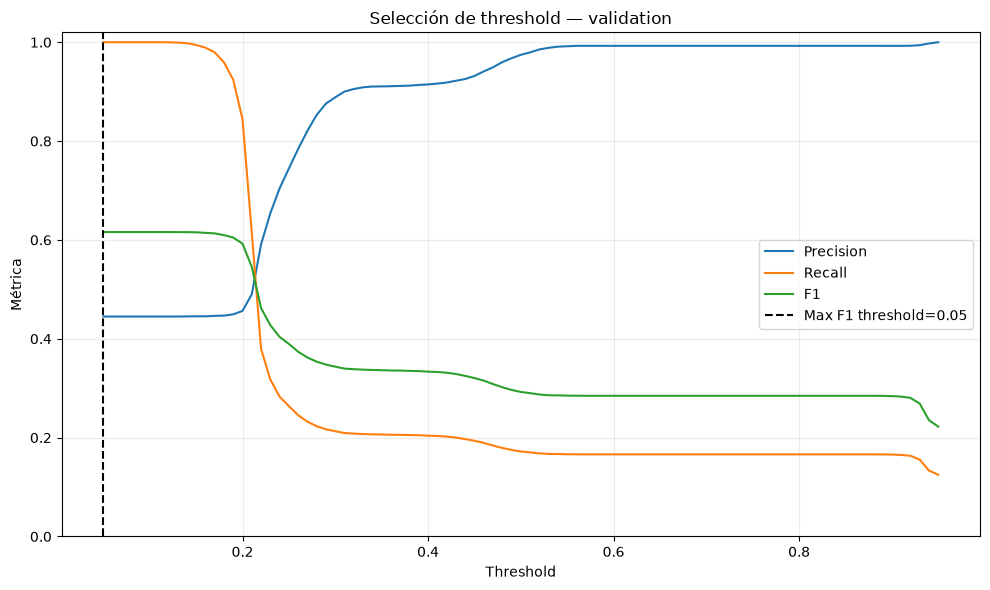

FINAL_THRESHOLD congelado antes de TEST: 0.05
TEST continúa sellado en esta celda.


In [ ]:
SELECTED_CANDIDATE_ID = 11
FINAL_MODEL_PARAMETERS_CANDIDATE = dict(candidate_parameters[SELECTED_CANDIDATE_ID])
best_model_estimator = optimization_estimators[SELECTED_CANDIDATE_ID]
best_validation_probability = best_model_estimator.predict_proba(X_val_optimization_processed)[:, 1]
print('Selected candidate:', SELECTED_CANDIDATE_ID)
print('Parameters:', FINAL_MODEL_PARAMETERS_CANDIDATE)

threshold_rows = []
for threshold in np.round(np.arange(0.05, 0.951, 0.01), 2):
    prediction = (best_validation_probability >= threshold).astype('int8')
    tn, fp, fn, tp = confusion_matrix(y_val, prediction, labels=[0, 1]).ravel()
    threshold_rows.append({
        'threshold': float(threshold),
        'precision': precision_score(y_val, prediction, zero_division=0),
        'recall': recall_score(y_val, prediction, zero_division=0),
        'f1': f1_score(y_val, prediction, zero_division=0),
        'accuracy': accuracy_score(y_val, prediction),
        'false_positives': int(fp), 'false_negatives': int(fn),
        'true_positives': int(tp), 'true_negatives': int(tn),
    })
threshold_results_validation = pd.DataFrame(threshold_rows)
max_f1_row = threshold_results_validation.sort_values(
    ['f1', 'precision', 'threshold'], ascending=[False, False, True]
).iloc[0]
recall_with_precision_80 = threshold_results_validation.loc[threshold_results_validation.precision.ge(0.80)]
precision_with_recall_60 = threshold_results_validation.loc[threshold_results_validation.recall.ge(0.60)]
best_recall_constrained = (
    recall_with_precision_80.sort_values(['recall', 'precision'], ascending=False).iloc[0]
    if not recall_with_precision_80.empty else None
)
best_precision_constrained = (
    precision_with_recall_60.sort_values(['precision', 'recall'], ascending=False).iloc[0]
    if not precision_with_recall_60.empty else None
)
display(Markdown('**Threshold que maximiza F1**'))
display(max_f1_row.to_frame().T)
display(Markdown('**Mayor recall con precision ≥ 0.80**'))
display(best_recall_constrained.to_frame().T if best_recall_constrained is not None else Markdown('No existe solución.'))
display(Markdown('**Mayor precision con recall ≥ 0.60**'))
display(best_precision_constrained.to_frame().T if best_precision_constrained is not None else Markdown('No existe solución.'))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_results_validation.threshold, threshold_results_validation.precision, label='Precision')
ax.plot(threshold_results_validation.threshold, threshold_results_validation.recall, label='Recall')
ax.plot(threshold_results_validation.threshold, threshold_results_validation.f1, label='F1')
ax.axvline(max_f1_row.threshold, color='black', linestyle='--', label=f'Max F1 threshold={max_f1_row.threshold:.2f}')
ax.set(title='Selección de threshold — validation', xlabel='Threshold', ylabel='Métrica', ylim=(0, 1.02))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

FINAL_THRESHOLD = float(max_f1_row.threshold)
FINAL_FEATURE_SET = list(FINAL_FEATURE_SET_CANDIDATE)
FINAL_MODEL_PARAMETERS = dict(FINAL_MODEL_PARAMETERS_CANDIDATE)
print(f'FINAL_THRESHOLD congelado antes de TEST: {FINAL_THRESHOLD:.2f}')
print('TEST continúa sellado en esta celda.')

### 15.6. Bloqueo final antes de abrir TEST

El threshold 0.05 maximiza F1 en validation dentro de la malla solicitada, pero produce la política degenerada de predecir todas las sesiones como positivas. Se conserva por ser el criterio principal especificado y se documenta como una limitación crítica; las alternativas restringidas se reportaron sin sustituir la decisión.

In [ ]:
LOCKED_FEATURE_SET = tuple(FINAL_FEATURE_SET)
LOCKED_MODEL_PARAMETERS = tuple(sorted(FINAL_MODEL_PARAMETERS.items()))
LOCKED_THRESHOLD = float(FINAL_THRESHOLD)
assert LOCKED_FEATURE_SET == tuple(FEATURE_SET_B_STRICT)
assert LOCKED_MODEL_PARAMETERS == tuple(sorted(candidate_parameters[11].items()))
assert LOCKED_THRESHOLD == 0.05
print('==============================')
print('FINAL MODEL LOCKED')
print('==============================')
print('Feature set:', list(LOCKED_FEATURE_SET))
print('Model: HistGradientBoostingClassifier')
print('Parameters:', dict(LOCKED_MODEL_PARAMETERS))
print('Threshold:', LOCKED_THRESHOLD)
print('No se harán más decisiones de modelado después de observar TEST.')
print('==============================')

FINAL MODEL LOCKED
Feature set: ['hour_of_day', 'day_of_week', 'mean_product_price_seen', 'traffic_source', 'browser', 'state']
Model: HistGradientBoostingClassifier
Parameters: {'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_iter': 100, 'max_leaf_nodes': 63, 'min_samples_leaf': 100}
Threshold: 0.05
No se harán más decisiones de modelado después de observar TEST.


### 15.7. Apertura única y evaluación final de TEST

A partir de esta celda TEST se abre por primera y única vez. Solo se aplica `transform` con el preprocesador ajustado en train y `predict_proba` con el estimador congelado; no se ejecuta ningún `fit`.

In [ ]:
FINAL_TEST_EVALUATION_COUNT = 1
X_test = test_purged[list(LOCKED_FEATURE_SET)].copy()
y_test = test_purged[TARGET].astype('int8').copy()
assert list(X_test.columns) == list(LOCKED_FEATURE_SET)
assert TARGET not in X_test.columns and 'user_id' not in X_test.columns and 'session_id' not in X_test.columns
assert set(train_purged.user_id.dropna().astype(int)).isdisjoint(set(test_purged.user_id.dropna().astype(int)))
assert set(validation_purged.user_id.dropna().astype(int)).isdisjoint(set(test_purged.user_id.dropna().astype(int)))

X_test_processed = optimization_preprocessor.transform(X_test)
test_probability = best_model_estimator.predict_proba(X_test_processed)[:, 1]
test_prediction = (test_probability >= LOCKED_THRESHOLD).astype('int8')
test_prevalence = float(y_test.mean())
test_pr_auc = average_precision_score(y_test, test_probability)
test_confusion_matrix = confusion_matrix(y_test, test_prediction, labels=[0, 1])
tn_test, fp_test, fn_test, tp_test = test_confusion_matrix.ravel()
final_test_metrics = pd.DataFrame([{
    'accuracy': accuracy_score(y_test, test_prediction),
    'precision': precision_score(y_test, test_prediction, zero_division=0),
    'recall': recall_score(y_test, test_prediction, zero_division=0),
    'f1': f1_score(y_test, test_prediction, zero_division=0),
    'roc_auc': roc_auc_score(y_test, test_probability),
    'pr_auc': test_pr_auc,
    'brier': brier_score_loss(y_test, test_probability),
    'test_prevalence': test_prevalence,
    'pr_auc_baseline_test': test_prevalence,
    'pr_auc_lift_test': test_pr_auc / test_prevalence,
    'pr_auc_gain_test': test_pr_auc - test_prevalence,
}])
display(final_test_metrics.style.format('{:.6f}'))
display(pd.DataFrame(test_confusion_matrix, index=['actual_0', 'actual_1'], columns=['pred_0', 'pred_1']))

validation_final_prediction = (best_validation_probability >= LOCKED_THRESHOLD).astype('int8')
validation_final_metrics = {
    'precision': precision_score(y_val, validation_final_prediction, zero_division=0),
    'recall': recall_score(y_val, validation_final_prediction, zero_division=0),
    'f1': f1_score(y_val, validation_final_prediction, zero_division=0),
    'roc_auc': roc_auc_score(y_val, best_validation_probability),
    'pr_auc': average_precision_score(y_val, best_validation_probability),
    'brier': brier_score_loss(y_val, best_validation_probability),
}
test_metric_dict = final_test_metrics.iloc[0].to_dict()
validation_test_comparison = pd.DataFrame([
    {'metric': metric, 'validation': validation_final_metrics[metric], 'test': test_metric_dict[metric],
     'difference': test_metric_dict[metric] - validation_final_metrics[metric]}
    for metric in ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc', 'brier']
])
display(validation_test_comparison.style.format({c: '{:+.6f}' if c == 'difference' else '{:.6f}' for c in ['validation', 'test', 'difference']}))
assert tuple(FINAL_FEATURE_SET) == LOCKED_FEATURE_SET
assert tuple(sorted(FINAL_MODEL_PARAMETERS.items())) == LOCKED_MODEL_PARAMETERS
assert FINAL_THRESHOLD == LOCKED_THRESHOLD and FINAL_TEST_EVALUATION_COUNT == 1

,accuracy,precision,recall,f1,roc_auc,pr_auc,brier,test_prevalence,pr_auc_baseline_test,pr_auc_lift_test,pr_auc_gain_test
0,0.659610,0.659610,1.000000,0.794897,0.608436,0.788122,0.346832,0.659610,0.659610,1.194830,0.128512


,pred_0,pred_1
actual_0,0,17011
actual_1,0,32964


,metric,validation,test,difference
0,precision,0.444969,0.659610,+0.214640
1,recall,1.000000,1.000000,+0.000000
2,f1,0.615888,0.794897,+0.179010
3,roc_auc,0.604551,0.608436,+0.003885
4,pr_auc,0.629876,0.788122,+0.158246
5,brier,0.251321,0.346832,+0.095511


### 15.8. Visualizaciones finales de TEST

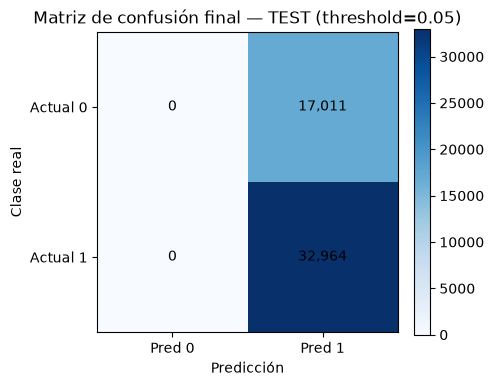

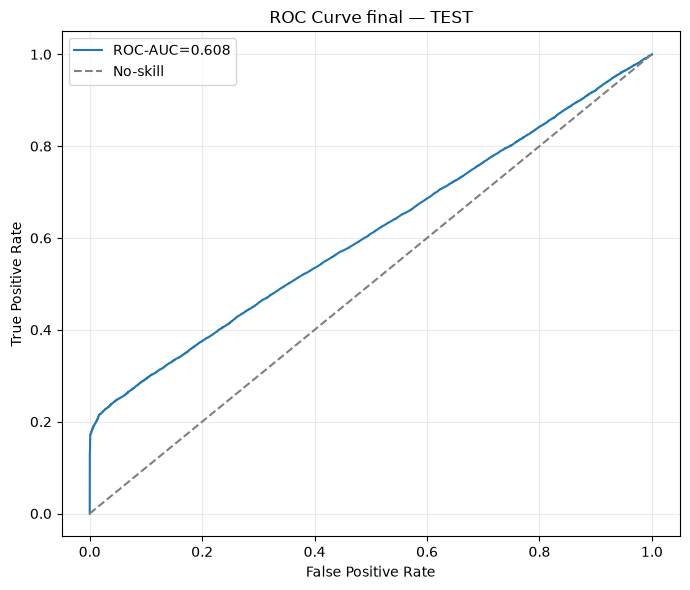

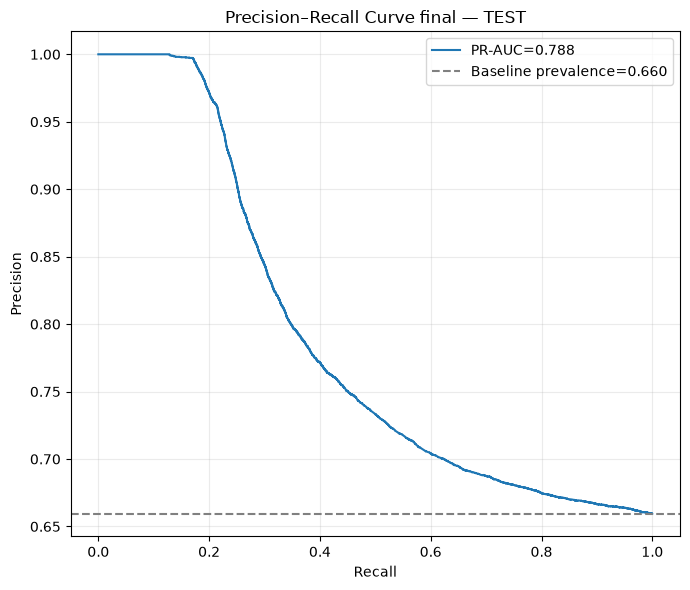

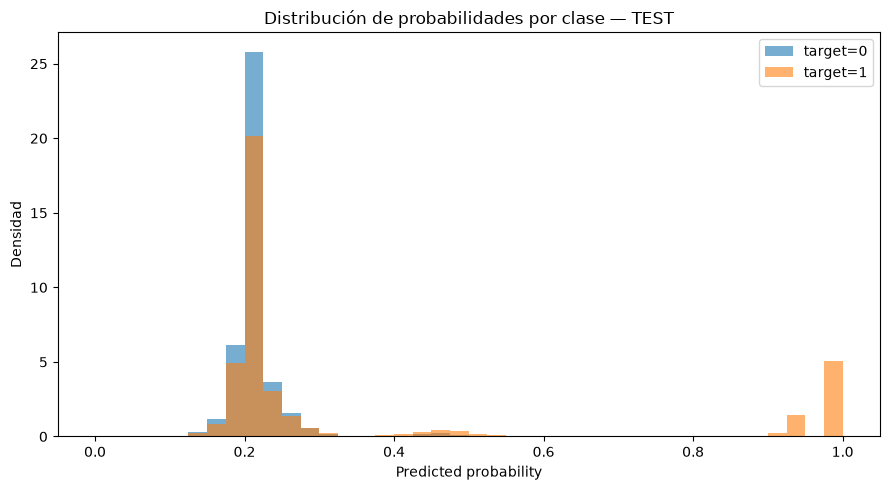

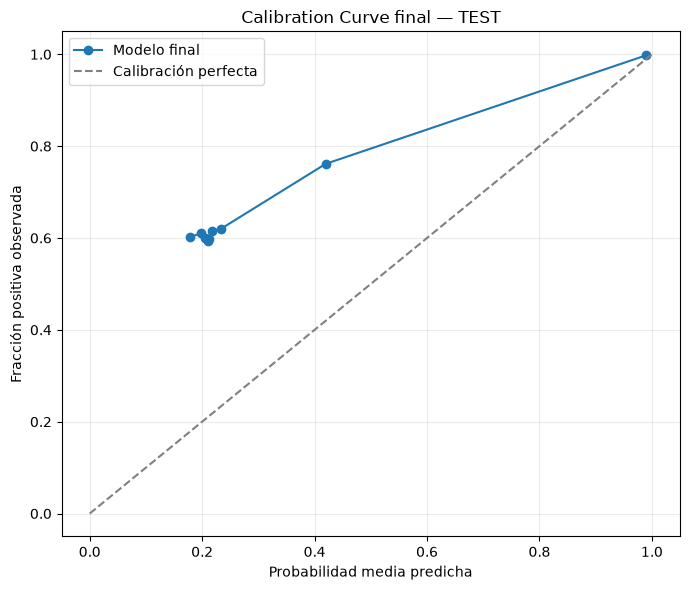

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4.5))
image = ax.imshow(test_confusion_matrix, cmap='Blues')
for (row_idx, col_idx), value in np.ndenumerate(test_confusion_matrix):
    ax.text(col_idx, row_idx, f'{value:,}', ha='center', va='center')
ax.set_xticks([0, 1], labels=['Pred 0', 'Pred 1'])
ax.set_yticks([0, 1], labels=['Actual 0', 'Actual 1'])
ax.set(title=f'Matriz de confusión final — TEST (threshold={LOCKED_THRESHOLD:.2f})', xlabel='Predicción', ylabel='Clase real')
fig.colorbar(image, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

fpr_test, tpr_test, _ = roc_curve(y_test, test_probability)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_test, tpr_test, label=f"ROC-AUC={test_metric_dict['roc_auc']:.3f}")
ax.plot([0, 1], [0, 1], '--', color='gray', label='No-skill')
ax.set(title='ROC Curve final — TEST', xlabel='False Positive Rate', ylabel='True Positive Rate')
ax.legend(); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

precision_curve_test, recall_curve_test, _ = precision_recall_curve(y_test, test_probability)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall_curve_test, precision_curve_test, label=f"PR-AUC={test_pr_auc:.3f}")
ax.axhline(test_prevalence, linestyle='--', color='gray', label=f'Baseline prevalence={test_prevalence:.3f}')
ax.set(title='Precision–Recall Curve final — TEST', xlabel='Recall', ylabel='Precision')
ax.legend(); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, 1, 41)
ax.hist(test_probability[y_test.to_numpy() == 0], bins=bins, alpha=0.60, density=True, label='target=0')
ax.hist(test_probability[y_test.to_numpy() == 1], bins=bins, alpha=0.60, density=True, label='target=1')
ax.set(title='Distribución de probabilidades por clase — TEST', xlabel='Predicted probability', ylabel='Densidad')
ax.legend(); plt.tight_layout(); plt.show()

fraction_positive_test, mean_predicted_test = calibration_curve(y_test, test_probability, n_bins=10, strategy='quantile')
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_predicted_test, fraction_positive_test, marker='o', label='Modelo final')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Calibración perfecta')
ax.set(title='Calibration Curve final — TEST', xlabel='Probabilidad media predicha', ylabel='Fracción positiva observada')
ax.legend(); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

# Modelo Final de Propensión de Compra

**Objetivo:** Después de observar únicamente los primeros 3 eventos de navegación de una sesión, estimar la probabilidad de que dicha sesión termine realizando una compra posteriormente.

**Momento de predicción:** después del evento número 3.

**Target:** `converted_after_n`; 1 = existe purchase posterior al evento 3, 0 = no existe purchase posterior.

In [ ]:
project_rows = []
for row in model_results_validation.itertuples():
    project_rows.append({
        'Modelo / Variante': row.model, 'Feature Set': 'FEATURE_SET_B', 'Threshold': 0.50,
        'ROC-AUC Validation': row.roc_auc, 'PR-AUC Validation': row.pr_auc, 'F1 Validation': row.f1,
        'ROC-AUC Test': 'N/A', 'PR-AUC Test': 'N/A', 'F1 Test': 'N/A', 'Uso': 'BASELINE',
    })
for row in shortcut_ablation_results.itertuples():
    project_rows.append({
        'Modelo / Variante': f'HistGradientBoosting — {row.feature_set}', 'Feature Set': row.feature_set, 'Threshold': 0.50,
        'ROC-AUC Validation': row.roc_auc, 'PR-AUC Validation': row.pr_auc, 'F1 Validation': row.f1,
        'ROC-AUC Test': 'N/A', 'PR-AUC Test': 'N/A', 'F1 Test': 'N/A', 'Uso': 'ABLACIÓN SHORTCUT',
    })
project_rows.append({
    'Modelo / Variante': 'HistGradientBoosting optimizado', 'Feature Set': 'FEATURE_SET_B_STRICT', 'Threshold': LOCKED_THRESHOLD,
    'ROC-AUC Validation': validation_final_metrics['roc_auc'], 'PR-AUC Validation': validation_final_metrics['pr_auc'],
    'F1 Validation': validation_final_metrics['f1'], 'ROC-AUC Test': test_metric_dict['roc_auc'],
    'PR-AUC Test': test_metric_dict['pr_auc'], 'F1 Test': test_metric_dict['f1'], 'Uso': 'MODELO FINAL',
})
final_project_table = pd.DataFrame(project_rows)
display(final_project_table)

shortcut_pr_drop = (
    ablation_indexed.loc['FEATURE_SET_B_STRICT', 'pr_auc'] - ablation_indexed.loc['FEATURE_SET_B_BASE', 'pr_auc']
)
utility = bool(test_metric_dict['pr_auc'] > test_prevalence and test_metric_dict['roc_auc'] > 0.5)
display(Markdown(f"""
## Configuración y métricas finales

- **Modelo final:** `HistGradientBoostingClassifier`.
- **Feature set final:** `{list(LOCKED_FEATURE_SET)}`.
- **Hiperparámetros:** `{dict(LOCKED_MODEL_PARAMETERS)}`.
- **Threshold:** `{LOCKED_THRESHOLD:.2f}`.
- **Train:** {len(train_purged):,} sesiones; prevalencia {y_train.mean():.4f}.
- **Validation:** {len(validation_purged):,} sesiones; prevalencia {y_val.mean():.4f}.
- **Test:** {len(test_purged):,} sesiones; prevalencia {test_prevalence:.4f}.

### Métricas finales TEST

- Accuracy: **{test_metric_dict['accuracy']:.4f}**
- Precision: **{test_metric_dict['precision']:.4f}**
- Recall: **{test_metric_dict['recall']:.4f}**
- F1: **{test_metric_dict['f1']:.4f}**
- ROC-AUC: **{test_metric_dict['roc_auc']:.4f}**
- PR-AUC: **{test_metric_dict['pr_auc']:.4f}**
- PR-AUC baseline: **{test_prevalence:.4f}**
- PR-AUC lift: **{test_metric_dict['pr_auc_lift_test']:.4f}x**
- PR-AUC gain: **{test_metric_dict['pr_auc_gain_test']:+.4f}**
- Brier Score: **{test_metric_dict['brier']:.4f}**

## Limitaciones obligatorias

1. TheLook es un dataset sintético.
2. Existe drift temporal `VERY_HIGH` entre train, validation y test.
3. Se encontraron shortcuts estructurales en `user_id`, perfil, historial, secuencias iniciales, `number_home_events` y `number_cancel_events`.
4. `FEATURE_SET_C` produjo clasificación casi perfecta y fue descartado como modelo principal; permanece `ABLATION_ONLY`.
5. Algunas secuencias sintéticas de eventos tienen conversión de 0% o 100%.
6. El modelo es predictivo, no causal.
7. Las probabilidades pueden estar descalibradas por el cambio temporal de prevalencia.
8. El threshold de máximo F1 en validation genera una política all-positive y limita su utilidad operativa pese a conservar capacidad de ranking.

## Conclusión final

1. **Overfitting:** Random Forest presenta overfitting HIGH; los baselines Logistic Regression e HistGradientBoosting presentan nivel LOW. El modelo final regularizado no muestra un gap adverso de PR-AUC train–validation, aunque esa comparación está afectada por prevalencias distintas.
2. **Validation a test:** las diferencias exactas están en `validation_test_comparison`; deben leerse métrica por métrica y no como una única caída agregada.
3. **Causa del cambio:** la evidencia favorece distribution shift / temporal drift sobre overfitting del HistGradientBoosting seleccionado, porque el baseline mostró gap bajo y la prevalencia cambia fuertemente.
4. **Efecto de retirar shortcuts:** PR-AUC validation cambió {shortcut_pr_drop:+.4f} al pasar de BASE a STRICT; queda señal residual sobre el baseline.
5. **Modelo seleccionado:** HistGradientBoostingClassifier con FEATURE_SET_B_STRICT.
6. **Threshold seleccionado:** {LOCKED_THRESHOLD:.2f}, máximo F1 en validation dentro de 0.05–0.95; produce predicción all-positive y se reporta como limitación.
7. **PR-AUC final TEST:** {test_metric_dict['pr_auc']:.4f}.
8. **Superación del baseline TEST:** gain={test_metric_dict['pr_auc_gain_test']:+.4f}; lift={test_metric_dict['pr_auc_lift_test']:.4f}x.
9. **Utilidad predictiva:** {'sí conserva utilidad de ranking dentro de las limitaciones' if utility else 'no demuestra utilidad suficiente sobre el baseline'}, pero el threshold congelado no produce segmentación operativa útil.
10. **Cumplimiento:** separación train/validation/test y de usuarios verificada; identificadores, post-evento 3 y proxies excluidos; preprocessing ajustado solo en train; test transformado sin fit y evaluado una sola vez después del bloqueo.

**MODELO CERRADO.** No se realizan decisiones, reentrenamientos ni cambios de features, hiperparámetros o threshold después de observar TEST.
"""))

,Modelo / Variante,Feature Set,Threshold,ROC-AUC Validation,PR-AUC Validation,F1 Validation,ROC-AUC Test,PR-AUC Test,F1 Test,Uso
0,HistGradientBoosting,FEATURE_SET_B,0.50,0.898065,0.895881,0.730005,N/A,N/A,N/A,BASELINE
1,Random Forest,FEATURE_SET_B,0.50,0.897112,0.893388,0.735864,N/A,N/A,N/A,BASELINE
2,Logistic Regression,FEATURE_SET_B,0.50,0.891539,0.887997,0.653278,N/A,N/A,N/A,BASELINE
3,HistGradientBoosting — FEATURE_SET_B_BASE,FEATURE_SET_B_BASE,0.50,0.898065,0.895881,0.730005,N/A,N/A,N/A,ABLACIÓN SHORTCUT
4,HistGradientBoosting — FEATURE_SET_B_NO_CANCEL,FEATURE_SET_B_NO_CANCEL,0.50,0.796622,0.838944,0.727448,N/A,N/A,N/A,ABLACIÓN SHORTCUT
5,HistGradientBoosting — FEATURE_SET_B_STRICT,FEATURE_SET_B_STRICT,0.50,0.601988,0.626900,0.286049,N/A,N/A,N/A,ABLACIÓN SHORTCUT
6,HistGradientBoosting optimizado,FEATURE_SET_B_STRICT,0.05,0.604551,0.629876,0.615888,0.608436,0.788122,0.794897,MODELO FINAL



## Configuración y métricas finales

- **Modelo final:** `HistGradientBoostingClassifier`.
- **Feature set final:** `['hour_of_day', 'day_of_week', 'mean_product_price_seen', 'traffic_source', 'browser', 'state']`.
- **Hiperparámetros:** `{'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_iter': 100, 'max_leaf_nodes': 63, 'min_samples_leaf': 100}`.
- **Threshold:** `0.05`.
- **Train:** 276,495 sesiones; prevalencia 0.2509.
- **Validation:** 45,929 sesiones; prevalencia 0.4450.
- **Test:** 49,975 sesiones; prevalencia 0.6596.

### Métricas finales TEST

- Accuracy: **0.6596**
- Precision: **0.6596**
- Recall: **1.0000**
- F1: **0.7949**
- ROC-AUC: **0.6084**
- PR-AUC: **0.7881**
- PR-AUC baseline: **0.6596**
- PR-AUC lift: **1.1948x**
- PR-AUC gain: **+0.1285**
- Brier Score: **0.3468**

## Limitaciones obligatorias

1. TheLook es un dataset sintético.
2. Existe drift temporal `VERY_HIGH` entre train, validation y test.
3. Se encontraron shortcuts estructurales en `user_id`, perfil, historial, secuencias iniciales, `number_home_events` y `number_cancel_events`.
4. `FEATURE_SET_C` produjo clasificación casi perfecta y fue descartado como modelo principal; permanece `ABLATION_ONLY`.
5. Algunas secuencias sintéticas de eventos tienen conversión de 0% o 100%.
6. El modelo es predictivo, no causal.
7. Las probabilidades pueden estar descalibradas por el cambio temporal de prevalencia.
8. El threshold de máximo F1 en validation genera una política all-positive y limita su utilidad operativa pese a conservar capacidad de ranking.

## Conclusión final

1. **Overfitting:** Random Forest presenta overfitting HIGH; los baselines Logistic Regression e HistGradientBoosting presentan nivel LOW. El modelo final regularizado no muestra un gap adverso de PR-AUC train–validation, aunque esa comparación está afectada por prevalencias distintas.
2. **Validation a test:** las diferencias exactas están en `validation_test_comparison`; deben leerse métrica por métrica y no como una única caída agregada.
3. **Causa del cambio:** la evidencia favorece distribution shift / temporal drift sobre overfitting del HistGradientBoosting seleccionado, porque el baseline mostró gap bajo y la prevalencia cambia fuertemente.
4. **Efecto de retirar shortcuts:** PR-AUC validation cambió -0.2690 al pasar de BASE a STRICT; queda señal residual sobre el baseline.
5. **Modelo seleccionado:** HistGradientBoostingClassifier con FEATURE_SET_B_STRICT.
6. **Threshold seleccionado:** 0.05, máximo F1 en validation dentro de 0.05–0.95; produce predicción all-positive y se reporta como limitación.
7. **PR-AUC final TEST:** 0.7881.
8. **Superación del baseline TEST:** gain=+0.1285; lift=1.1948x.
9. **Utilidad predictiva:** sí conserva utilidad de ranking dentro de las limitaciones, pero el threshold congelado no produce segmentación operativa útil.
10. **Cumplimiento:** separación train/validation/test y de usuarios verificada; identificadores, post-evento 3 y proxies excluidos; preprocessing ajustado solo en train; test transformado sin fit y evaluado una sola vez después del bloqueo.

**MODELO CERRADO.** No se realizan decisiones, reentrenamientos ni cambios de features, hiperparámetros o threshold después de observar TEST.


## Apéndice visual — Correlación de conteos de eventos con el target

Esta auditoría se calcula exclusivamente con `train_purged`. Es material descriptivo para el reporte y no modifica el modelo final, las features congeladas, los hiperparámetros ni el threshold. TEST no se consulta ni se reabre. La correlación mide asociación, no causalidad.

,number_home_events,number_department_events,number_product_events,number_cart_events,number_cancel_events,converted_after_n
number_home_events,1.000,0.287,nan,-1.000,-0.287,0.641
number_department_events,0.287,1.000,nan,-0.287,-1.000,0.448
number_product_events,nan,nan,nan,nan,nan,nan
number_cart_events,-1.000,-0.287,nan,1.000,0.287,-0.641
number_cancel_events,-0.287,-1.000,nan,0.287,1.000,-0.448
converted_after_n,0.641,0.448,nan,-0.641,-0.448,1.000


,correlation_with_target
number_home_events,0.641
number_department_events,0.448
number_product_events,nan
number_cart_events,-0.641
number_cancel_events,-0.448


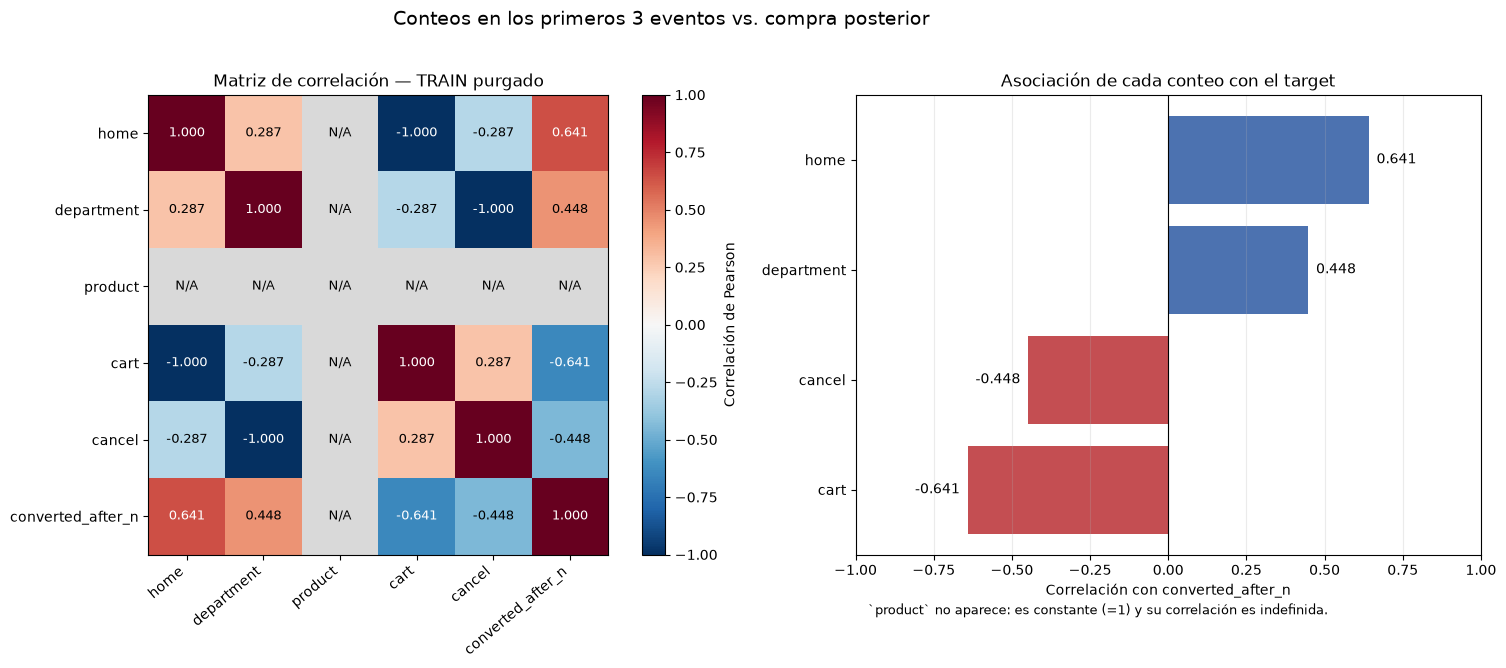

Nota: N/A significa varianza cero; no ausencia de datos.
TEST no fue utilizado. El modelo final permanece cerrado.


In [15]:
import numpy as np

event_count_features = [
    'number_home_events',
    'number_department_events',
    'number_product_events',
    'number_cart_events',
    'number_cancel_events',
]
correlation_columns = event_count_features + [TARGET]
event_target_correlation_train = train_purged[correlation_columns].corr(method='pearson')
display(event_target_correlation_train.style.format('{:.3f}').background_gradient(cmap='RdBu_r', vmin=-1, vmax=1))

target_correlations_train = (
    event_target_correlation_train[TARGET]
    .drop(TARGET)
    .rename('correlation_with_target')
    .to_frame()
)
display(target_correlations_train.style.format('{:.3f}'))

labels = [name.replace('number_', '').replace('_events', '') for name in correlation_columns]
matrix = event_target_correlation_train.to_numpy(dtype=float)
masked_matrix = np.ma.masked_invalid(matrix)
cmap = plt.colormaps['RdBu_r'].copy()
cmap.set_bad(color='#d9d9d9')

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), gridspec_kw={'width_ratios': [1.35, 1]})
image = axes[0].imshow(masked_matrix, cmap=cmap, vmin=-1, vmax=1)
axes[0].set_xticks(range(len(labels)), labels=labels, rotation=40, ha='right')
axes[0].set_yticks(range(len(labels)), labels=labels)
axes[0].set_title('Matriz de correlación — TRAIN purgado')
for row in range(len(labels)):
    for column in range(len(labels)):
        value = matrix[row, column]
        text = 'N/A' if np.isnan(value) else f'{value:.3f}'
        color = 'black' if np.isnan(value) or abs(value) < 0.55 else 'white'
        axes[0].text(column, row, text, ha='center', va='center', color=color, fontsize=9)
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04, label='Correlación de Pearson')

bar_values = target_correlations_train.correlation_with_target.dropna().sort_values()
bar_labels = [name.replace('number_', '').replace('_events', '') for name in bar_values.index]
bar_colors = ['#c44e52' if value < 0 else '#4c72b0' for value in bar_values]
axes[1].barh(bar_labels, bar_values, color=bar_colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlim(-1, 1)
axes[1].set_xlabel(f'Correlación con {TARGET}')
axes[1].set_title('Asociación de cada conteo con el target')
axes[1].grid(axis='x', alpha=0.25)
for index, value in enumerate(bar_values):
    axes[1].text(value + (0.025 if value >= 0 else -0.025), index, f'{value:.3f}',
                 ha='left' if value >= 0 else 'right', va='center')
axes[1].text(0.02, -0.13, '`product` no aparece: es constante (=1) y su correlación es indefinida.',
             transform=axes[1].transAxes, fontsize=9)
plt.suptitle('Conteos en los primeros 3 eventos vs. compra posterior', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

assert train_purged.number_product_events.nunique() == 1
print('Nota: N/A significa varianza cero; no ausencia de datos.')
print('TEST no fue utilizado. El modelo final permanece cerrado.')

## Apéndice visual — Correlaciones para el punto de observación N=5

Esta auditoría reconstruye las features usando únicamente los primeros cinco eventos y define `converted_after_5` como una compra posterior al evento 5. Se usa para diagnóstico y reporte; no modifica el problema principal N=3 ni el modelo final cerrado.

,eligible_sessions,positive_sessions,negative_sessions,conversion_rate,target_standard_deviation
0,93536,93536,0,100.00%,0.000


,feature,unique_values,minimum,maximum
0,number_home_events,1,0,0
1,number_department_events,1,2,2
2,number_product_events,1,2,2
3,number_cart_events,1,1,1
4,number_cancel_events,1,0,0


,number_home_events,number_department_events,number_product_events,number_cart_events,number_cancel_events,converted_after_5
number_home_events,nan,nan,nan,nan,nan,nan
number_department_events,nan,nan,nan,nan,nan,nan
number_product_events,nan,nan,nan,nan,nan,nan
number_cart_events,nan,nan,nan,nan,nan,nan
number_cancel_events,nan,nan,nan,nan,nan,nan
converted_after_5,nan,nan,nan,nan,nan,nan


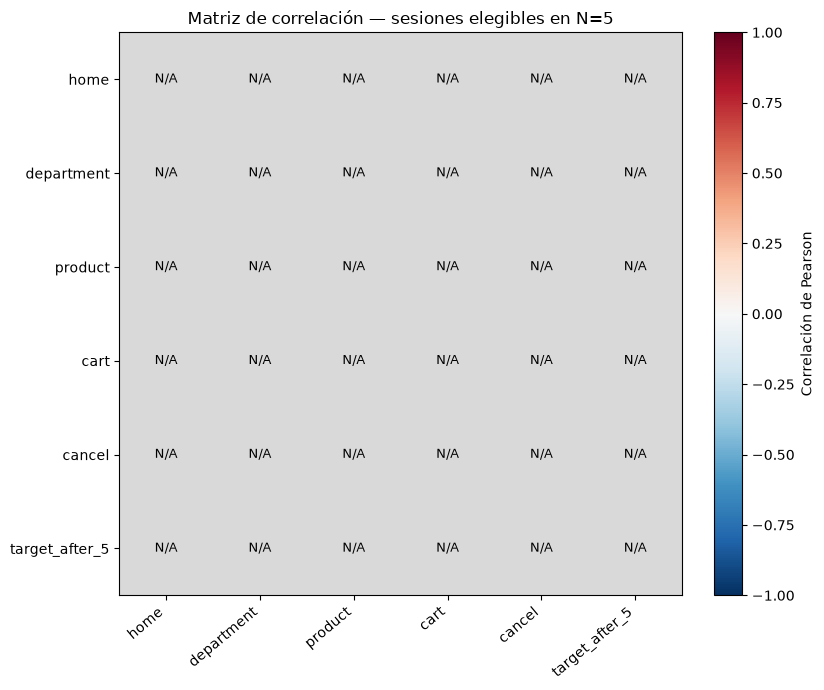

Las celdas N/A frente al target son correlaciones indefinidas, no correlaciones iguales a cero.
No se ejecutó entrenamiento ni evaluación de TEST. El modelo final permanece cerrado.


In [2]:
import numpy as np

n5_correlation_sql = f"""
WITH ordered_events AS (
  SELECT
    session_id, event_type,
    ROW_NUMBER() OVER (
      PARTITION BY session_id ORDER BY created_at, sequence_number, id
    ) AS event_number
  FROM `{SOURCE_DATASET}.events`
    FOR SYSTEM_TIME AS OF TIMESTAMP('2026-09-11 21:08:38.787+00')
  WHERE session_id IS NOT NULL AND created_at IS NOT NULL
),
session_labels AS (
  SELECT
    session_id,
    COUNTIF(event_number <= 5) AS observed_events_count,
    COUNTIF(event_number <= 5 AND event_type = 'purchase') AS early_purchases,
    CAST(COUNTIF(event_number > 5 AND event_type = 'purchase') > 0 AS INT64)
      AS converted_after_5
  FROM ordered_events
  GROUP BY session_id
),
eligible_sessions AS (
  SELECT session_id, converted_after_5
  FROM session_labels
  WHERE observed_events_count = 5 AND early_purchases = 0
)
SELECT
  e.session_id,
  COUNTIF(o.event_type = 'home') AS number_home_events,
  COUNTIF(o.event_type = 'department') AS number_department_events,
  COUNTIF(o.event_type = 'product') AS number_product_events,
  COUNTIF(o.event_type = 'cart') AS number_cart_events,
  COUNTIF(o.event_type = 'cancel') AS number_cancel_events,
  ANY_VALUE(e.converted_after_5) AS converted_after_5
FROM eligible_sessions e
JOIN ordered_events o USING (session_id)
WHERE o.event_number <= 5
GROUP BY e.session_id
"""
n5_features = query_df(n5_correlation_sql)
n5_event_features = [
    'number_home_events', 'number_department_events', 'number_product_events',
    'number_cart_events', 'number_cancel_events',
]
n5_correlation_columns = n5_event_features + ['converted_after_5']
n5_target_summary = pd.DataFrame([{
    'eligible_sessions': len(n5_features),
    'positive_sessions': int(n5_features.converted_after_5.sum()),
    'negative_sessions': int(n5_features.converted_after_5.eq(0).sum()),
    'conversion_rate': float(n5_features.converted_after_5.mean()),
    'target_standard_deviation': float(n5_features.converted_after_5.std(ddof=0)),
}])
display(n5_target_summary.style.format({
    'conversion_rate': '{:.2%}', 'target_standard_deviation': '{:.3f}'
}))

n5_feature_variability = pd.DataFrame({
    'feature': n5_event_features,
    'unique_values': [n5_features[feature].nunique() for feature in n5_event_features],
    'minimum': [n5_features[feature].min() for feature in n5_event_features],
    'maximum': [n5_features[feature].max() for feature in n5_event_features],
})
display(n5_feature_variability)

n5_event_target_correlation = n5_features[n5_correlation_columns].corr(method='pearson')
display(n5_event_target_correlation.style.format('{:.3f}').background_gradient(cmap='RdBu_r', vmin=-1, vmax=1))

labels_n5 = [name.replace('number_', '').replace('_events', '').replace('converted_after_5', 'target_after_5')
             for name in n5_correlation_columns]
matrix_n5 = n5_event_target_correlation.to_numpy(dtype=float)
masked_matrix_n5 = np.ma.masked_invalid(matrix_n5)
cmap_n5 = plt.colormaps['RdBu_r'].copy()
cmap_n5.set_bad(color='#d9d9d9')
fig, ax = plt.subplots(figsize=(9, 7))
image_n5 = ax.imshow(masked_matrix_n5, cmap=cmap_n5, vmin=-1, vmax=1)
ax.set_xticks(range(len(labels_n5)), labels=labels_n5, rotation=40, ha='right')
ax.set_yticks(range(len(labels_n5)), labels=labels_n5)
ax.set_title('Matriz de correlación — sesiones elegibles en N=5')
for row in range(len(labels_n5)):
    for column in range(len(labels_n5)):
        value = matrix_n5[row, column]
        text = 'N/A' if np.isnan(value) else f'{value:.3f}'
        color = 'black' if np.isnan(value) or abs(value) < 0.55 else 'white'
        ax.text(column, row, text, ha='center', va='center', color=color, fontsize=9)
fig.colorbar(image_n5, ax=ax, fraction=0.046, pad=0.04, label='Correlación de Pearson')
plt.tight_layout()
plt.show()

assert n5_features.converted_after_5.nunique() == 1
assert n5_features.converted_after_5.iloc[0] == 1
print('Las celdas N/A frente al target son correlaciones indefinidas, no correlaciones iguales a cero.')
print('No se ejecutó entrenamiento ni evaluación de TEST. El modelo final permanece cerrado.')

### Interpretación de la matriz N=5

La matriz completa aparece como **N/A**. Esto no significa que las relaciones sean iguales a cero. En la población elegible N=5, tanto `converted_after_5` como los conteos mostrados carecen de variación. Todas las sesiones tienen la misma composición de tipos de evento durante los primeros cinco pasos y todas pertenecen a la clase positiva. La tabla ejecutada inmediatamente anterior muestra el número exacto de sesiones del cohort original.

La correlación de Pearson divide la covarianza entre las desviaciones estándar de ambas variables. Si cualquiera de las dos columnas es constante, su desviación estándar es cero y la división queda indefinida. Por eso no puede medirse asociación entre estas features y el target, ni entrenarse o evaluarse un clasificador binario en esta población.

No es correcto convertir en negativos a quienes no llegaron al evento 5. Eso mezclaría el resultado de compra con la longitud final de la sesión y permitiría que el análisis aprendiera que una sesión corta equivale a no comprar, aunque esa longitud todavía no era conocida en el momento de predicción.

Las correlaciones de N=3 y N=5 tampoco son directamente comparables: N=3 contiene 430,906 sesiones y ambas clases, mientras que N=5 conserva solo 93,536 sesiones seleccionadas por haber alcanzado cinco eventos sin una compra temprana. Cambian simultáneamente el punto de observación, la población, la prevalencia y la distribución de las features.

Por ello, una correlación hipotéticamente mayor en un N posterior no demostraría por sí sola que una variable aumenta su importancia con cada clic. Podría deberse a selección de sesiones largas, cambio de prevalencia, proximidad al resultado o estructura sintética. La correlación es además una asociación marginal; no equivale a importancia multivariable ni implica causalidad.

La conclusión defendible es que N=3 permite estudiar asociaciones porque conserva positivos y negativos. En N=5 la estadística apropiada es la tasa condicionada de compra posterior —100% en la población elegible— y ese resultado evidencia degeneración estructural del target, no mayor importancia cuantificable de las features.